In [87]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.serif'] = ['Helvetica']
# Publication-ready defaults: larger fonts and high-resolution exports
mpl.rcParams['font.size'] = 16
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['figure.titlesize'] = 18
mpl.rcParams['figure.dpi'] = 180
mpl.rcParams['savefig.dpi'] = 600
mpl.rcParams['savefig.bbox'] = 'tight'

## Loading metadata from annotated videos


In [17]:
import numpy as np


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import json



In [18]:
import pandas as pd
keypoints_info = pd.read_json('completed_videos.json')
video_meta_data = pd.read_csv('original_videos_metadata.csv')


In [19]:

# Interactive duplicate-hand resolver
import copy
import os
import json
import cv2
import numpy as np

# Hand skeleton connections (same as used elsewhere)
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),        # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),        # Index
    (0, 9), (9, 10), (10, 11), (11, 12),   # Middle
    (0, 13), (13, 14), (14, 15), (15, 16), # Ring
    (0, 17), (17, 18), (18, 19), (19, 20)  # Pinky
]


def find_duplicate_frames(data, start=0, max_frames=None):
    duplicates = []
    end = len(data) if max_frames is None else min(len(data), start + max_frames)
    for idx in range(start, end):
        frame = data[idx]
        hands = frame.get('hands', [])
        # only consider duplicates where the hand_id is exactly "Right"
        hand_ids = [h.get('hand_id') for h in hands if h.get('hand_id') is not None]
        if hand_ids.count('Right') > 1:
            indices = [i for i, h in enumerate(hands) if h.get('hand_id') == 'Right']
            duplicates.append((idx, 'Right', indices))
    return duplicates


def draw_hand(img, hand, color=(0,0,255), label=None, thickness=2):
    h, w = img.shape[:2]
    # draw landmarks
    lms = hand.get('landmarks', [])
    pts = []
    for i, lm in enumerate(lms):
        x = int(lm['x'] * w)
        y = int(lm['y'] * h)
        pts.append((x,y))
        cv2.circle(img, (x,y), 3, color, -1)
        if i == 0 and label is not None:
            # label near wrist
            cv2.putText(img, label, (x+6, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    # draw bones
    for a,b in HAND_CONNECTIONS:
        if a < len(pts) and b < len(pts):
            cv2.line(img, pts[a], pts[b], color, thickness)


def interactive_resolve_duplicates(keypoints_info_df, save_suffix='_dublicates_removed', show_video=True, max_videos=None):
    """
    Interactive reviewer to resolve duplicate hand_id occurrences in keypoints JSON files.
    - Press 'r' to keep the first (red) hand, 'b' to keep the second (blue)
    - For >2 duplicates you can press '1','2','3',... to keep that indexed instance
    - Press 's' to skip (leave frame untouched), 'q' to quit and save current edits

    This will write a new JSON next to the original with appendix `save_suffix`.
    """
    summary = []
    processed_videos = 0

    for i in range(len(keypoints_info_df)):
        if max_videos is not None and processed_videos >= max_videos:
            break

        row = keypoints_info_df.iloc[i]
        keypoints_file = row['keypoints_file']
        video_path = row.get('video_path', None)
        video_name = row['video_name'].split('.')[0]

        if not os.path.exists(keypoints_file):
            print(f"⚠️ Keypoints JSON not found: {keypoints_file} - skipping")
            continue

        with open(keypoints_file, 'r') as f:
            data = json.load(f)

        # Determine annotated range if present
        start_frame = int(row.get('annotation_start_frame', 0))
        last_frame = int(row.get('last_annotated_frame', len(data)-1))

        # Find duplicate frames within annotated range
        duplicates = find_duplicate_frames(data[start_frame:last_frame+1], start=0)
        if not duplicates:
            continue

        print(f"\nProcessing {video_name}: {len(duplicates)} duplicate group(s) found")

        # Open video if possible
        cap = None
        if show_video and video_path and os.path.exists(video_path):
            cap = cv2.VideoCapture(video_path)

        edits = 0
        for (rel_idx, dup_id, indices) in duplicates:
            frame_idx = start_frame + rel_idx
            print(f"\nVideo {video_name} - Frame {frame_idx} - duplicate hand_id={dup_id} indices={indices}")

            # read video frame if possible
            if cap is not None:
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                ret, frame = cap.read()
                if not ret:
                    print(f"⚠️ Unable to read frame {frame_idx} from video; using blank canvas")
                    frame = np.full((720, 1280, 3), 255, dtype=np.uint8)
            else:
                # fallback: estimate resolution from last known resolution or use default
                resolution = row.get('resolution', None)
                if resolution and isinstance(resolution, str) and 'x' in resolution:
                    h, w = map(int, resolution.split('x'))
                else:
                    h, w = 720, 1280
                frame = np.full((h, w, 3), 255, dtype=np.uint8)

            # Create a copy to draw on
            display = frame.copy()

            # Draw all hands faintly in gray
            for hi, hand in enumerate(data[frame_idx].get('hands', [])):
                draw_hand(display, hand, color=(180,180,180), label=f"{hi}")

            # Highlight duplicate group: color them red, blue, green...
            colors = [(0,0,255), (255,0,0), (0,255,0), (0,255,255), (255,0,255)]
            for idx_k, hand_idx in enumerate(indices):
                color = colors[idx_k % len(colors)]
                label = f"#{idx_k+1} id={dup_id} (orig_idx={hand_idx})"
                try:
                    hand = data[frame_idx]['hands'][hand_idx]
                except Exception:
                    print("Index error when accessing hand; skipping this duplicate group")
                    hand = None
                if hand:
                    draw_hand(display, hand, color=color, label=label)

            # Overlay instructions
            h, w = display.shape[:2]
            instructions = ["Choose which hand to KEEP for this duplicate group:",
                            "Press 'r' or '1' -> keep RED / first shown",
                            "Press 'b' or '2' -> keep BLUE / second shown",
                            "Or press numeric key 1/2/3... to keep that instance",
                            "Press 's' to skip, 'q' to quit and save progress"]
            y0 = 20
            for j, line in enumerate(instructions):
                cv2.putText(display, line, (10, y0 + j*20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

            # Show and wait for key
            window_title = f"{video_name} - frame {frame_idx} - duplicate id {dup_id}"
            cv2.imshow(window_title, display)

            while True:
                key = cv2.waitKey(0) & 0xFF
                if key == ord('q'):
                    print("User requested quit. Saving progress...")
                    cv2.destroyWindow(window_title)
                    if cap is not None:
                        cap.release()
                    # write changes and return
                    out_path = os.path.splitext(keypoints_file)[0] + save_suffix + '.json'
                    with open(out_path, 'w') as of:
                        json.dump(data, of)
                    print(f"Saved interim results to {out_path}")
                    return

                if key == ord('s'):
                    print("Skipped this frame (no change)")
                    break

                # Map r/b to 1/2 when only two options
                if len(indices) == 2 and key in (ord('r'), ord('b')):
                    selected_local = 0 if key == ord('r') else 1
                elif key in (ord('1'), ord('2'), ord('3'), ord('4'), ord('5')):
                    selected_local = int(chr(key)) - 1
                else:
                    print("Unrecognized key. Use r/b or 1/2 or s/q.")
                    continue

                if selected_local < 0 or selected_local >= len(indices):
                    print(f"Selected index {selected_local+1} out of range for this group (len={len(indices)})")
                    continue

                # Apply selection: keep only that hand instance for all hands with same hand_id
                chosen_hand_idx = indices[selected_local]
                chosen_hand = data[frame_idx]['hands'][chosen_hand_idx]
                before_count = len(data[frame_idx].get('hands', []))
                # Remove other hands with same id
                new_hands = []
                for h in data[frame_idx].get('hands', []):
                    if h.get('hand_id') == dup_id:
                        # keep only if it is the chosen one (compares landmark positions for equality)
                        if h is chosen_hand:
                            new_hands.append(h)
                        else:
                            # drop
                            pass
                    else:
                        new_hands.append(h)
                data[frame_idx]['hands'] = new_hands
                after_count = len(data[frame_idx]['hands'])
                edits += 1
                print(f"Kept instance {selected_local+1} (orig idx {chosen_hand_idx}). Hands in frame: {before_count} -> {after_count}")
                break

            cv2.destroyWindow(window_title)

        # end duplicates loop for this video
        # save modified json if any edits
        if edits > 0:
            out_path = os.path.splitext(keypoints_file)[0] + save_suffix + '.json'
            with open(out_path, 'w') as of:
                json.dump(data, of)
            print(f"Saved edited file to: {out_path} (edits: {edits})")
            summary.append((video_name, keypoints_file, edits, out_path))

        if cap is not None:
            cap.release()

        processed_videos += 1

    # end for videos
    print("\n=== DONE ===")
    for s in summary:
        print(f"{s[0]}: {s[2]} edits -> {s[3]}")


# Example usage (run this cell to start interactive review):
interactive_resolve_duplicates(keypoints_info, save_suffix='_dublicates_removed', show_video=True)



=== DONE ===


## Transforms and prepare timeseries 

### Pixel to world

In [20]:
import numpy as np
import cv2
from scipy.signal import savgol_filter, medfilt

class BoxBlockGeometry:
    def __init__(self, focal_length_35mm, image_res=(1080, 1920)):
        # 1. Image Resolution handling
        raw_w, raw_h = image_res
        self.w = min(raw_w, raw_h)
        self.h = max(raw_w, raw_h)
        
        # 2. Camera Intrinsic Setup
        # Calculate focal length in pixels based on 35mm equivalent
        self.fx = (focal_length_35mm * self.h) / 36.0
        self.fy = self.fx
        self.cx = self.w / 2.0
        self.cy = self.h / 2.0
        
        self.camera_matrix = np.array([[self.fx, 0, self.cx], 
                                       [0, self.fy, self.cy], 
                                       [0, 0, 1]], dtype=np.float32)
        self.dist_coeffs = np.zeros(4)
        
        # 3. State Variables
        self.rvec = None
        self.tvec = None
        self.camera_pos_world = None 
        self.model_points = None
        
        # 4. Geometry Constants (mm)
        self.BOX_H_TOP = 85.0   # Top of boxes / Bottom of Wall
        self.WALL_H_TOP = 189.0 # Top of Wall
        self.BOX_INNER_W = 257.0  # Box width
        self.BOX_INNER_D = 257.0  # Box depth
        self.GAP = 42.5           # Gap between boxes
        self.WALL_X_CENTER = 272.0  # Wall X position
        
        # Track which components were used for calibration
        self.calibrated_with_picking = False
        self.calibrated_with_placing = False
        
        # Wall crossing correction tracking
        self.wall_crossing_reports = {}
        
        self.define_full_scene()

    def define_full_scene(self):
        """ Defines the 3D Coordinates of the Box and Block test setup. """
        PLACE_X_START = self.BOX_INNER_W + self.GAP
        points_list = []

        # --- 1. PICKING BOX (Indices 0-3) ---
        points_list.extend([
            [0, 0, self.BOX_H_TOP], 
            [0, self.BOX_INNER_D, self.BOX_H_TOP],
            [self.BOX_INNER_W, self.BOX_INNER_D, self.BOX_H_TOP], 
            [self.BOX_INNER_W, 0, self.BOX_H_TOP]
        ])
        
        # --- 2. SEPARATION WALL (Indices 4-7) ---
        # Top-Front, Top-Back, Bottom-Back, Bottom-Front
        points_list.extend([
            [self.WALL_X_CENTER, 0, self.WALL_H_TOP],             
            [self.WALL_X_CENTER, self.BOX_INNER_D, self.WALL_H_TOP],   
            [self.WALL_X_CENTER, self.BOX_INNER_D, self.BOX_H_TOP],    
            [self.WALL_X_CENTER, 0, self.BOX_H_TOP]               
        ])
        
        # --- 3. PLACING BOX (Indices 8-11) ---
        points_list.extend([
            [PLACE_X_START, 0, self.BOX_H_TOP], 
            [PLACE_X_START, self.BOX_INNER_D, self.BOX_H_TOP],
            [PLACE_X_START + self.BOX_INNER_W, self.BOX_INNER_D, self.BOX_H_TOP], 
            [PLACE_X_START + self.BOX_INNER_W, 0, self.BOX_H_TOP]
        ])

        self.model_points = np.array(points_list, dtype=np.float32)

    def calibrate(self, frame_data):
        """ Solves PnP to find Camera Position relative to the Box Setup. """
        if frame_data is None or not isinstance(frame_data, dict):
            return False

        def has_valid_landmarks(key, min_count=4):
            if key not in frame_data: return False
            lms = frame_data[key].get('landmarks', [])
            if len(lms) < min_count: return False
            return not all(lm.get('x', 0) == 0 and lm.get('y', 0) == 0 for lm in lms[:min_count])

        has_wall = has_valid_landmarks('separation_wall', 4)
        has_picking = has_valid_landmarks('picking_box_corners', 4)
        has_placing = has_valid_landmarks('placing_box_corners', 4)

        if not has_wall or (not has_picking and not has_placing):
            print("Calibration failed: Need Wall + at least one Box.")
            return False

        img_points_list = []
        model_indices = []

        if has_picking:
            for i, p in enumerate(frame_data['picking_box_corners']['landmarks'][:4]):
                img_points_list.append([p['x']*self.w, p['y']*self.h])
                model_indices.append(i)
        
        for i, p in enumerate(frame_data['separation_wall']['landmarks'][:4]):
            img_points_list.append([p['x']*self.w, p['y']*self.h])
            model_indices.append(4 + i)
        
        if has_placing:
            for i, p in enumerate(frame_data['placing_box_corners']['landmarks'][:4]):
                img_points_list.append([p['x']*self.w, p['y']*self.h])
                model_indices.append(8 + i)

        img_points = np.array(img_points_list, dtype=np.float32)
        model_subset = self.model_points[model_indices]

        self.calibrated_with_picking = has_picking
        self.calibrated_with_placing = has_placing
        
        if len(img_points) < 4: return False

        try: flags = cv2.SOLVEPNP_SQPNP
        except AttributeError: flags = cv2.SOLVEPNP_EPNP

        success, self.rvec, self.tvec = cv2.solvePnP(
            model_subset, img_points, self.camera_matrix, self.dist_coeffs, flags=flags
        )
        
        if success:
            R, _ = cv2.Rodrigues(self.rvec)
            self.camera_pos_world = (-np.dot(R.T, self.tvec)).flatten()
            return True
        return False

    def transform_camera_to_world(self, points_cam_3d):
        """ Transforms points from Camera Frame to World Frame. """
        R, _ = cv2.Rodrigues(self.rvec)
        points_world = []
        for p in points_cam_3d:
            p_centered = p - self.tvec.flatten()
            points_world.append(np.dot(R.T, p_centered))
        return np.array(points_world)

    def estimate_other_box(self, known_box_corners, from_picking=True):
        if known_box_corners is None or len(known_box_corners) < 4: return None
        return self.model_points[8:12].copy() if from_picking else self.model_points[0:4].copy()

    def get_projected_position(self, landmark, fixed_val, plane_axis='y'):
        """ Ray-Plane Intersection. """
        if self.camera_pos_world is None: return None
        uv = np.array([landmark['x'] * self.w, landmark['y'] * self.h], dtype=np.float32)
        uv_norm = cv2.undistortPoints(np.expand_dims(uv, 0), self.camera_matrix, self.dist_coeffs).squeeze()
        
        R, _ = cv2.Rodrigues(self.rvec)
        ray_dir = np.dot(R.T, np.append(uv_norm, 1.0))
        C = self.camera_pos_world.flatten()
        
        idx = 0 if plane_axis == 'x' else 1 if plane_axis == 'y' else 2
        if abs(ray_dir[idx]) < 1e-6: return None
            
        t = (fixed_val - C[idx]) / ray_dir[idx]
        return C + t * ray_dir

    def solve_robust_depth_raw(self, landmarks, custom_width):
        """ Calculates RAW (Noisy) Depth scalar Z. """
        lm0, lm5, lm17 = landmarks[0], landmarks[5], landmarks[17]
        p5 = np.array([lm5['x']*self.w, lm5['y']*self.h])
        p17 = np.array([lm17['x']*self.w, lm17['y']*self.h])
        
        d_width = np.linalg.norm(p5 - p17)
        if d_width < 1.0: return None

        z = (self.fx * custom_width) / d_width
        
        # Physical constraints: Hand won't be closer than 20cm or further than 1.5m
        if self.camera_pos_world is not None:
             z = np.clip(z, 200, 1500)
        return z

    def reproject_hand_with_smooth_depth(self, landmarks, smooth_z, bounds_y):
        """ Reprojects 2D landmarks + Smooth Z into 3D World Coordinates. """
        cam_points = []
        for lm in landmarks:
            u, v = lm['x']*self.w, lm['y']*self.h
            x_c = (u - self.cx) * smooth_z / self.fx
            y_c = (v - self.cy) * smooth_z / self.fy
            cam_points.append([x_c, y_c, smooth_z])
            
        world_points = self.transform_camera_to_world(np.array(cam_points))
        
        # Apply Y (Depth) Constraint only
        centroid_y = np.mean(world_points[:, 1])
        min_y, max_y = bounds_y
        offset_y = 0
        if centroid_y < min_y: offset_y = min_y - centroid_y
        elif centroid_y > max_y: offset_y = max_y - centroid_y
        world_points[:, 1] += offset_y
        
        return world_points

    def auto_scale_hand_size(self, landmarks_list_of_lists):
        """ Calibrates hand size based on floor hits. """
        DEFAULT_WIDTH = 85.0
        z_floor_contacts = []
        
        for lms in landmarks_list_of_lists:
            if not lms: continue
            p5 = np.array([lms[5]['x']*self.w, lms[5]['y']*self.h])
            p17 = np.array([lms[17]['x']*self.w, lms[17]['y']*self.h])
            if np.linalg.norm(p5 - p17) < 1.0: continue
            
            z_cam = (self.fx * DEFAULT_WIDTH) / np.linalg.norm(p5 - p17)
            u, v = (lms[5]['x'] + lms[17]['x'])/2 * self.w, (lms[5]['y'] + lms[17]['y'])/2 * self.h
            
            uv_norm = cv2.undistortPoints(np.expand_dims(np.array([u,v]), 0), 
                                         self.camera_matrix, self.dist_coeffs).squeeze()
            
            R, _ = cv2.Rodrigues(self.rvec)
            world_p = np.dot(R.T, (np.array([uv_norm[0], uv_norm[1], 1.0]) * z_cam) - self.tvec.flatten())
            z_floor_contacts.append(world_p[2])

        if not z_floor_contacts: return DEFAULT_WIDTH

        observed_floor_z = np.percentile(z_floor_contacts, 5)
        scale_factor = (self.camera_pos_world[2] - 10.0) / (self.camera_pos_world[2] - observed_floor_z)
        return np.clip(DEFAULT_WIDTH * scale_factor, 60.0, 110.0)

    def validate_wall_crossing_trajectory(self, hand_trajectory, wall_touch_detected=False, 
                                          min_x_beyond_wall=50.0, z_clearance=5.0):
        """
        Validates and corrects hand trajectory for physically plausible wall crossing.
        
        Applies GLOBAL corrections to the ENTIRE trajectory based on wall constraints:
        
        1. If wall touch was detected: calibration already done via X-offset (no additional correction)
        2. If NO wall touch detected:
           - Hand centroid must reach at least min_x_beyond_wall (50mm) past wall X
           - When crossing the wall zone, hand Z must be above wall height + z_clearance
           - If these conditions aren't met, apply global corrections to entire trajectory
        
        Parameters:
        -----------
        hand_trajectory : np.ndarray
            Shape (N_frames, 21, 3) - Full hand trajectory with 21 landmarks
            X, Y, Z coordinates in mm
        wall_touch_detected : bool
            Whether a wall touch was detected (skip correction if True)
        min_x_beyond_wall : float
            Minimum distance (mm) the hand centroid must go beyond wall X (default 50mm)
        z_clearance : float
            Minimum height (mm) above wall when passing without touch (default 5mm)
            
        Returns:
        --------
        corrected_trajectory : np.ndarray
            Corrected trajectory with same shape as input
        validation_report : dict
            Contains validation status and corrections applied
        """
        wall_x = self.WALL_X_CENTER
        wall_height = self.WALL_H_TOP
        
        # Calculate hand centroids for each frame (mean of all 21 landmarks)
        # Use centroid for X detection, middle finger MCP (9) for Z validation
        centroids = np.nanmean(hand_trajectory, axis=1)  # Shape: (N_frames, 3)
        reference_z_points = hand_trajectory[:, 9, :].copy()  # Middle finger MCP
        
        corrected = hand_trajectory.copy()
        
        report = {
            'wall_x': wall_x,
            'wall_height': wall_height,
            'wall_touch_detected': wall_touch_detected,
            'min_x_beyond_wall': min_x_beyond_wall,
            'z_clearance': z_clearance,
            'original_max_x': np.nanmax(centroids[:, 0]),
            'original_min_x': np.nanmin(centroids[:, 0]),
            'crosses_wall': False,
            'x_correction_applied': 0.0,
            'z_correction_applied': 0.0,
            'crossing_frames': [],
            'correction_reason': None
        }
        
        # If wall touch was detected, calibration was already done - skip further correction
        if wall_touch_detected:
            report['correction_reason'] = "Wall touch detected - X calibration already applied"
            report['crosses_wall'] = report['original_max_x'] >= wall_x
            return corrected, report
        
        # --- STEP 1: Check and correct X penetration ---
        # Hand must go at least min_x_beyond_wall past wall_x
        target_max_x = wall_x + min_x_beyond_wall
        current_max_x = np.nanmax(centroids[:, 0])
        
        if np.isnan(current_max_x):
            report['warning'] = "All trajectory X values are NaN"
            return corrected, report
        
        # Calculate global X correction needed
        x_correction = 0.0
        if current_max_x < target_max_x:
            # Trajectory doesn't reach far enough - apply global X shift
            x_correction = target_max_x - current_max_x
            report['x_correction_applied'] = x_correction
            report['correction_reason'] = f"Max X ({current_max_x:.1f}mm) < target ({target_max_x:.1f}mm)"
            
            # Apply X correction to ENTIRE trajectory
            valid_frames = ~np.isnan(corrected[:, 0, 0])
            corrected[valid_frames, :, 0] += x_correction
            
            # Update centroids after X correction
            centroids = np.nanmean(corrected, axis=1)
        
        report['corrected_max_x'] = np.nanmax(centroids[:, 0])
        report['crosses_wall'] = report['corrected_max_x'] >= wall_x
        
        # --- STEP 2: Check and correct Z height at wall crossing ---
        # Find frames where hand is in the wall crossing zone
        wall_tolerance = 20.0  # mm tolerance for "at wall" detection
        min_z_at_crossing = wall_height + z_clearance  # Must be above wall when crossing
        
        crossing_z_values = []
        for frame_idx in range(len(centroids)):
            x = centroids[frame_idx, 0]
            z = reference_z_points[frame_idx, 2]
            
            if np.isnan(x) or np.isnan(z):
                continue
            
            # Check if hand centroid is in the wall crossing zone
            if abs(x - wall_x) <= wall_tolerance:
                report['crossing_frames'].append(frame_idx)
                crossing_z_values.append(z)
        
        # If we have crossing frames, check the minimum Z during crossing
        z_correction = 0.0
        if crossing_z_values:
            min_crossing_z = np.min(crossing_z_values)
            report['min_z_at_crossing'] = min_crossing_z
            
            if min_crossing_z < min_z_at_crossing:
                # Z is too low at crossing - apply global Z lift to entire trajectory
                z_correction = min_z_at_crossing - min_crossing_z
                report['z_correction_applied'] = z_correction
                
                if report['correction_reason']:
                    report['correction_reason'] += f"; Z at crossing ({min_crossing_z:.1f}mm) < required ({min_z_at_crossing:.1f}mm)"
                else:
                    report['correction_reason'] = f"Z at crossing ({min_crossing_z:.1f}mm) < required ({min_z_at_crossing:.1f}mm)"
                
                # Apply Z correction to ENTIRE trajectory
                valid_frames = ~np.isnan(corrected[:, 0, 0])
                corrected[valid_frames, :, 2] += z_correction
        
        report['corrected_min_z_at_crossing'] = report.get('min_z_at_crossing', np.nan) + z_correction
        report['n_crossing_frames'] = len(report['crossing_frames'])
        
        if report['correction_reason'] is None:
            report['correction_reason'] = "No correction needed - trajectory meets all constraints"
        
        return corrected, report

    def apply_wall_crossing_correction(self, hand_trajectory, wall_touch_detected=False, verbose=True):
        """
        Apply wall crossing validation to a single hand trajectory.
        Convenience method that wraps validate_wall_crossing_trajectory.
        
        Parameters:
        -----------
        hand_trajectory : np.ndarray
            Shape (N_frames, 21, 3) - Full hand trajectory
        wall_touch_detected : bool
            Whether a wall touch was detected during processing
        verbose : bool
            Print validation report
            
        Returns:
        --------
        corrected_trajectory : np.ndarray
            Corrected trajectory
        report : dict
            Validation report
        """
        corrected_hand, report = self.validate_wall_crossing_trajectory(
            hand_trajectory, 
            wall_touch_detected=wall_touch_detected
        )
        
        if verbose:
            print(f"  Wall touch detected: {report['wall_touch_detected']}")
            print(f"  Original X range: [{report['original_min_x']:.1f}, {report['original_max_x']:.1f}] mm")
            print(f"  Target: wall_x + 50mm = {report['wall_x'] + report['min_x_beyond_wall']:.1f} mm")
            print(f"  Crosses wall: {report['crosses_wall']}")
            print(f"  Crossing frames detected: {report['n_crossing_frames']}")
            print(f"  X correction applied: {report['x_correction_applied']:.1f} mm")
            print(f"  Z correction applied: {report['z_correction_applied']:.1f} mm")
            print(f"  Reason: {report['correction_reason']}")
            if 'warning' in report:
                print(f"  WARNING: {report['warning']}")
        
        return corrected_hand, report

    def process_full_data(self, data, apply_wall_correction=True, verbose=False):
        """
        Main pipeline: 
        1. Extract Landmarks 
        2. Filter Depth 
        3. Detect Wall Touches 
        4. Apply X-Offset Correction (from wall touch OR heuristic)
        5. Apply Wall Crossing Correction (if no wall touch detected)
        6. Return CORRECTED Trajectories
        
        Parameters:
        -----------
        data : list
            Frame-by-frame data with landmarks
        apply_wall_correction : bool
            Whether to apply wall crossing correction (default True)
        verbose : bool
            Print detailed progress information
        
        Returns:
        --------
        tuple of np.ndarray
            (hand_trajectory, picking_box, placing_box, wall) - all corrected
        """
        
        # --- 1. PREPARATION ---
        all_lms = []
        for item in data:
            lm = None
            if item.get('hands'):
                rh = next((h for h in item['hands'] if h.get('handedness') == 'Right'), None)
                if rh: lm = rh['landmarks']
            all_lms.append(lm)
            
        user_hand_width = self.auto_scale_hand_size(all_lms)
        
        # --- 2. DEPTH FILTERING ---
        raw_depths = []
        for i, lm in enumerate(all_lms):
            if lm:
                z = self.solve_robust_depth_raw(lm, user_hand_width)
                raw_depths.append(z if z is not None else np.nan)
            else:
                raw_depths.append(np.nan)
                
        raw_depths = np.array(raw_depths)
        
        # Fill NaNs and Smooth
        nans = np.isnan(raw_depths)
        if np.sum(~nans) > 2: 
            x_indices = lambda z: z.nonzero()[0]
            raw_depths[nans] = np.interp(x_indices(nans), x_indices(~nans), raw_depths[~nans])
        
        filtered_depths = medfilt(raw_depths, kernel_size=5) 
        if len(filtered_depths) > 10:
            filtered_depths = savgol_filter(filtered_depths, 10, polyorder=2)
            
        # --- 3. RAW TRAJECTORY & WALL TRACKING ---
        Y_BOUNDS = (0, self.BOX_INNER_D + 150.0)
        
        raw_hand_positions = []
        raw_wall_positions = []
        wall_top_history = [] 
        
        def get_wall_top_2d(item):
            """ Get 2D pixel positions of top wall corners. """
            if item.get('separation_wall') and 'landmarks' in item['separation_wall']:
                lms = item['separation_wall']['landmarks']
                if len(lms) >= 2:
                    return np.array([
                        [lms[0]['x'] * self.w, lms[0]['y'] * self.h],
                        [lms[1]['x'] * self.w, lms[1]['y'] * self.h]
                    ])
            return None

        def get_wall_3d(item):
            if item.get('separation_wall') and 'landmarks' in item['separation_wall']:
                lms = item['separation_wall']['landmarks']
                pts = []
                z_vals = [self.WALL_H_TOP, self.WALL_H_TOP, self.BOX_H_TOP, self.BOX_H_TOP]
                for i, lm in enumerate(lms[:4]):
                    res = self.get_projected_position(lm, z_vals[i], 'z')
                    pts.append(res if res is not None else [0,0,0])
                return np.array(pts)
            return None

        for i, item in enumerate(data):
            curr_hand = np.full((21, 3), np.nan)
            if all_lms[i] is not None and not np.isnan(filtered_depths[i]):
                smooth_z = filtered_depths[i]
                curr_hand = self.reproject_hand_with_smooth_depth(all_lms[i], smooth_z, Y_BOUNDS)
            raw_hand_positions.append(curr_hand)
            
            wall_top_history.append(get_wall_top_2d(item))
            raw_wall_positions.append(get_wall_3d(item))

        # --- 4. WALL TOUCH DETECTION ---
        wall_touch_frames = []
        STABILITY_FRAMES = 3
        MOVE_THRESHOLD = 3.0
        
        for i in range(STABILITY_FRAMES, len(wall_top_history)):
            curr = wall_top_history[i]
            if curr is None: continue
            
            stable = True
            for j in range(1, STABILITY_FRAMES):
                prev = wall_top_history[i - j]
                if prev is None:
                    stable = False; break
                if np.linalg.norm(wall_top_history[i-j] - wall_top_history[i-j-1]) > MOVE_THRESHOLD:
                    stable = False; break
            
            if stable:
                prev = wall_top_history[i - 1]
                if prev is not None and np.linalg.norm(curr - prev) > MOVE_THRESHOLD:
                    wall_touch_frames.append(i)
        
        wall_touch_detected = len(wall_touch_frames) > 0
        
        # --- 5. CALCULATE X-CORRECTION (CALIBRATION from wall touch) ---
        global_x_offset = 0.0
        calibration_method = "none"
        
        reference_wall_x = self.WALL_X_CENTER
        for wp in raw_wall_positions:
            if wp is not None:
                reference_wall_x = np.mean(wp[:2, 0])
                break

        # A. Priority Method: Wall Touch Calibration
        if wall_touch_detected:
            touch_frame = wall_touch_frames[0] - 1
            if 0 <= touch_frame < len(raw_hand_positions):
                touch_hand = raw_hand_positions[touch_frame]
                touch_wall = raw_wall_positions[touch_frame]
                
                if not np.isnan(touch_hand[0, 0]) and touch_wall is not None:
                    actual_wall_x = np.mean(touch_wall[:2, 0])
                    raw_hand_x = np.mean(touch_hand[:, 0])
                    
                    global_x_offset = actual_wall_x - raw_hand_x
                    calibration_method = "wall_touch"
                    if verbose:
                        print(f"CALIBRATION: Wall touch at frame {touch_frame}. Applied X-Offset: {global_x_offset:.1f}mm")

        # B. Fallback: Start Position Heuristic (only if no wall touch)
        if calibration_method == "none":
            for curr_hand in raw_hand_positions:
                if not np.isnan(curr_hand[0, 0]):
                    first_hand_x = np.mean(curr_hand[:, 0])
                    if first_hand_x > reference_wall_x:
                        target_x = self.BOX_INNER_W / 2.0
                        global_x_offset = target_x - first_hand_x
                        calibration_method = "heuristic"
                        if verbose:
                            print(f"CALIBRATION: Fallback used. Applied X-Offset: {global_x_offset:.1f}mm")
                    break

        # --- 6. APPLY X-CORRECTION & BUILD TRAJECTORIES ---
        frames_hand_corrected = []
        frames_pick, frames_place, frames_wall = [], [], []
        
        last_pick = np.zeros((4, 3))
        last_place = np.zeros((4, 3))
        last_wall = np.zeros((4, 3))

        def get_box(item, key, z_h):
            if item.get(key) and 'landmarks' in item[key]:
                pts = []
                for lm in item[key]['landmarks']:
                    res = self.get_projected_position(lm, z_h, 'z')
                    pts.append(res if res is not None else [0,0,0])
                return np.array(pts)
            return None

        for i, item in enumerate(data):
            corrected_hand = raw_hand_positions[i].copy()
            if not np.isnan(corrected_hand[0, 0]) and global_x_offset != 0.0:
                corrected_hand[:, 0] += global_x_offset
            
            frames_hand_corrected.append(corrected_hand)
            
            c_pick = get_box(item, 'picking_box_corners', self.BOX_H_TOP)
            c_place = get_box(item, 'placing_box_corners', self.BOX_H_TOP)
            c_wall = raw_wall_positions[i]
            
            if c_pick is not None: last_pick = c_pick
            if c_place is not None: last_place = c_place
            if c_wall is not None: last_wall = c_wall
            
            if np.all(last_place == 0) and np.any(last_pick != 0):
                last_place = self.estimate_other_box(last_pick, True)
            if np.all(last_pick == 0) and np.any(last_place != 0):
                last_pick = self.estimate_other_box(last_place, False)

            frames_pick.append(last_pick)
            frames_place.append(last_place)
            frames_wall.append(last_wall)

        # Store calibration meta-data
        self.x_calibration_offset = global_x_offset
        self.wall_touch_count = len(wall_touch_frames)
        self.wall_touch_detected = wall_touch_detected

        hand_trajectory = np.array(frames_hand_corrected)
        
        # --- 6.5 Z-ALIGNMENT (Robust Floor Contact leveling) ---
        # Adjust world Z so that floor contacts align with physical table height (~10mm)
        # This fixes issues with zoomed-out videos where Z is inflated/offset due to PnP scaling errors.
        all_z_vals = hand_trajectory[:, :, 2].flatten()
        valid_z = all_z_vals[~np.isnan(all_z_vals)]
        
        if len(valid_z) > 100:
            # Use 1st percentile to robustly estimate floor contact level (ignoring minimal outliers)
            floor_z_est = np.percentile(valid_z, 1)
            
            # If floor level is significantly far from 10mm (e.g. >100mm or <-50mm), shift it.
            # This handles cases where calibration scaling pushes the whole world frame far away.
            TARGET_FLOOR_Z = 10.0
            if abs(floor_z_est - TARGET_FLOOR_Z) > 50.0:
                 z_shift = TARGET_FLOOR_Z - floor_z_est
                 
                 # Apply shift to all valid Z coordinates
                 mask = ~np.isnan(hand_trajectory[:, :, 2])
                 # hand_trajectory shape is (T, 21, 3), mask is (T, 21)
                 # We need to broadcast or iterate. 
                 # Boolean indexing on the Z-slice flattens the result, which makes assignment hard.
                 # Better to use where logic.
                 
                 # Correct way to update in place maintaining shape:
                 z_slice = hand_trajectory[:, :, 2]
                 np.add(z_slice, z_shift, out=z_slice, where=mask)
                 
                 if verbose:
                     print(f"CALIBRATION: Large Z-offset detected. Shifting global Z by {z_shift:.1f}mm (Detected floor at {floor_z_est:.1f}mm)")

        # --- 7. APPLY WALL CROSSING CORRECTION ---
        # This applies global X/Z corrections if hand doesn't cross wall properly
        # Only applies additional corrections if NO wall touch was detected
        if apply_wall_correction:
            if verbose:
                print(f"\nApplying wall crossing validation...")
                print(f"  Wall X: {self.WALL_X_CENTER:.1f}mm, Wall Height: {self.WALL_H_TOP:.1f}mm")
                print(f"  Wall touch detected: {wall_touch_detected}")
            
            hand_trajectory, wall_report = self.validate_wall_crossing_trajectory(
                hand_trajectory, 
                wall_touch_detected=wall_touch_detected
            )
            self.wall_crossing_reports['last_processed'] = wall_report
            
            if verbose:
                print(f"  X correction: {wall_report['x_correction_applied']:.1f}mm")
                print(f"  Z correction: {wall_report['z_correction_applied']:.1f}mm")
                print(f"  Reason: {wall_report['correction_reason']}")

        return hand_trajectory, np.array(frames_pick), np.array(frames_place), np.array(frames_wall), self.wall_touch_count

### Animation class

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import numpy as np

# (Ensure constants are defined in your script)
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),        # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),        # Index
    (0, 9), (9, 10), (10, 11), (11, 12),   # Middle
    (0, 13), (13, 14), (14, 15), (15, 16), # Ring
    (0, 17), (17, 18), (18, 19), (19, 20)  # Pinky
]

class HandAnimator:
    def __init__(self, analyzer, hand_traj, pick_traj, place_traj, wall_traj, interval=30):
        self.analyzer = analyzer
        self.hand_traj = hand_traj
        self.pick_traj = pick_traj
        self.place_traj = place_traj
        self.wall_traj = wall_traj
        self.interval = interval
        
        # --- DEBUG: Verify the exact coordinates being plotted ---
        if self.analyzer.camera_pos_world is not None:
            c = self.analyzer.camera_pos_world
            print(f"DEBUG: Plotting Camera at World Coords: X={c[0]:.1f}, Y={c[1]:.1f}, Z={c[2]:.1f}")
            if c[0] < 0:
                print("WARNING: Camera X is negative. Check PnP solver or input data.")
            else:
                print("CONFIRMATION: Camera X is positive (Right side of origin).")

        self.fig = plt.figure(figsize=(12, 10))
        self.ax = self.fig.add_subplot(111, projection='3d')
        
        self.hand_scatter = None
        self.bone_lines = [] 
        self.wrist_trail = None
        self.pick_lines = []
        self.place_lines = []
        self.wall_loop = None

    def create_box_wireframe(self, color, label):
        lines = []
        for _ in range(12):
            l, = self.ax.plot([], [], [], color=color, linewidth=1.5)
            lines.append(l)
        # Dummy for legend
        self.ax.plot([],[],[], color=color, linewidth=1.5, label=label)
        return lines

    def update_box_wireframe(self, lines, top_corners, base_z=0):
        if top_corners is None or len(top_corners) < 4: return
        tc = top_corners[:4] 
        bc = tc.copy()
        bc[:, 2] = base_z 
        
        # Top Face
        lines[0].set_data_3d([tc[0,0], tc[1,0]], [tc[0,1], tc[1,1]], [tc[0,2], tc[1,2]])
        lines[1].set_data_3d([tc[1,0], tc[2,0]], [tc[1,1], tc[2,1]], [tc[1,2], tc[2,2]])
        lines[2].set_data_3d([tc[2,0], tc[3,0]], [tc[2,1], tc[3,1]], [tc[2,2], tc[3,2]])
        lines[3].set_data_3d([tc[3,0], tc[0,0]], [tc[3,1], tc[0,1]], [tc[3,2], tc[0,2]])
        # Bottom Face
        lines[4].set_data_3d([bc[0,0], bc[1,0]], [bc[0,1], bc[1,1]], [bc[0,2], bc[1,2]])
        lines[5].set_data_3d([bc[1,0], bc[2,0]], [bc[1,1], bc[2,1]], [bc[1,2], bc[2,2]])
        lines[6].set_data_3d([bc[2,0], bc[3,0]], [bc[2,1], bc[3,1]], [bc[2,2], bc[3,2]])
        lines[7].set_data_3d([bc[3,0], bc[0,0]], [bc[3,1], bc[0,1]], [bc[3,2], bc[0,2]])
        # Verticals
        for i in range(4):
            lines[8+i].set_data_3d([bc[i,0], tc[i,0]], [bc[i,1], tc[i,1]], [bc[i,2], tc[i,2]])

    def setup_scene(self):
        # 1. Environment
        self.pick_lines = self.create_box_wireframe('blue', 'Picking Box')
        self.place_lines = self.create_box_wireframe('cyan', 'Placing Box')
        self.wall_loop, = self.ax.plot([], [], [], color='red', linewidth=2.0, label='Wall')

        # 2. Hand
        self.hand_scatter = self.ax.scatter([], [], [], c='m', s=20)
        self.bone_lines = []
        for _ in range(len(HAND_CONNECTIONS)):
            line, = self.ax.plot([], [], [], 'm-', linewidth=2)
            self.bone_lines.append(line)
        self.wrist_trail, = self.ax.plot([], [], [], 'k--', linewidth=1, alpha=0.5)

        # 3. Camera (Use exact class variable)
        if self.analyzer.camera_pos_world is not None:
            cam = self.analyzer.camera_pos_world.flatten()
            
            # Draw Tripod and Camera
            self.ax.scatter(cam[0], cam[1], cam[2], c='k', s=100, marker='o', label='Camera')
            
            # Draw legs using 'cam' variable directly
            r = cam[2] * 0.4
            for angle in [-90, 30, 150]:
                rad = np.radians(angle)
                lx, ly = cam[0] + r * np.cos(rad), cam[1] + r * np.sin(rad)
                self.ax.plot([cam[0], lx], [cam[1], ly], [cam[2], 0], 'k--', alpha=0.5)
                self.ax.scatter([lx], [ly], [0], c='k', marker='^')

        # 4. View Configuration
        self.set_limits_and_view()
        
        self.ax.set_xlabel('X (mm)')
        self.ax.set_ylabel('Y (mm)')
        self.ax.set_zlabel('Z (mm)')
        self.ax.set_title("Reconstructed Scene (Isometric View)")
        self.ax.legend()

    def set_limits_and_view(self):
        # --- A. VIEW ANGLE FIX ---
        # Azim -90 ensures X increases from Left to Right.
        # Elev 25 gives a nice "Over the shoulder" look.
        self.ax.view_init(elev=25, azim=-90)

        # --- B. LIMITS CALCULATION ---
        cam = self.analyzer.camera_pos_world
        model_pts = self.analyzer.model_points
        
        # Include everything (Camera + Scene)
        if cam is not None:
            all_x = np.append(model_pts[:,0], cam[0])
            all_y = np.append(model_pts[:,1], cam[1])
            all_z = np.append(model_pts[:,2], cam[2])
        else:
            all_x, all_y, all_z = model_pts[:,0], model_pts[:,1], model_pts[:,2]
            
        pad = 50
        min_x, max_x = np.min(all_x)-pad, np.max(all_x)+pad
        min_y, max_y = np.min(all_y)-pad, np.max(all_y)+pad
        min_z, max_z = 0, np.max(all_z)+pad

        self.ax.set_xlim(min_x, max_x)
        self.ax.set_ylim(min_y, max_y)
        self.ax.set_zlim(min_z, max_z)

        # --- C. ASPECT RATIO FIX ---
        # Ensure 1 unit in X = 1 unit in Y = 1 unit in Z
        range_x = max_x - min_x
        range_y = max_y - min_y
        range_z = max_z - min_z
        self.ax.set_box_aspect((range_x, range_y, range_z))

    def update(self, num):
        artists = []
        
        # Hand
        skel = self.hand_traj[num]
        if not np.isnan(skel[0,0]):
            self.hand_scatter._offsets3d = (skel[:,0], skel[:,1], skel[:,2])
            artists.append(self.hand_scatter)
            for i, (s, e) in enumerate(HAND_CONNECTIONS):
                self.bone_lines[i].set_data([skel[s,0], skel[e,0]], [skel[s,1], skel[e,1]])
                self.bone_lines[i].set_3d_properties([skel[s,2], skel[e,2]])
                artists.append(self.bone_lines[i])
            
            hist = self.hand_traj[:num+1, 0, :]
            valid = hist[~np.isnan(hist[:,0])]
            if len(valid) > 0:
                self.wrist_trail.set_data(valid[:,0], valid[:,1])
                self.wrist_trail.set_3d_properties(valid[:,2])
                artists.append(self.wrist_trail)

        # Boxes
        self.update_box_wireframe(self.pick_lines, self.pick_traj[num], base_z=0)
        artists.extend(self.pick_lines)
        self.update_box_wireframe(self.place_lines, self.place_traj[num], base_z=0)
        artists.extend(self.place_lines)
        
        # Wall
        w_pts = self.wall_traj[num]
        if w_pts is not None and not np.all(w_pts==0):
            loop = np.vstack([w_pts, w_pts[0]])
            self.wall_loop.set_data(loop[:,0], loop[:,1])
            self.wall_loop.set_3d_properties(loop[:,2])
            artists.append(self.wall_loop)

        return artists

    def animate(self):
        self.setup_scene()
        ani = FuncAnimation(
            self.fig, self.update, frames=len(self.hand_traj), 
            interval=self.interval, blit=False
        )
        return ani

In [22]:
keypoints_info

,video_name,video_path,keypoints_file,original_keypoints,format,completion_date,total_frames,annotation_start_frame,last_annotated_frame
0,Box_and_Block_anonymized_HC01_Baseline.mp4,/Users/pierre/Library/CloudStorage/OneDrive-Lu...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,MediaPipe Hands (JSON),2025-12-22T18:16:45.294216,1955,10,378
1,Box_and_Block_anonymized_HC01_Dose1_DS1.mp4,/Users/pierre/Library/CloudStorage/OneDrive-Lu...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,MediaPipe Hands (JSON),2025-12-01T10:59:31.569460,4076,96,515
2,Box_and_Block_anonymized_HC03_Baseline.mp4,/Users/pierre/Library/CloudStorage/OneDrive-Lu...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,MediaPipe Hands (JSON),2025-11-26T10:53:28.609642,2132,38,444
3,Box_and_Block_anonymized_HC03_Dose2_DS1.mp4,/Users/pierre/Library/CloudStorage/OneDrive-Lu...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,MediaPipe Hands (JSON),2025-11-21T16:02:04.461907,2117,25,375
4,Box_and_Block_anonymized_HC04_Baseline.mp4,/Users/pierre/Library/CloudStorage/OneDrive-Lu...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,MediaPipe Hands (JSON),2025-12-02T11:28:46.327537,3173,12,376
5,Box_and_Block_anonymized_HC04_Dose2_DS1.mp4,/Users/pierre/Library/CloudStorage/OneDrive-Lu...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,MediaPipe Hands (JSON),2025-11-20T15:51:26.816275,2090,138,500
6,Box_and_Block_anonymized_HC09_Baseline.mp4,/Users/pierre/Library/CloudStorage/OneDrive-Lu...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,MediaPipe Hands (JSON),2025-12-04T17:06:11.389448,2064,10,373
7,Box_and_Block_anonymized_HC09_Dose2_DS1.mp4,/Users/pierre/Library/CloudStorage/OneDrive-Lu...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,MediaPipe Hands (JSON),2025-12-03T08:27:36.138959,2117,69,435
8,Box_and_Block_anonymized_HC08_Dose2_DS1.mp4,/Users/pierre/Library/CloudStorage/OneDrive-Lu...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,MediaPipe Hands (JSON),2025-12-08T13:40:07.901932,2822,130,506
9,Box_and_Block_anonymized_HC12_Dose1_DS1.mp4,/Users/pierre/Library/CloudStorage/OneDrive-Lu...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,/Users/pierre/Desktop/MelbourneProject/PoseCoo...,MediaPipe Hands (JSON),2025-12-08T15:58:25.851478,2217,14,371


## Kinematic Analysis for hand

### Functions for filtering and extraction of velocity

In [23]:
import numpy as np
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

class HandKinematics:
    def __init__(self, fps=30):
        self.fps = fps
        # Indices for the palm centroid (Wrist, Index_MCP, Middle_MCP, Ring_MCP, Pinky_MCP)
        self.palm_indices = [0, 5, 9, 13, 17]
        
        # Velocity threshold for "moving" classification (mm/s)
        self.movement_threshold = 50.0  # Adjustable

    def clean_and_interpolate(self, frames_hand, verbose=False):
        """
        Fills np.nan gaps using linear interpolation. 
        Input: (T, 21, 3)
        """
        T, V, D = frames_hand.shape
        cleaned = frames_hand.copy()
        
        # Reshape to (T, 63) to interpolate all coordinates at once
        flat_data = cleaned.reshape(T, -1)
        
        # Create a time axis
        x = np.arange(T)
        
        # Iterate over each coordinate (63 total)
        for i in range(flat_data.shape[1]):
            col = flat_data[:, i]
            nans = np.isnan(col)
            
            if not np.any(nans):
                continue
            if np.all(nans):
                if verbose:
                    print(f"All values are NaN in column {i}, cannot interpolate.")
                continue
            
            valid_x = x[~nans]
            valid_y = col[~nans]
            f = interp1d(valid_x, valid_y, kind='linear', fill_value="extrapolate")
            flat_data[nans, i] = f(x[nans])

            if verbose:
                print(f"Interpolated column {i} with {np.sum(nans)} NaNs.")
            
        return flat_data.reshape(T, V, D)

    def compute_derivatives(self, position, window_length=11, polyorder=3):
        """
        Computes velocity (1st derivative) and acceleration (2nd derivative) 
        from position using Savitzky-Golay filter.
        
        Args:
            position: (T, 3) array of x, y, z positions
            window_length: Savgol filter window (must be odd)
            polyorder: Polynomial order for fitting
            
        Returns:
            velocity: (T, 3) velocity vectors
            acceleration: (T, 3) acceleration vectors
            speed: (T,) scalar speed (magnitude of velocity)
            acc_magnitude: (T,) scalar acceleration magnitude
        """
        T = len(position)
        
        if T < window_length:
            # Fall back to simple differences if not enough data
            velocity = np.gradient(position, 1.0/self.fps, axis=0)
            acceleration = np.gradient(velocity, 1.0/self.fps, axis=0)
        else:
            # Use Savitzky-Golay for smooth derivatives
            dt = 1.0 / self.fps
            velocity = savgol_filter(position, window_length, polyorder, deriv=1, delta=dt, axis=0)
            acceleration = savgol_filter(position, window_length, polyorder, deriv=2, delta=dt, axis=0)
        
        # Compute magnitudes
        speed = np.linalg.norm(velocity, axis=1)
        acc_magnitude = np.linalg.norm(acceleration, axis=1)
        
        return velocity, acceleration, speed, acc_magnitude

    def calculate_kinematics(self, frames_hand, window_length=9, polyorder=3):
        """
        Calculates position, velocity, and acceleration trajectories for the hand.
        All outputs are aligned by frame index for easy spatial mapping.
        
        Returns a dictionary with:
        - Positions, velocities, accelerations for wrist and centroid
        - Timestamps for each frame
        - Movement mask (True when hand is moving above threshold)
        """
        # 1. Interpolate missing data
        clean_hand = self.clean_and_interpolate(frames_hand)
        T = len(clean_hand)
        
        # 2. Extract Key Positions
        wrist_pos = clean_hand[:, 0, :]  # (T, 3)
        centroid_pos = np.mean(clean_hand[:, self.palm_indices, :], axis=1)  # (T, 3)
        
        # 3. Compute derivatives for wrist
        wrist_vel, wrist_acc, wrist_speed, wrist_acc_mag = self.compute_derivatives(
            wrist_pos, window_length, polyorder
        )
        
        # 4. Compute derivatives for centroid
        cent_vel, cent_acc, cent_speed, cent_acc_mag = self.compute_derivatives(
            centroid_pos, window_length, polyorder
        )
        
        # 5. Create time array
        timestamps = np.arange(T) / self.fps
        
        # 6. Create movement mask (True when hand is moving)
        is_moving = cent_speed > self.movement_threshold
        
        return {
            # Time
            "timestamps": timestamps,  # (T,) seconds
            "frame_indices": np.arange(T),
            
            # Wrist kinematics
            "wrist_pos": wrist_pos,           # (T, 3) position in mm
            "wrist_vel": wrist_vel,           # (T, 3) velocity in mm/s
            "wrist_acc": wrist_acc,           # (T, 3) acceleration in mm/s²
            "wrist_speed": wrist_speed,       # (T,) speed magnitude in mm/s
            "wrist_acc_mag": wrist_acc_mag,   # (T,) acceleration magnitude in mm/s²
            
            # Centroid kinematics
            "centroid_pos": centroid_pos,     # (T, 3) position in mm
            "centroid_vel": cent_vel,         # (T, 3) velocity in mm/s
            "centroid_acc": cent_acc,         # (T, 3) acceleration in mm/s²
            "centroid_speed": cent_speed,     # (T,) speed magnitude in mm/s
            "centroid_acc_mag": cent_acc_mag, # (T,) acceleration magnitude in mm/s²
            
            # Movement classification
            "is_moving": is_moving,           # (T,) boolean mask
            
            # Full hand data
            "full_hand_clean": clean_hand     # (T, 21, 3)
        }

    def get_spatial_statistics(self, kinematics, box_height=85.0):
        """
        Computes velocity/acceleration statistics mapped to spatial regions.
        
        Spatial regions:
        1. Inside picking box: Hand is within picking box XY bounds AND any landmark Z < box_height
        2. Picking side: Centroid X < wall X (left of wall)
        3. Placing side: Centroid X >= wall X (right of wall)
        4. Over wall: Centroid X is within wall crossing zone
        
        Args:
            kinematics: Output from calculate_kinematics()
            box_height: Height of the box top in mm (default 85.0mm)
                
        Returns:
            Dictionary with statistics for each region.
        """
        # Box-and-Block geometry constants (in mm)
        BOX_INNER_W = 257.0
        BOX_INNER_D = 257.0
        WALL_X_CENTER = 272.0
        GAP = 42.5
        PLACE_X_START = BOX_INNER_W + GAP
        
        pos = kinematics['centroid_pos']  # (T, 3)
        speed = kinematics['centroid_speed']  # (T,)
        acc_mag = kinematics['centroid_acc_mag']  # (T,)
        is_moving = kinematics['is_moving']  # (T,)
        full_hand = kinematics['full_hand_clean']  # (T, 21, 3)
        
        T = len(pos)
        results = {}
        
        # --- 1. INSIDE PICKING BOX ---
        # Frame counts as "inside picking box" if:
        #   - Centroid X is within picking box X range (0 to BOX_INNER_W)
        #   - Centroid Y is within picking box Y range (0 to BOX_INNER_D)  
        #   - ANY hand landmark Z is below box_height (hand is reaching into the box)
        
        in_picking_xy = (
            (pos[:, 0] >= 0) & (pos[:, 0] <= BOX_INNER_W) &
            (pos[:, 1] >= 0) & (pos[:, 1] <= BOX_INNER_D)
        )
        
        # Check if any landmark Z is below box_height for each frame
        # full_hand shape: (T, 21, 3), we check Z (index 2)
        any_landmark_below_box = np.any(full_hand[:, :, 2] < box_height, axis=1)  # (T,)
        
        inside_picking_box = in_picking_xy & any_landmark_below_box
        
        # --- 2. PICKING SIDE OF WALL ---
        # Centroid X < wall X position
        on_picking_side = pos[:, 0] < WALL_X_CENTER
        
        # --- 3. PLACING SIDE OF WALL ---
        # Centroid X >= wall X position
        on_placing_side = pos[:, 0] >= WALL_X_CENTER
        
        # --- 4. OVER WALL (crossing zone) ---
        wall_tolerance = 30.0  # mm on each side
        over_wall = (
            (pos[:, 0] >= WALL_X_CENTER - wall_tolerance) & 
            (pos[:, 0] <= WALL_X_CENTER + wall_tolerance)
        )
        
        # --- Compute statistics for each region ---
        regions_masks = {
            'inside_picking_box': inside_picking_box,
            'picking_side': on_picking_side,
            'placing_side': on_placing_side,
            'over_wall': over_wall,
        }
        
        for region_name, in_region in regions_masks.items():
            # Stats for all frames in region
            region_speed = speed[in_region]
            region_acc = acc_mag[in_region]
            
            # Stats for MOVING frames only in region
            moving_in_region = in_region & is_moving
            moving_speed = speed[moving_in_region]
            moving_acc = acc_mag[moving_in_region]
            
            results[region_name] = {
                'n_frames': np.sum(in_region),
                'n_moving_frames': np.sum(moving_in_region),
                'time_in_region_s': np.sum(in_region) / self.fps,
                'percent_time': 100 * np.sum(in_region) / T if T > 0 else 0,
                
                # All frames statistics
                'mean_speed_mm_s': np.mean(region_speed) if len(region_speed) > 0 else np.nan,
                'peak_speed_mm_s': np.max(region_speed) if len(region_speed) > 0 else np.nan,
                'std_speed_mm_s': np.std(region_speed) if len(region_speed) > 0 else np.nan,
                'mean_acc_mm_s2': np.mean(region_acc) if len(region_acc) > 0 else np.nan,
                'peak_acc_mm_s2': np.max(region_acc) if len(region_acc) > 0 else np.nan,
                
                # Moving frames only statistics
                'moving_mean_speed_mm_s': np.mean(moving_speed) if len(moving_speed) > 0 else np.nan,
                'moving_peak_speed_mm_s': np.max(moving_speed) if len(moving_speed) > 0 else np.nan,
                'moving_mean_acc_mm_s2': np.mean(moving_acc) if len(moving_acc) > 0 else np.nan,
            }
        
        # Add global statistics
        results['global'] = {
            'total_frames': T,
            'total_time_s': T / self.fps,
            'moving_frames': np.sum(is_moving),
            'percent_time_moving': 100 * np.mean(is_moving),
            'mean_speed_mm_s': np.mean(speed),
            'mean_moving_speed_mm_s': np.mean(speed[is_moving]) if np.any(is_moving) else np.nan,
            'peak_speed_mm_s': np.max(speed),
            'mean_acc_mm_s2': np.mean(acc_mag),
            'peak_acc_mm_s2': np.max(acc_mag),
        }
        
        # Add derived metrics
        results['summary'] = {
            'time_picking_side_s': results['picking_side']['time_in_region_s'],
            'time_placing_side_s': results['placing_side']['time_in_region_s'],
            'time_inside_picking_box_s': results['inside_picking_box']['time_in_region_s'],
            'time_over_wall_s': results['over_wall']['time_in_region_s'],
            'picking_placing_ratio': (
                results['picking_side']['time_in_region_s'] / 
                results['placing_side']['time_in_region_s']
                if results['placing_side']['time_in_region_s'] > 0 else np.nan
            ),
        }
        
        return results

    def create_trajectory_dataframe(self, kinematics):
        """
        Creates a DataFrame with all kinematics data aligned by frame.
        Useful for plotting and analysis.
        """
        import pandas as pd
        
        df = pd.DataFrame({
            'frame': kinematics['frame_indices'],
            'time_s': kinematics['timestamps'],
            
            # Position
            'pos_x': kinematics['centroid_pos'][:, 0],
            'pos_y': kinematics['centroid_pos'][:, 1],
            'pos_z': kinematics['centroid_pos'][:, 2],
            
            # Velocity
            'vel_x': kinematics['centroid_vel'][:, 0],
            'vel_y': kinematics['centroid_vel'][:, 1],
            'vel_z': kinematics['centroid_vel'][:, 2],
            'speed': kinematics['centroid_speed'],
            
            # Acceleration
            'acc_x': kinematics['centroid_acc'][:, 0],
            'acc_y': kinematics['centroid_acc'][:, 1],
            'acc_z': kinematics['centroid_acc'][:, 2],
            'acc_magnitude': kinematics['centroid_acc_mag'],
            
            # Classification
            'is_moving': kinematics['is_moving'],
        })
        
        return df


def plot_kinematics_analysis(kinematics, spatial_stats=None):
    """
    Visualizes velocity and acceleration profiles with spatial mapping.
    """
    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    
    time = kinematics['timestamps']
    pos = kinematics['centroid_pos']
    speed = kinematics['centroid_speed']
    acc = kinematics['centroid_acc_mag']
    is_moving = kinematics['is_moving']
    
    # 1. Speed profile over time
    ax = axes[0, 0]
    ax.plot(time, speed, 'b-', alpha=0.7, label='Speed')
    ax.fill_between(time, 0, speed, where=is_moving, alpha=0.3, color='green', label='Moving')
    ax.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='Movement threshold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Speed (mm/s)')
    ax.set_title('Velocity Profile')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Acceleration profile over time
    ax = axes[0, 1]
    ax.plot(time, acc, 'r-', alpha=0.7)
    ax.fill_between(time, 0, acc, where=is_moving, alpha=0.3, color='green')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Acceleration (mm/s²)')
    ax.set_title('Acceleration Profile')
    ax.grid(True, alpha=0.3)
    
    # 3. Position trajectory colored by speed (XY plane - top view)
    ax = axes[1, 0]
    scatter = ax.scatter(pos[:, 0], pos[:, 1], c=speed, cmap='viridis', s=5, alpha=0.7)
    plt.colorbar(scatter, ax=ax, label='Speed (mm/s)')
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('Top View: Position colored by Speed')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # 4. Position trajectory colored by acceleration (XY plane)
    ax = axes[1, 1]
    scatter = ax.scatter(pos[:, 0], pos[:, 1], c=acc, cmap='hot', s=5, alpha=0.7)
    plt.colorbar(scatter, ax=ax, label='Acceleration (mm/s²)')
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('Top View: Position colored by Acceleration')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # 5. XZ side view colored by speed
    ax = axes[2, 0]
    scatter = ax.scatter(pos[:, 0], pos[:, 2], c=speed, cmap='viridis', s=5, alpha=0.7)
    plt.colorbar(scatter, ax=ax, label='Speed (mm/s)')
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Z (mm)')
    ax.set_title('Side View: Position colored by Speed')
    ax.grid(True, alpha=0.3)
    
    # 6. Regional statistics bar chart
    ax = axes[2, 1]
    if spatial_stats:
        regions = [k for k in spatial_stats.keys() if k != 'global']
        mean_speeds = [spatial_stats[r]['mean_speed_mm_s'] for r in regions]
        moving_speeds = [spatial_stats[r]['moving_mean_speed_mm_s'] for r in regions]
        
        x = np.arange(len(regions))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, mean_speeds, width, label='All frames', alpha=0.7)
        bars2 = ax.bar(x + width/2, moving_speeds, width, label='Moving only', alpha=0.7)
        
        ax.set_ylabel('Mean Speed (mm/s)')
        ax.set_title('Speed by Region')
        ax.set_xticks(x)
        ax.set_xticklabels(regions, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, 'No spatial statistics provided', 
                ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    plt.show()
    
    return fig


def run_analysis(frames_hand, fps=30):
    """
    Complete kinematics analysis with spatial mapping.
    """
    analyzer = HandKinematics(fps=fps)
    
    # 1. Calculate full kinematics
    kinematics = analyzer.calculate_kinematics(frames_hand)
    
    # 2. Get spatial statistics
    spatial_stats = analyzer.get_spatial_statistics(kinematics)
    
    # 3. Create trajectory DataFrame
    traj_df = analyzer.create_trajectory_dataframe(kinematics)
    
    # 4. Plot
    plot_kinematics_analysis(kinematics, spatial_stats)
    
    # 5. Print summary
    print("\n=== Global Statistics ===")
    g = spatial_stats['global']
    print(f"Total duration: {kinematics['timestamps'][-1]:.2f} s")
    print(f"Time moving: {g['percent_time_moving']:.1f}%")
    print(f"Mean speed (all): {g['mean_speed_mm_s']:.1f} mm/s")
    print(f"Mean speed (moving): {g['mean_moving_speed_mm_s']:.1f} mm/s")
    print(f"Peak speed: {g['peak_speed_mm_s']:.1f} mm/s")
    print(f"Peak acceleration: {g['peak_acc_mm_s2']:.1f} mm/s²")
    
    print("\n=== Regional Statistics ===")
    for region in ['picking_box', 'over_wall', 'placing_box']:
        if region in spatial_stats:
            r = spatial_stats[region]
            print(f"\n{region.upper()}:")
            print(f"  Time in region: {r['time_in_region_s']:.2f} s ({r['n_frames']} frames)")
            print(f"  Mean speed: {r['mean_speed_mm_s']:.1f} mm/s (moving: {r['moving_mean_speed_mm_s']:.1f})")
            print(f"  Peak speed: {r['peak_speed_mm_s']:.1f} mm/s")
    
    
    
    return {
        'kinematics': kinematics,
        'spatial_stats': spatial_stats,
        'trajectory_df': traj_df,
        'analyzer': analyzer
    }

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from scipy.signal import find_peaks # Ensure this is imported

class FeatureExtractor:
    def __init__(self, fps=30):
        """
        fps: Frames per second of the video.
        """
        self.analyzer = HandKinematics(fps=fps)

    def get_temporal_metrics(self, kinematics, spatial_stats, key_prefix='centroid'):
        """Calculates Speed, Duration, Smoothness (Segmented), and Spatial Time metrics."""
        

        speed = kinematics[f'{key_prefix}_speed']
        acc = kinematics[f'{key_prefix}_acc_mag']
        is_moving = kinematics['is_moving']
        
        # 1. Duration metrics
        duration = len(speed) / self.analyzer.fps
        moving_duration = np.sum(is_moving) / self.analyzer.fps
        
        # 2. Speed metrics (convert to m/s)
        mean_speed = np.mean(speed) / 1000.0
        peak_speed = np.max(speed) / 1000.0
        moving_speed = speed[is_moving] if np.any(is_moving) else speed
        mean_moving_speed = np.mean(moving_speed) / 1000.0
        
        # 3. Acceleration metrics
        mean_acc = np.mean(acc) / 1000.0 
        peak_acc = np.max(acc) / 1000.0
        
        # --- 4. SMOOTHNESS (The Fix) ---
        # Calculates SPARC on individual reaches (Segments)
        # 'Stops' (minima in speed) is used to define segments
        
        # Invert speed to find valleys (stops)
        inverted_speed = -speed 
        # Prominence 50mm/s helps ignore tiny jitters when stopped
        stops, _ = find_peaks(inverted_speed, prominence=50, distance=10)
        
        sparc_scores = []
        
        if len(stops) > 1:
            for i in range(len(stops) - 1):
                start = stops[i]
                end = stops[i+1]
                
                # Extract segment speed
                seg_speed = speed[start:end]
                
                # Only analyze if it's a real movement (duration > 0.2s)
                # and they actually moved (peak speed > 50mm/s)
                seg_duration = (end - start) / self.analyzer.fps
                seg_peak = np.max(seg_speed)
                
                if seg_duration > 0.2 and seg_peak > 50:
                    # Calculate SPARC for this specific reach
                    score = self._compute_sparc(seg_speed, self.analyzer.fps)
                    sparc_scores.append(score)
        
        # Average the scores (or NaN if no valid reaches)
        smoothness = np.mean(sparc_scores) if len(sparc_scores) > 1 else np.nan
        
        # 5. Movement efficiency (ratio of direct path to actual path)
        pos = kinematics[f'{key_prefix}_pos']
        path_length = np.sum(np.linalg.norm(np.diff(pos, axis=0), axis=1))
        direct_distance = np.linalg.norm(pos[-1] - pos[0])
        efficiency = direct_distance / path_length if path_length > 0 else 0
        
        # 6. Regional speed from new spatial_stats structure
        picking_side_speed = spatial_stats.get('picking_side', {}).get('moving_mean_speed_mm_s', np.nan) 
        placing_side_speed = spatial_stats.get('placing_side', {}).get('moving_mean_speed_mm_s', np.nan) 
        inside_box_speed = spatial_stats.get('inside_picking_box', {}).get('moving_mean_speed_mm_s', np.nan)
        over_wall_speed = spatial_stats.get('over_wall', {}).get('moving_mean_speed_mm_s', np.nan) 
        
        # 7. Time spent in different regions (from summary)
        summary = spatial_stats.get('summary', {})
        time_picking_side = summary.get('time_picking_side_s', np.nan)
        time_placing_side = summary.get('time_placing_side_s', np.nan)
        time_inside_box = summary.get('time_inside_picking_box_s', np.nan)
        time_over_wall = summary.get('time_over_wall_s', np.nan)
        picking_placing_ratio = summary.get('picking_placing_ratio', np.nan)
        
        # 8. Percent time in regions
        percent_picking_side = spatial_stats.get('picking_side', {}).get('percent_time', np.nan)
        percent_placing_side = spatial_stats.get('placing_side', {}).get('percent_time', np.nan)
        percent_inside_box = spatial_stats.get('inside_picking_box', {}).get('percent_time', np.nan)
        
        return {
            f"{key_prefix}_duration_s": duration,
            f"{key_prefix}_moving_duration_s": moving_duration,
            f"{key_prefix}_percent_moving": 100 * moving_duration / duration if duration > 0 else 0,
            f"{key_prefix}_mean_velocity_m_s": mean_speed,
            f"{key_prefix}_mean_moving_velocity_m_s": mean_moving_speed,
            f"{key_prefix}_peak_velocity_m_s": peak_speed,
            f"{key_prefix}_mean_acceleration_m_s2": mean_acc,
            f"{key_prefix}_peak_acceleration_m_s2": peak_acc,
            f"{key_prefix}_smoothness_sparc": smoothness,
            f"{key_prefix}_path_efficiency": efficiency,
            # Regional speeds
            f"{key_prefix}_picking_side_speed_m_s": picking_side_speed/1000,
            f"{key_prefix}_placing_side_speed_m_s": placing_side_speed/1000,
            f"{key_prefix}_inside_box_speed_m_s": inside_box_speed/1000,
            f"{key_prefix}_over_wall_speed_m_s": over_wall_speed/1000,
            # Time in regions
            f"{key_prefix}_time_picking_side_s": time_picking_side,
            f"{key_prefix}_time_placing_side_s": time_placing_side,
            f"{key_prefix}_time_inside_box_s": time_inside_box,
            f"{key_prefix}_time_over_wall_s": time_over_wall,
            f"{key_prefix}_picking_placing_ratio": picking_placing_ratio,
            # Percent time
            f"{key_prefix}_percent_picking_side": percent_picking_side,
            f"{key_prefix}_percent_placing_side": percent_placing_side,
            f"{key_prefix}_percent_inside_box": percent_inside_box,
        }

    def _compute_sparc(self, speed, fs, padlevel=4, fc=10.0, amp_th=0.05):
        """
        Computes Spectral Arc Length (SPARC) smoothness metric.
        More negative = less smooth. Values typically -1 to -5.
        
        Reference: Balasubramanian et al. (2015) IEEE TNSRE
        """
        # Normalize speed
        speed = np.array(speed)
        speed_max = np.max(speed)
        if speed_max < 1e-6:
            return -1.0
        speed_norm = speed / speed_max
        
        # Zero-pad for better frequency resolution
        nfft = int(2 ** (np.ceil(np.log2(len(speed))) + padlevel))
        
        # FFT
        speed_fft = np.abs(np.fft.fft(speed_norm, nfft))
        freq = np.fft.fftfreq(nfft, 1.0/fs)
        
        # Keep only positive frequencies up to fc
        pos_mask = (freq >= 0) & (freq <= fc)
        freq_pos = freq[pos_mask]
        speed_fft_pos = speed_fft[pos_mask]
        
        # Normalize magnitude spectrum
        speed_fft_norm = speed_fft_pos / np.max(speed_fft_pos)
        
        # Apply amplitude threshold
        speed_fft_norm[speed_fft_norm < amp_th] = 0
        
        # Compute arc length
        dfreq = freq_pos[1] - freq_pos[0] if len(freq_pos) > 1 else 1
        darc = np.sqrt(np.diff(speed_fft_norm)**2 + (dfreq / fc)**2)
        arc_length = -np.sum(darc)
        
        return arc_length

 

    def extract_features(self, frames_hand):
        """
        Extract all features from hand trajectory data.
        
        Args:
            frames_hand: (T, 21, 3) array of hand positions
            
        Returns:
            Dictionary of all extracted features
        """
        # Calculate kinematics
        kinematics = self.analyzer.calculate_kinematics(frames_hand)
        spatial_stats = self.analyzer.get_spatial_statistics(kinematics)
        
        # Get metrics
        temporal_metrics = self.get_temporal_metrics(kinematics, spatial_stats, 'centroid')
        
      
        
        
      
        
        return temporal_metrics, kinematics, spatial_stats

    def process_subject(self, baseline_frames, dose_frames, subject_id):
        """Process baseline and dose data for a subject."""
        
        # Analyze Baseline
        base_features, base_kin, base_spatial = self.extract_features(baseline_frames)
        
        # Analyze Dose
        dose_features, dose_kin, dose_spatial = self.extract_features(dose_frames)
        
        # Combine into a flat dictionary for Pandas
        row = {"subject_id": subject_id}
        
        # Add Baseline columns
        for k, v in base_features.items():
            row[f"base_{k}"] = v
        
        # Add Dose columns
        for k, v in dose_features.items():
            row[f"dose_{k}"] = v
            
        # Calculate Deltas (Dose - Baseline)
        row["delta_velocity"] = row["dose_centroid_mean_moving_velocity_m_s"] - row["base_centroid_mean_moving_velocity_m_s"]
        row["delta_peak_velocity"] = row["dose_centroid_peak_velocity_m_s"] - row["base_centroid_peak_velocity_m_s"]
        row["delta_smoothness"] = row["dose_centroid_smoothness_sparc"] - row["base_centroid_smoothness_sparc"]
        row["delta_efficiency"] = row["dose_centroid_path_efficiency"] - row["base_centroid_path_efficiency"]
      
        
        # New spatial time deltas
        row["delta_time_picking_side"] = row["dose_centroid_time_picking_side_s"] - row["base_centroid_time_picking_side_s"]
        row["delta_time_placing_side"] = row["dose_centroid_time_placing_side_s"] - row["base_centroid_time_placing_side_s"]
        row["delta_time_inside_box"] = row["dose_centroid_time_inside_box_s"] - row["base_centroid_time_inside_box_s"]
        row["delta_picking_placing_ratio"] = row["dose_centroid_picking_placing_ratio"] - row["base_centroid_picking_placing_ratio"]
        row["delta_percent_picking_side"] = row["dose_centroid_percent_picking_side"] - row["base_centroid_percent_picking_side"]

        return row

### plot function

In [108]:
def plot_exploratory_analysis(df):
    """
    Plots slope charts and summary statistics for the exploratory analysis.
    Updated for new FeatureExtractor output columns including spatial time metrics.
    """
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    # Print available columns for debugging
    print("Available columns:", list(df.columns))
    
    # Metrics to plot (updated for new column names including spatial time metrics)
    metrics = [
        # Velocity metrics
        ('centroid_mean_moving_velocity_m_s', 'Mean Moving Velocity (m/s)', 'Higher is Faster', 'm/s'),
        ('centroid_peak_velocity_m_s', 'Peak Velocity (m/s)', 'Higher is Faster', 'm/s'),
        # Regional speed metrics
        ('centroid_picking_side_speed_m_s', 'Picking Side Speed (m/s)', 'Higher is Faster', 'm/s'),
        ('centroid_placing_side_speed_m_s', 'Placing Side Speed (m/s)', 'Higher is Faster', 'm/s'),
        ('centroid_inside_box_speed_m_s', 'Inside Box Speed (m/s)', 'Picking from box', 'm/s'),
        # Time in regions
        ('centroid_time_picking_side_s', 'Time Picking Side (s)', 'Lower = Faster picking', 'sec'),
        ('centroid_time_placing_side_s', 'Time Placing Side (s)', 'Lower = Faster placing', 'sec'),
        ('centroid_time_inside_box_s', 'Time Inside Box (s)', 'Actual picking time', 'sec'),
        #('centroid_picking_placing_ratio', 'Picking/Placing Ratio (%)', 'Spatial', 'ratio (%)'),
        # Movement quality
        ('centroid_smoothness_sparc', 'Smoothness (SPARC)', 'Higher = more smooth', 'SPARC'),
        #('centroid_path_efficiency', 'Path Efficiency', 'Higher is more direct', 'effeciency'),

    ]
    #times new roman as font

    
    # Filter to only available metrics
    available_metrics = []
    for metric, title, note, unit in metrics:
        if f'base_{metric}' in df.columns and f'dose_{metric}' in df.columns:
            available_metrics.append((metric, title, note, unit))
    
    if not available_metrics:
        print("No matching metrics found in DataFrame!")
        return
    
    # Create grid
    n_metrics = len(available_metrics)
    n_cols = 3
    n_rows = (n_metrics ) // n_cols  
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
    axes = axes.flatten()
    
    # Plot individual metrics
    for i, (metric, title, note, unit) in enumerate(available_metrics):
        ax = axes[i]
        
        # Prepare data for plotting
        plot_data = df.melt(id_vars=['subject_id'], 
                            value_vars=[f'base_{metric}', f'dose_{metric}'],
                            var_name='Condition', value_name='Value')
        
        # Clean labels
        plot_data['Condition'] = plot_data['Condition'].map(
            {f'base_{metric}': 'Baseline', f'dose_{metric}': 'Dose'}
        )
        
       
        
        # Draw group mean
        sns.pointplot(data=plot_data, x='Condition', y='Value', 
                      ax=ax, color='red', errorbar=('pi', 100), capsize=0.1)
        
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel(unit)
        
        # Add annotation
        # ax.text(0.5, 0.05, note, transform=ax.transAxes, 
        #         ha='center', fontsize=12, style='italic', 
        #         bbox=dict(facecolor='white', alpha=0.8))

 

    
    # Hide unused axes
    for j in range(n_metrics + 1, len(axes)):
        axes[j].set_visible(False)


    plt.tight_layout()
    plt.savefig("plots/exploratory_kinematics_analysis.pdf", dpi=600, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print("\n=== Summary Statistics ===")
    for metric, title, _, _ in available_metrics:
        base_col = f'base_{metric}'
        dose_col = f'dose_{metric}'
        base_mean = df[base_col].mean()
        dose_mean = df[dose_col].mean()
        delta = dose_mean - base_mean
        print(f"{title}: Baseline={base_mean:.3f}, Dose={dose_mean:.3f}, Delta={delta:+.3f}")

### Create timeseries for hand trajectories

In [26]:
import re
participants = np.sort(keypoints_info['video_name'].apply(lambda x: re.search(r'(HC\d{2})', x).group(1) if re.search(r'(HC\d{2})', x) else None).unique())


#exclude Hc14 for missing hand annotations
participants_with_hand_annotations = participants.copy()
participants_with_hand_annotations = participants_with_hand_annotations[participants_with_hand_annotations != 'HC14']
participants_with_hand_annotations = np.sort(participants_with_hand_annotations)

print("Participants in the study: ", participants)
print(f"Participants with hand annotations: {participants_with_hand_annotations}")



Participants in the study:  ['HC01' 'HC02' 'HC03' 'HC04' 'HC08' 'HC09' 'HC10' 'HC11' 'HC12' 'HC13'
 'HC14']
Participants with hand annotations: ['HC01' 'HC02' 'HC03' 'HC04' 'HC08' 'HC09' 'HC10' 'HC11' 'HC12' 'HC13']


In [27]:
import re
dose_order = pd.read_excel('BehaviouralData/hc_randomisation.xlsx')
#replace PSY_HC_ with HC
dose_order['ppt_id'] = dose_order['ppt_id'].apply(lambda x: re.sub(r'Psy_HC_', 'HC', x))
dose_order



,ppt_id,dose_alc_manual
0,HC01,"1st = 15mg, 2nd = 10mg, 3rd = 5mg (4)"
1,HC02,"1st = 15mg, 2nd = 5mg, 3rd = 10mg (3)"
2,HC03,"1st = 10mg, 2nd = 15mg, 3rd = 5mg (2)"
3,HC04,"1st = 5mg, 2nd = 15mg, 3rd = 10mg (5)"
4,HC05,"1st = 5mg, 2nd = 10mg, 3rd = 15mg (1)"
5,HC06,"1st = 10mg, 2nd = 5mg, 3rd = 15mg (6)"
6,HC08,"1st = 15mg, 2nd = 20mg, 3rd = 10mg (3)"
7,HC09,"1st = 5mg, 2nd = 15mg, 3rd = 10mg (5)"
8,HC10,"1st = 10mg, 2nd = 20mg, 3rd = 15mg (6)"
9,HC11,"1st = 20mg, 2nd = 15mg, 3rd = 10mg (5)"


In [28]:
participant_with_20mg = dose_order.loc[dose_order['dose_alc_manual'].str.contains('20mg'), 'ppt_id'].values



In [89]:
import json
import re
import os
# --- USAGE EXAMPLE ---
BOX_DIMS = {'width': 257.0, 'depth': 257.0}
gap_width = 42.5
WALL_DIMS = {'height': 189, 'distance_from_origin': BOX_DIMS['width'] + gap_width / 2.0}

particants = keypoints_info['video_name'].apply(lambda x: re.search(r'(HC\d{2})', x).group(1) if re.search(r'(HC\d{2})', x) else None).unique()
print("Participants found:", particants)

num_frames_to_process = 350

hand_timeseries = {}
wall_touches_count = pd.DataFrame(columns=['participant_id', 'condition', 'wall_touches'])


for i in range(len(keypoints_info)):
    video_info = keypoints_info.iloc[i]
    video_name = video_info['video_name'].split('.')[0]
    #extract participant name in video_name, starts with "HC"
    match = re.search(r'(HC\d{2})', video_name)
    participant_id = match.group(1) if match else None
    condition = 'Baseline' if 'baseline' in video_name.lower() else 'Dose'
    start_frame = video_info['annotation_start_frame']
    last_annotated_frame = video_info['last_annotated_frame']
    keypoints_file = video_info['keypoints_file']
    animate = False #
    print(f"Processing Video: {video_name} | Participant: {participant_id} | Condition: {condition}")

    # if participant_id not in participant_with_20mg:
    #     print(f"Skipping {participant_id}, not part of testing group")
    #     pass

    # 2. LOAD & CALIBRATE
    with open(keypoints_file, 'r') as f:
        data = json.load(f)

    #To get box coordinates for calibration, use the first frame
    first_frame = data[start_frame]

    if last_annotated_frame - start_frame + 1 < num_frames_to_process:
        print(f"Warning: Video {video_name} has only {last_annotated_frame - start_frame + 1} annotated frames, less than {num_frames_to_process}. Using all available frames.")
        continue

    data = data[start_frame:start_frame+num_frames_to_process]  

    meta_focal_length = 16 if participant_id in ['HC02', 'HC14'] else video_meta_data.loc[0, 'FocalLength(35mm_Equiv)']
    MANUAL_FOCAL_LENGTH = None  # Set this to a value (e.g., 50.0) if you want to override metadata
    focal_length = MANUAL_FOCAL_LENGTH if MANUAL_FOCAL_LENGTH is not None else meta_focal_length
    with open(video_info['video_path']) as f:
        cap = cv2.VideoCapture(video_info['video_path'])
        width_px = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height_px = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()
    
    #get image resolution from first frame
    
    print(f"Using Focal Length: {focal_length} mm")
    print(f"Image Resolution: {width_px} x {height_px} px")

    analyzer = BoxBlockGeometry(focal_length_35mm=focal_length, image_res=(width_px, height_px))
    analyzer.calibrate(first_frame)


    # 4. Process All Trajectories
    hand_t, pick_t, place_t, wall_t, wall_touches = analyzer.process_full_data(data, apply_wall_correction=True, verbose=True)

    if participant_id not in hand_timeseries:
        hand_timeseries[participant_id] = {}


    
    # Store all data needed for analysis and animation
    hand_timeseries[participant_id][condition] = {
        'hand': hand_t,
        'pick': pick_t,
        'place': place_t,
        'wall': wall_t,
        'analyzer': analyzer
    }
    # append a new row for this participant/condition
    wall_touches_count.loc[len(wall_touches_count)] = [participant_id, condition, int(wall_touches)]


    if animate:
        output_path = f'reconstruction_animations/{video_name}_reconstruction.mp4'

        #check if path exist
        if not os.path.exists(output_path):
            print(f"Creating animation for {video_name}")
            animator = HandAnimator(analyzer, hand_t, pick_t, place_t, wall_t)
            anim = animator.animate()
            anim.save(output_path, fps=30, dpi=150)


      

 


Participants found: ['HC01' 'HC03' 'HC04' 'HC09' 'HC08' 'HC12' 'HC13' 'HC10' 'HC14' 'HC11'
 'HC02']
Processing Video: Box_and_Block_anonymized_HC01_Baseline | Participant: HC01 | Condition: Baseline


KeyboardInterrupt: 

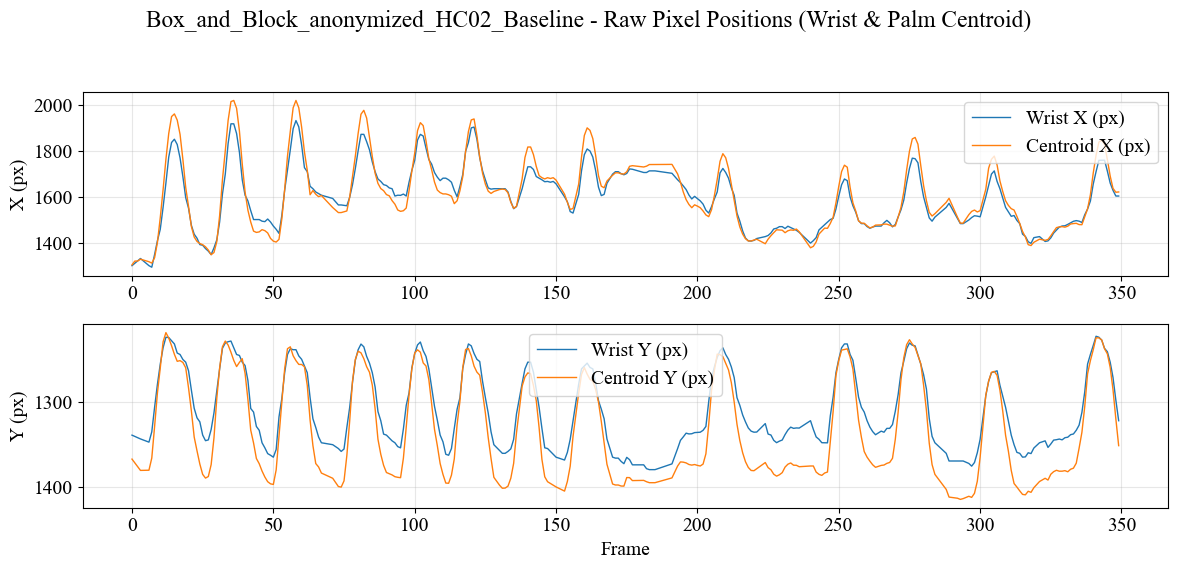

In [ ]:
video_info = keypoints_info.iloc[-2]
with open (video_info['keypoints_file']) as f:
    data = json.load(f)


# Plot raw pixel values of hand centroid and wrist for the last video in keypoints_info
frames = data[video_info['annotation_start_frame']:
              video_info['annotation_start_frame']+num_frames_to_process]
video_name = video_info['video_name'].split('.')[0]
# helper to robustly parse different landmark formats into (21,3) array of [x_px, y_px, z]
def parse_hand_landmarks(rh, width_px, height_px):
    arr = np.full((21, 3), np.nan, dtype=float)
    if rh is None:
        return arr
    # Preferred: normalized landmarks
    if 'landmarks' in rh:
        lms = rh['landmarks'][:21]
        for ii, lm in enumerate(lms):
            if lm is None:
                continue
            x = lm.get('x', np.nan)
            y = lm.get('y', np.nan)
            z = lm.get('z', np.nan)
            arr[ii, 0] = x * width_px if not (x is None or np.isnan(x)) else np.nan
            arr[ii, 1] = y * height_px if not (y is None or np.isnan(y)) else np.nan
            arr[ii, 2] = z
        return arr
    # Fall back to keypoints_3d (either list of dicts or flat list)
    if 'keypoints_3d' in rh:
        k3 = rh['keypoints_3d']
        if isinstance(k3, list) and len(k3) >= 21:
            if all(isinstance(x, dict) for x in k3[:21]):
                for ii, lm in enumerate(k3[:21]):
                    x = lm.get('x', np.nan)
                    y = lm.get('y', np.nan)
                    z = lm.get('z', np.nan)
                    arr[ii, 0] = x * width_px if not (x is None or np.isnan(x)) else np.nan
                    arr[ii, 1] = y * height_px if not (y is None or np.isnan(y)) else np.nan
                    arr[ii, 2] = z
                return arr
            # flat list of numbers
            try:
                flat = np.array(k3)
                if flat.size == 21 * 3:
                    flat = flat.reshape(21, 3)
                    arr[:, 0] = flat[:, 0] * width_px
                    arr[:, 1] = flat[:, 1] * height_px
                    arr[:, 2] = flat[:, 2]
                    return arr
            except Exception:
                pass
    # If none matched, return NaNs
    return arr

frames_hand = []
for frame in frames:
    # pick the right hand if present (fallback to single hand if only one)
    rh = next((h for h in frame.get('hands', []) if h.get('hand_id') == 'Right' or h.get('handedness') == 'Right'), None)
    if rh is None and len(frame.get('hands', [])) == 1:
        rh = frame['hands'][0]

    arr = parse_hand_landmarks(rh, width_px, height_px)
    frames_hand.append(arr)

frames_hand = np.array(frames_hand)  # shape: (T, 21, 3)

# Compute wrist (landmark 0) and palm centroid (indices: wrist, index_mcp(5), middle_mcp(9), ring_mcp(13), pinky_mcp(17))
palm_indices = [0, 5, 9, 13, 17]
wrist_x = frames_hand[:, 0, 0]
wrist_y = frames_hand[:, 0, 1]
centroid_x = np.nanmean(frames_hand[:, palm_indices, 0], axis=1)
centroid_y = np.nanmean(frames_hand[:, palm_indices, 1], axis=1)

# Plot time series
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.suptitle(f"{video_name} - Raw Pixel Positions (Wrist & Palm Centroid)")

ax1 = plt.subplot(2, 1, 1)
ax1.plot(wrist_x, label='Wrist X (px)', color='tab:blue', lw=1)
ax1.plot(centroid_x, label='Centroid X (px)', color='tab:orange', lw=1)
ax1.set_ylabel('X (px)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = plt.subplot(2, 1, 2)
ax2.plot(wrist_y, label='Wrist Y (px)', color='tab:blue', lw=1)
ax2.plot(centroid_y, label='Centroid Y (px)', color='tab:orange', lw=1)
ax2.set_ylabel('Y (px)')
ax2.set_xlabel('Frame')
ax2.invert_yaxis()  # image coordinates usually have origin at top-left
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



In [ ]:
#save the trajecotries dictionary to a json file
hand_timeseries_json = {}
for participant_id, conditions in hand_timeseries.items():
    hand_timeseries_json[participant_id] = {}
    for condition, data in conditions.items():
        hand_timeseries_json[participant_id][condition] = {
            'hand': data['hand'].tolist(),
            'pick': data['pick'].tolist(),
            'place': data['place'].tolist(),
            'wall': data['wall'].tolist()
        }

json_output_path = 'box_and_block_timeseries_data.json'
with open(json_output_path, 'w') as f:
    json.dump(hand_timeseries_json, f)

### Reprojections to check the camera calibrations

In [ ]:
def visualize_reprojection( analyzer, frame_data, image, error_threshold=15.0):
    """ Draws the computed 3D boxes/wall back onto the 2D image to verify calibration. """
    significant_reprojection_errors = []
    if analyzer.rvec is None: return image
    
    # --- 1. Project all 12 model points to 2D ---
    img_pts, _ = cv2.projectPoints(analyzer.model_points, analyzer.rvec, analyzer.tvec, analyzer.camera_matrix, analyzer.dist_coeffs)
    img_pts = img_pts.reshape(-1, 2).astype(int)
    
    # Define connection indices for the 3 shapes
    # (These assume the standard PnP order: Pick[0-3], Wall[4-7], Place[8-11])
    # Connections are (Start Point Index, End Point Index)
    WIREFRAME_CONNECTIONS = [
        # Picking Box (Indices 0-3)
        (0, 1), (1, 2), (2, 3), (3, 0), 
        # Wall (Indices 4-7) - Top, Bottom, Sides
        (4, 5), (6, 7), (4, 7), (5, 6), 
        # Placing Box (Indices 8-11)
        (8, 9), (9, 10), (10, 11), (11, 8),
        # Wall to Boxes (Optional, but good sanity check)
        (3, 7), (0, 7) # Connect back corner of pick box to front corner of wall base
    ]
    
    # --- 2. Draw Wireframe and Points ---
    
    # Draw connections (Wireframe)
    for p1_idx, p2_idx in WIREFRAME_CONNECTIONS:
        # blue lines for the geometry
        cv2.line(image, tuple(img_pts[p1_idx]), tuple(img_pts[p2_idx]), (0, 0, 255), 2)
    
    # Draw points (Circles)
    for i in range(len(img_pts)):
        # Red circles for the 12 calibration points
        cv2.circle(image, tuple(img_pts[i]), 5, (255, 0, 0), -1) 

    # --- 3. Draw true Annotated Landmarks (dynamic: use whatever exists) ---
    pts = []
    model_indices = []

    if 'picking_box_corners' in frame_data and frame_data['picking_box_corners'].get('landmarks'):
        lm = frame_data['picking_box_corners']['landmarks'][:4]
        pts.extend(lm)
        model_indices.extend([0, 1, 2, 3])

    if 'separation_wall' in frame_data and frame_data['separation_wall'].get('landmarks'):
        lm = frame_data['separation_wall']['landmarks'][:4]
        pts.extend(lm)
        model_indices.extend([4, 5, 6, 7])

    if 'placing_box_corners' in frame_data and frame_data['placing_box_corners'].get('landmarks'):
        lm = frame_data['placing_box_corners']['landmarks'][:4]
        pts.extend(lm)
        model_indices.extend([8, 9, 10, 11])

    # If no annotated points found, return early
    if len(pts) == 0:
        return image, significant_reprojection_errors

    # Subset the projected model points to match the annotated set
    img_pts_sub = img_pts[model_indices]
    
    for i, p in enumerate(pts):
        x, y = int(p['x'] * image.shape[1]), int(p['y'] * image.shape[0])
        cv2.circle(image, (x, y), 5, (0, 255, 0), -1)
        cv2.putText(image, str(i), (x-10, y-10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
    #Print difference between projected and annotated points
   
    for i, p in enumerate(pts):
        x_annot = int(p['x'] * image.shape[1])
        y_annot = int(p['y'] * image.shape[0])
        x_proj, y_proj = img_pts[i]
        error = np.sqrt((x_annot - x_proj)**2 + (y_annot - y_proj)**2)
        if error > error_threshold:  # Threshold for significant error
            significant_reprojection_errors.append((i, error))
        print(f"Point {i}: Reprojection Error = {error:.2f} pixels")
        
    return image, significant_reprojection_errors

In [ ]:
import os

# Set OpenCV to timeout faster for cloud storage videos
os.environ["OPENCV_FFMPEG_READ_ATTEMPTS"] = "4096"

for i in range(len(keypoints_info)):
    video_info = keypoints_info.iloc[i]
    video_path = video_info['video_path']
    video_name = video_path.split('/')[-1]
    keypoints_file = video_info['keypoints_file']
    match = re.search(r'(HC\d{2})', video_name)
    participant_id = match.group(1) if match else None
    
    print(f"\n--- Processing {i+1}/{len(keypoints_info)}: {video_name} ---")

    # Check if video file exists and is accessible
    if not os.path.exists(video_path):
        print(f"⚠️ Skipping: Video file not found at {video_path}")
        continue
    if participant_id not in participant_with_20mg:
        continue
    # Try to open video with a quick check first
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"⚠️ Skipping: Cannot open video file (may be on cloud storage)")
        cap.release()
        continue

    with open(keypoints_file) as f:
        data = json.load(f)

    meta_focal_length = video_meta_data.loc[0, 'FocalLength(35mm_Equiv)']
    MANUAL_FOCAL_LENGTH = None  # Set this to a value (e.g., 50.0) if you want to override metadata
    focal_length = MANUAL_FOCAL_LENGTH if MANUAL_FOCAL_LENGTH is not None else meta_focal_length
    resolution_str = video_meta_data.loc[0, 'Resolution']
    height_px, width_px = map(int, resolution_str.split('x'))
    first_annotated_frame = video_info['annotation_start_frame']
    last_annotated_frame = video_info['last_annotated_frame']
    
    # Slice data to annotated range
    data = data[first_annotated_frame:first_annotated_frame+last_annotated_frame]
    
    # Get the first frame data AFTER slicing (this is the calibration frame)
    first_frame_data = data[0]
    
    analyzer = BoxBlockGeometry(focal_length_35mm=focal_length, image_res=(width_px, height_px))
    # Pass the frame data dictionary, not the frame index
    if not analyzer.calibrate(first_frame_data):
        print(f"⚠️ Calibration failed for {video_name}")
        cap.release()
        continue
    
    # Seek to the annotated start frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(first_annotated_frame))
    ret, frame = cap.read()
    
    if not ret:
        print(f"⚠️ Failed to read frame {first_annotated_frame} from {video_name}")
        cap.release()
        continue
        
    captured_idx = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    print(f"Captured video frame index: {captured_idx} (requested {int(first_annotated_frame)})")

    vis_image, errors = visualize_reprojection(analyzer, first_frame_data, frame)
    if errors and len(errors) > 0:
        print(f"Significant reprojection errors detected for {video_name}:")
        plt.figure(figsize=(15, 10))
        plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
        plt.title("Reprojection of calibration Points (red) and true Landmarks (green)")
        plt.axis('off')
        plt.show()
    else:
        print(f"✓ No significant reprojection errors detected for {video_name}")

    cap.release()

print("\n=== Processing complete ===")

In [ ]:
def print_camera_diagnostics(analyzer):
    if analyzer.rvec is None:
        print("Camera not calibrated.")
        return

    # 1. Get Rotation Matrix
    R_mat, _ = cv2.Rodrigues(analyzer.rvec)
    
    # 2. Extract Euler Angles correctly (Return value is a tuple of 6 items)
    # The first item (eulerAngles) contains [pitch, yaw, roll] in degrees
    eulerAngles, mtxR, mtxQ, Qx, Qy, Qz = cv2.RQDecomp3x3(R_mat)
    
    pitch = eulerAngles[0]
    yaw   = eulerAngles[1]
    roll  = eulerAngles[2]
    
    # 3. Get Camera Position
    cam_pos = analyzer.camera_pos_world.flatten()
    
    print("-" * 40)
    print("DIAGNOSTICS: Camera Geometry")
    print("-" * 40)
    print(f"Camera Height (Z):    {cam_pos[2]:.1f} mm")
    print(f"Camera Lateral (X):   {cam_pos[0]:.1f} mm")
    print(f"Camera Depth (Y):     {cam_pos[1]:.1f} mm")
    print("-" * 40)
    print(f"Calculated Pitch (X): {pitch:.1f} degrees")
    print(f"Calculated Yaw (Y):   {yaw:.1f} degrees")
    print(f"Calculated Roll (Z):  {roll:.1f} degrees")
    print("-" * 40)
    
    # Interpret the Pitch to diagnose the Z-height issue
    abs_pitch = abs(pitch)
    
 

# Run the diagnostics
print_camera_diagnostics(analyzer)

## Run exploratory analysis

In [99]:
import json
import numpy as np

json_input_path = 'box_and_block_timeseries_data.json'
with open(json_input_path, 'r') as f:
    hand_timeseries_json = json.load(f)

# Rebuild the original structure: hand_timeseries[participant_id][condition][trajectory_name] -> np.ndarray
hand_timeseries = {}
for participant_id, conditions in hand_timeseries_json.items():
    hand_timeseries[participant_id] = {}
    for condition, data in conditions.items():
        hand_timeseries[participant_id][condition] = {
            'hand': np.asarray(data.get('hand', [])),
            'pick': np.asarray(data.get('pick', [])),
            'place': np.asarray(data.get('place', [])),
            'wall': np.asarray(data.get('wall', []))
        }

print(f"Loaded {len(hand_timeseries)} participants from {json_input_path}")

Loaded 11 participants from box_and_block_timeseries_data.json


Analyzing Participant: HC01
Analyzing Participant: HC02
Analyzing Participant: HC03
Analyzing Participant: HC04
Analyzing Participant: HC08
Analyzing Participant: HC09
Analyzing Participant: HC10
Analyzing Participant: HC11
Analyzing Participant: HC12
Analyzing Participant: HC13
Available columns: ['subject_id', 'base_centroid_duration_s', 'base_centroid_moving_duration_s', 'base_centroid_percent_moving', 'base_centroid_mean_velocity_m_s', 'base_centroid_mean_moving_velocity_m_s', 'base_centroid_peak_velocity_m_s', 'base_centroid_mean_acceleration_m_s2', 'base_centroid_peak_acceleration_m_s2', 'base_centroid_smoothness_sparc', 'base_centroid_path_efficiency', 'base_centroid_picking_side_speed_m_s', 'base_centroid_placing_side_speed_m_s', 'base_centroid_inside_box_speed_m_s', 'base_centroid_over_wall_speed_m_s', 'base_centroid_time_picking_side_s', 'base_centroid_time_placing_side_s', 'base_centroid_time_inside_box_s', 'base_centroid_time_over_wall_s', 'base_centroid_picking_placing_rat

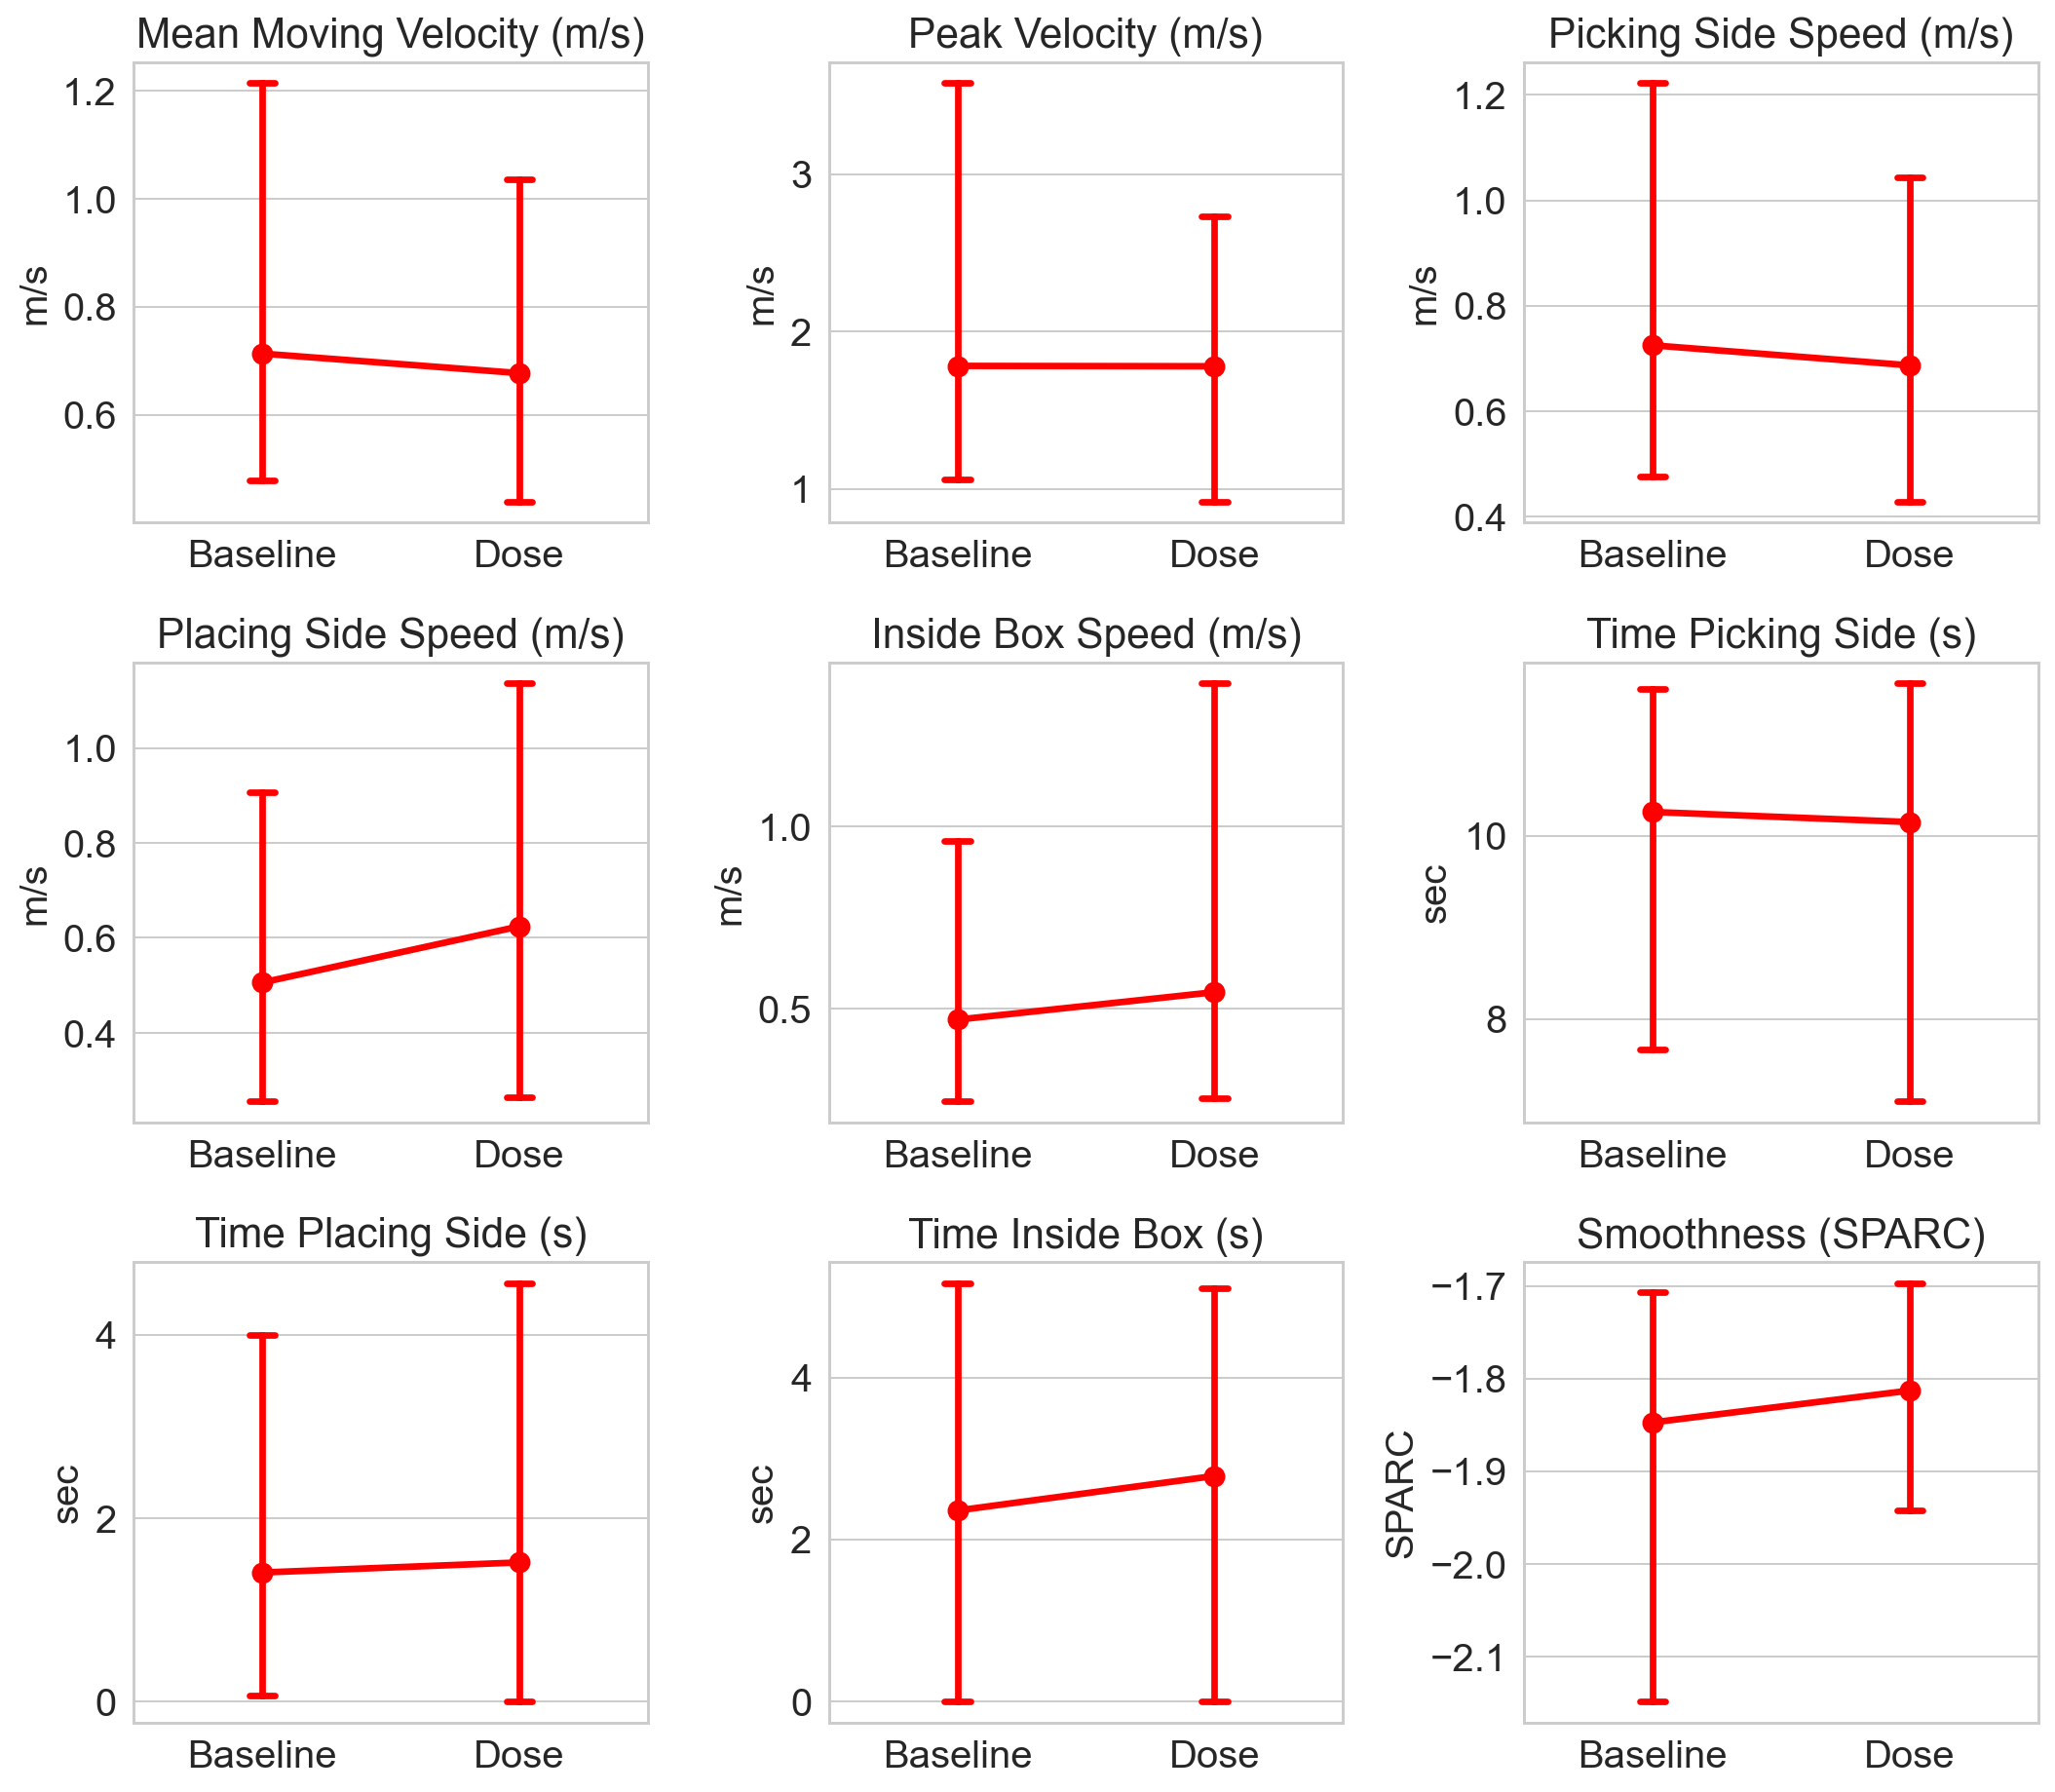


=== Summary Statistics ===
Mean Moving Velocity (m/s): Baseline=0.713, Dose=0.677, Delta=-0.036
Peak Velocity (m/s): Baseline=1.781, Dose=1.779, Delta=-0.002
Picking Side Speed (m/s): Baseline=0.725, Dose=0.687, Delta=-0.038
Placing Side Speed (m/s): Baseline=0.506, Dose=0.624, Delta=+0.118
Inside Box Speed (m/s): Baseline=0.471, Dose=0.546, Delta=+0.075
Time Picking Side (s): Baseline=10.260, Dose=10.150, Delta=-0.110
Time Placing Side (s): Baseline=1.407, Dose=1.517, Delta=+0.110
Time Inside Box (s): Baseline=2.357, Dose=2.783, Delta=+0.427
Smoothness (SPARC): Baseline=-1.847, Dose=-1.813, Delta=+0.034


In [109]:
exploratory_results = []
animate = False  # Set to True to enable animation

# Create extractor once (reusable for all participants)
extractor = FeatureExtractor(fps=30)

#return ppt_id of rows that have 20 mg in colmun dose_alc_manual
participant_with_20mg = dose_order.loc[dose_order['dose_alc_manual'].str.contains('20mg'), 'ppt_id'].values

for participant_id in participants_with_hand_annotations:
    if participant_id not in hand_timeseries.keys() or participant_id == 'HC14':
        print(f"Participant {participant_id} not found in hand_timeseries, skipping.")
        continue
    # Retrieve the full data dictionaries
    print(f"Analyzing Participant: {participant_id}")
    baseline_data = hand_timeseries[participant_id]['Baseline']
    dose_data = hand_timeseries[participant_id]['Dose']
    
    # Extract just the hand frames for kinematic analysis
    baseline_frames = baseline_data['hand']
    dose_frames = dose_data['hand']
    
    result_row = extractor.process_subject(baseline_frames, dose_frames, participant_id)
    
    exploratory_results.append(result_row)

    
exploratory_results_df = pd.DataFrame(exploratory_results)

plot_exploratory_analysis(exploratory_results_df)

In [101]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as scipy_stats


def calculate_dynamic_rope(data_array, effect_size_threshold=0.1):
    """
    Calculates raw ROPE limits based on the standard deviation of the data 
    and a standardized effect size threshold (default 0.1 for negligible).
    """
    # Calculate SD of the observed metric
    std_dev = np.std(data_array, ddof=1)
    
    # Scale the standardized threshold by the raw SD
    limit = effect_size_threshold * std_dev
    
    return (-limit, limit)

def run_bayesian_analysis(df, metric_name, base_col, dose_col, delta_col):
    print(f"--- Bayesian Analysis for {metric_name} ---")
    
    # Select columns and drop NaNs
    data = df[[base_col, dose_col, delta_col]].dropna()
    n_samples = len(data)
    print(f"N = {n_samples} subjects included.")
    
    with pm.Model() as model:
        # --- 1. Analysis of Delta (Change in Mean) ---
        # We model the distribution of the delta scores directly
        # If mu_delta is significantly non-zero, there is a consistent change
        mu_delta = pm.Normal("mu_delta", mu=0, sigma=10) 
        sigma_delta = pm.HalfNormal("sigma_delta", sigma=10)
        
        # Likelihood for delta
        delta_obs = pm.Normal("delta_obs", mu=mu_delta, sigma=sigma_delta, observed=data[delta_col])
        
        # --- 2. Analysis of Variability (Change in Between-Subject Variability) ---
        # We model the Base and Dose distributions separately to estimate their standard deviations (sigma)
        # sigma represents the "between-subject variability"
        
        # Base Condition
        mu_base = pm.Normal("mu_base", mu=data[base_col].mean(), sigma=data[base_col].std() * 10)
        sigma_base = pm.HalfNormal("sigma_base", sigma=data[base_col].std() * 10)
        base_obs = pm.Normal("base_obs", mu=mu_base, sigma=sigma_base, observed=data[base_col])
        
        # Dose Condition
        mu_dose = pm.Normal("mu_dose", mu=data[dose_col].mean(), sigma=data[dose_col].std() * 10)
        sigma_dose = pm.HalfNormal("sigma_dose", sigma=data[dose_col].std() * 10)
        dose_obs = pm.Normal("dose_obs", mu=mu_dose, sigma=sigma_dose, observed=data[dose_col])
        
        # Deterministic comparisons of variability
        diff_sigma = pm.Deterministic("diff_sigma", sigma_dose - sigma_base)
        ratio_sigma = pm.Deterministic("ratio_sigma", sigma_dose / sigma_base)
        
        # Comparison of means (alternative to delta, but delta is usually more sensitive for paired data)
        diff_mu = pm.Deterministic("diff_mu", mu_dose - mu_base)
        
        # Sampling
        idata = pm.sample(draws=2000, tune=1000, return_inferencedata=True, progressbar=True)
        
    return idata

def plot_bayesian_results_publishable(idata, df, delta_col, metric_label, color='#0072B2'):
    """
    Generates publication-ready plots for Bayesian analysis results.
    Uses smooth KDE posterior densities with HDI intervals and ROPE shading.
    Matches the aesthetics of dimensionality_analysis plotting style.
    """
    # Publication-ready styling
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.size': 16,
        'axes.labelsize': 16,
        'axes.titlesize': 17,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 13,
        'axes.linewidth': 1.2,
        'axes.spines.top': False,
        'axes.spines.right': False,
    })
    
    # Calculate ROPE for the mean difference (mu_delta)
    delta_data = df[delta_col].dropna().values
    rope_limits = calculate_dynamic_rope(delta_data)
    
    print(f"Calculated ROPE for {metric_label}: {rope_limits}")
    
    # Color palette - colorblind friendly
    color_main = color if color != 'C0' else "#0072B2"  # Blue
    color_secondary = "#009E73"  # Green for variability
    color_rope = "#CCCCCC"  # Light gray for ROPE
    
    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    def plot_posterior_density(ax, samples, color, rope=None, ref_val=None, 
                               xlabel='', title='', show_rope_pct=True):
        """Plot a posterior density with HDI and optional ROPE shading."""
        samples = samples.flatten()
        
        # Compute KDE
        kde = scipy_stats.gaussian_kde(samples)
        x_range = np.linspace(samples.min() - 0.15 * np.ptp(samples), 
                              samples.max() + 0.15 * np.ptp(samples), 500)
        density = kde(x_range)
        
        # Normalize density for better visualization
        density = density / density.max() * 0.85
        
        # Add ROPE shading first (behind densities)
        if rope is not None:
            ax.axvspan(rope[0], rope[1], alpha=0.25, color=color_rope, 
                       label='ROPE', zorder=0)
        
        # Add reference line
        if ref_val is not None:
            ax.axvline(ref_val, color='black', linestyle='--', lw=1, alpha=0.5, zorder=1)
        
        # Plot filled density
        ax.fill_between(x_range, 0, density, alpha=0.4, color=color, label='Posterior')
        ax.plot(x_range, density, color=color, lw=1.5)
        
        # Compute HDI (94%)
        hdi_low, hdi_high = np.percentile(samples, [3, 97])
        mean_val = samples.mean()
        
        # Plot HDI bar
        bar_height = 0.02
        ax.hlines(bar_height, hdi_low, hdi_high, color=color, lw=3, alpha=0.8)
        
        # Plot point estimate (mean)
        ax.scatter([mean_val], [bar_height], color=color, s=60, zorder=5, 
                   edgecolor='white', linewidth=1.5)
        
        # Calculate and annotate % in ROPE
        if rope is not None and show_rope_pct:
            pct_in_rope = np.mean((samples >= rope[0]) & (samples <= rope[1])) * 100
            textstr = f'% in ROPE: {pct_in_rope:.1f}%\nMean: {mean_val:.3f}\n94% HDI: [{hdi_low:.3f}, {hdi_high:.3f}]'
        else:
            textstr = f'Mean: {mean_val:.3f}\n94% HDI: [{hdi_low:.3f}, {hdi_high:.3f}]'
        
        props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
        ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', horizontalalignment='right', bbox=props)
        
        # Formatting
        ax.set_title(title, fontweight='bold', pad=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Posterior Density')
        ax.set_ylim(0, 1.0)
        ax.set_yticks([])  # Remove y-axis ticks for density plots
        ax.legend(loc='upper left', framealpha=0.9)
        
        return mean_val, (hdi_low, hdi_high)
    
    # 1. Mean Difference (mu_delta)
    mu_delta_samples = idata.posterior["mu_delta"].values
    plot_posterior_density(
        axes[0], 
        mu_delta_samples, 
        color_main,
        rope=rope_limits,
        ref_val=0,
        xlabel=f'Difference (Dose − Baseline)',
        title=f'Change in {metric_label}\n(Posterior of Mean Difference)',
        show_rope_pct=True
    )
    
    # 2. Variability Ratio (ratio_sigma)
    ratio_sigma_samples = idata.posterior["ratio_sigma"].values
    plot_posterior_density(
        axes[1], 
        ratio_sigma_samples, 
        color_secondary,
        rope=None,  # No ROPE for ratio
        ref_val=1,
        xlabel='Ratio (σ_Dose / σ_Base)',
        title=f'Between-Subject Variability Ratio\n(Posterior of Sigma Ratio)',
        show_rope_pct=False
    )
    
    #plt.suptitle(f'Bayesian Analysis: {metric_label}', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85, wspace=0.25)
    plt.savefig(f"plots/bayesian_kinematics_analysis_{delta_col}.pdf", dpi=600, bbox_inches='tight')
    plt.show()
    
    return fig

RUNNING BAYESIAN ANALYSIS: VELOCITY
--- Bayesian Analysis for Velocity (m/s) ---
N = 10 subjects included.


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_delta, sigma_delta, mu_base, sigma_base, mu_dose, sigma_dose]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


Calculated ROPE for Velocity (m/s): (np.float64(-0.010483508882466241), np.float64(0.010483508882466241))


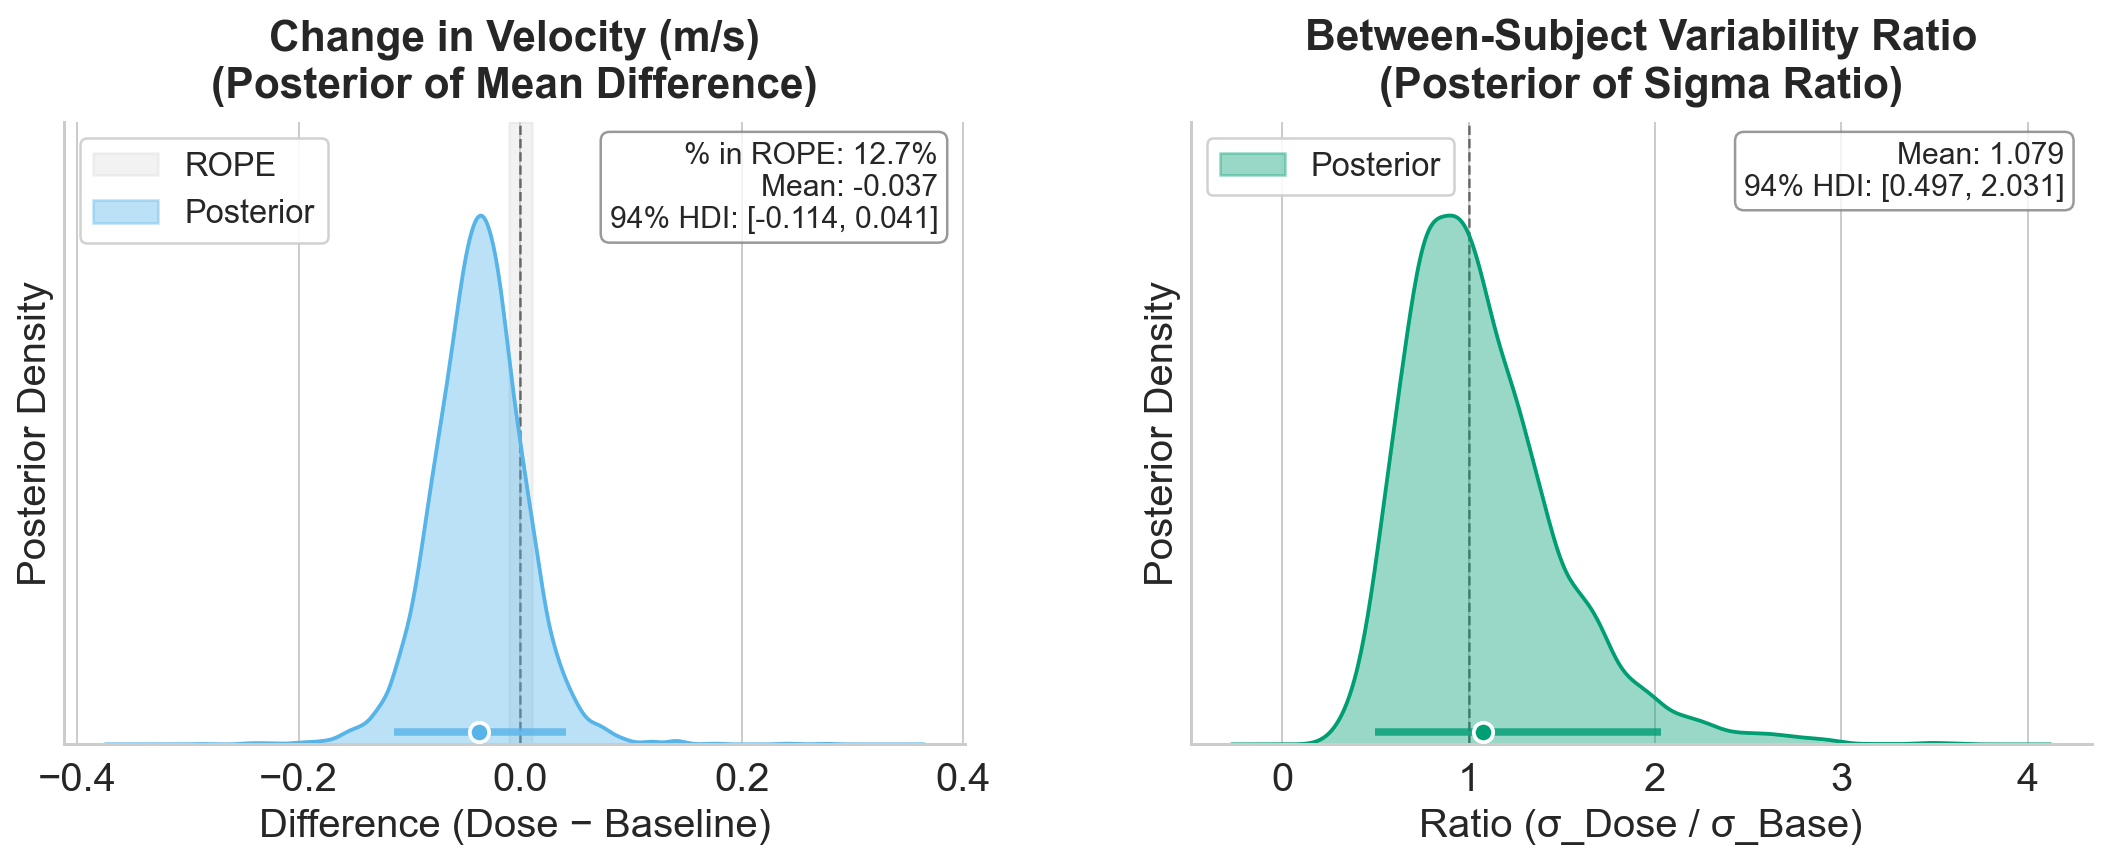

Initializing NUTS using jitter+adapt_diag...





RUNNING BAYESIAN ANALYSIS: Time pciking inside box
--- Bayesian Analysis for Time inside box (s) ---
N = 10 subjects included.


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_delta, sigma_delta, mu_base, sigma_base, mu_dose, sigma_dose]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


Calculated ROPE for Time inside box (s): (np.float64(-0.23566978362441857), np.float64(0.23566978362441857))


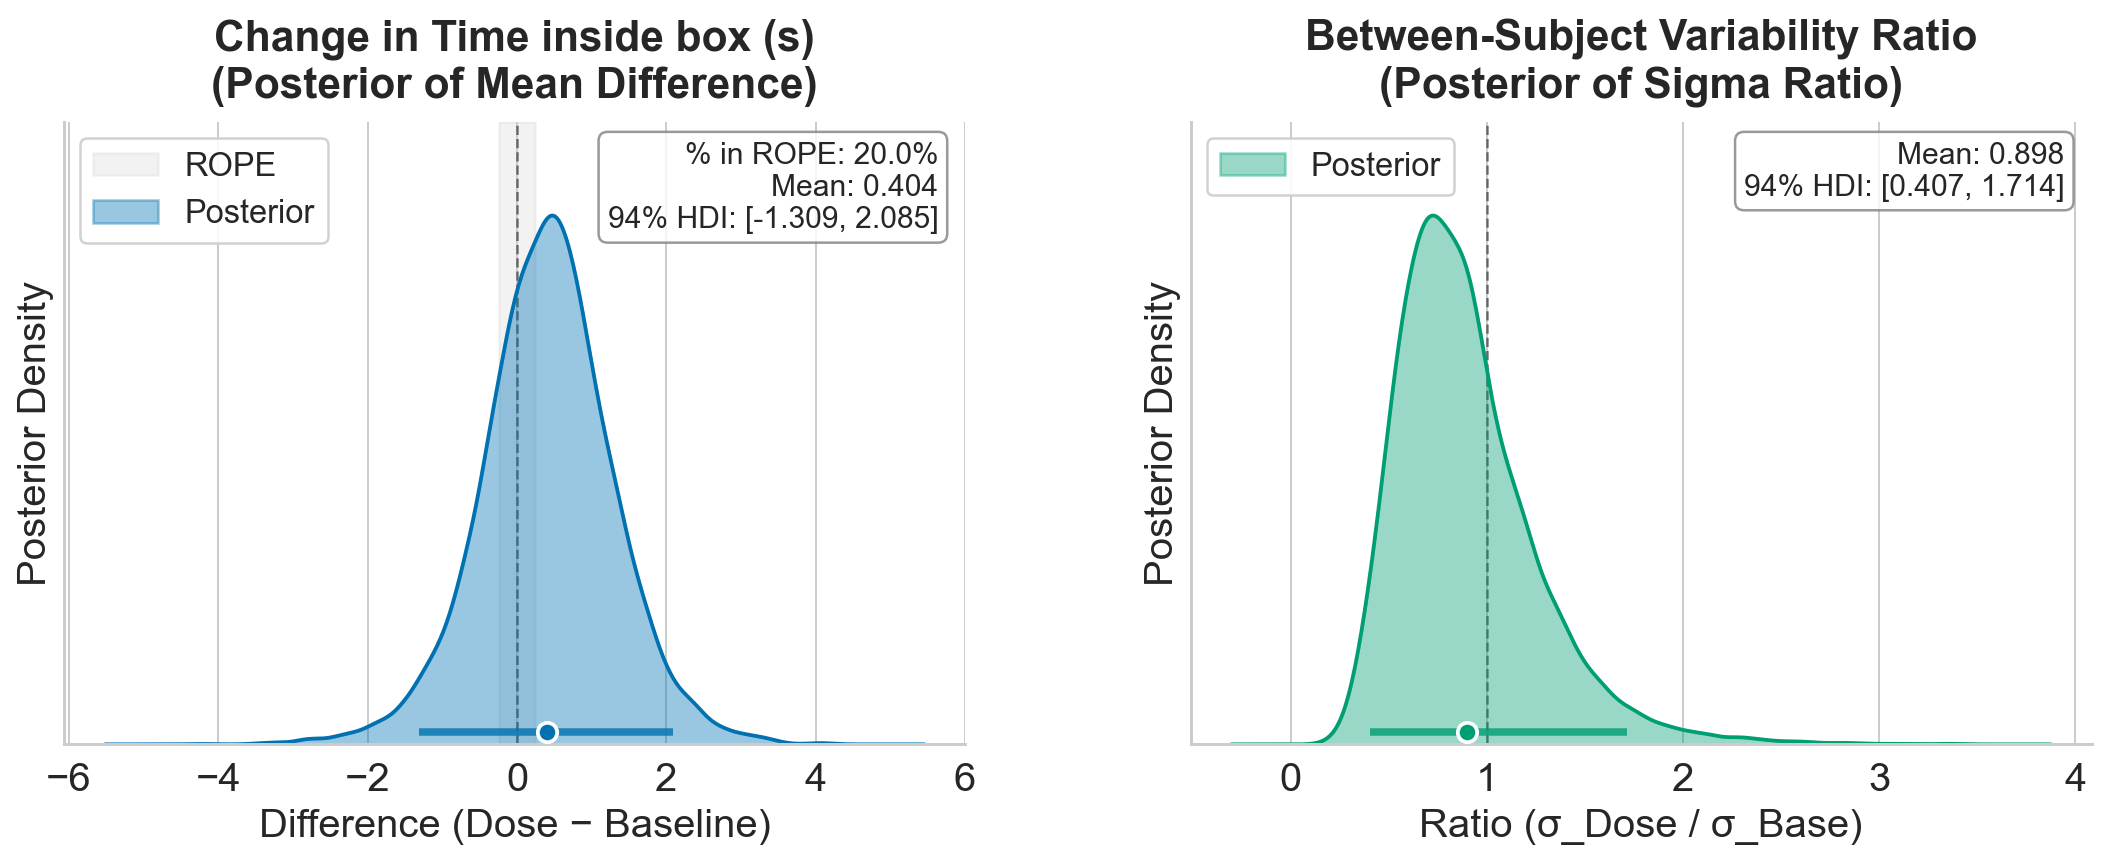

Initializing NUTS using jitter+adapt_diag...





RUNNING BAYESIAN ANALYSIS: SMOOTHNESS (SPARC)
--- Bayesian Analysis for Smoothness (SPARC) ---
N = 10 subjects included.


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_delta, sigma_delta, mu_base, sigma_base, mu_dose, sigma_dose]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


In [102]:
# Run Bayesian Analysis for Velocity
print("=========================================")
print("RUNNING BAYESIAN ANALYSIS: VELOCITY")
print("=========================================")
idata_vel = run_bayesian_analysis(
    exploratory_results_df, 
    "Velocity (m/s)",
    "base_centroid_mean_moving_velocity_m_s",
    "dose_centroid_mean_moving_velocity_m_s",
    "delta_velocity"
)

# Plot Publication Ready Figure
fig_vel = plot_bayesian_results_publishable(
    idata_vel,
    exploratory_results_df,
    "delta_velocity",
    "Velocity (m/s)",
    color="#56B4E9" # Colorblind safe blue
)
plt.show()

print("\n\n")
print("=========================================")
print("RUNNING BAYESIAN ANALYSIS: Time pciking inside box")
print("=========================================")
idata_time_picking = run_bayesian_analysis(
    exploratory_results_df, 
    "Time inside box (s)",
    "base_centroid_time_inside_box_s",
    "dose_centroid_time_inside_box_s",
    "delta_time_inside_box"
)

fig_time_picking = plot_bayesian_results_publishable(
    idata_time_picking,
    exploratory_results_df,
    "delta_time_inside_box",
    "Time inside box (s)",
    color="#0072B2" # Colorblind safe dark blue
)
plt.show()



print("\n\n")

# Run Bayesian Analysis for Smoothness (SPARC)
print("=========================================")
print("RUNNING BAYESIAN ANALYSIS: SMOOTHNESS (SPARC)")
print("=========================================")
idata_smooth = run_bayesian_analysis(
    exploratory_results_df, 
    "Smoothness (SPARC)",
    "base_centroid_smoothness_sparc",
    "dose_centroid_smoothness_sparc",
    "delta_smoothness"
)


plt.show()

Calculated ROPE for Smoothness (SPARC): (np.float64(-0.011325696218971823), np.float64(0.011325696218971823))


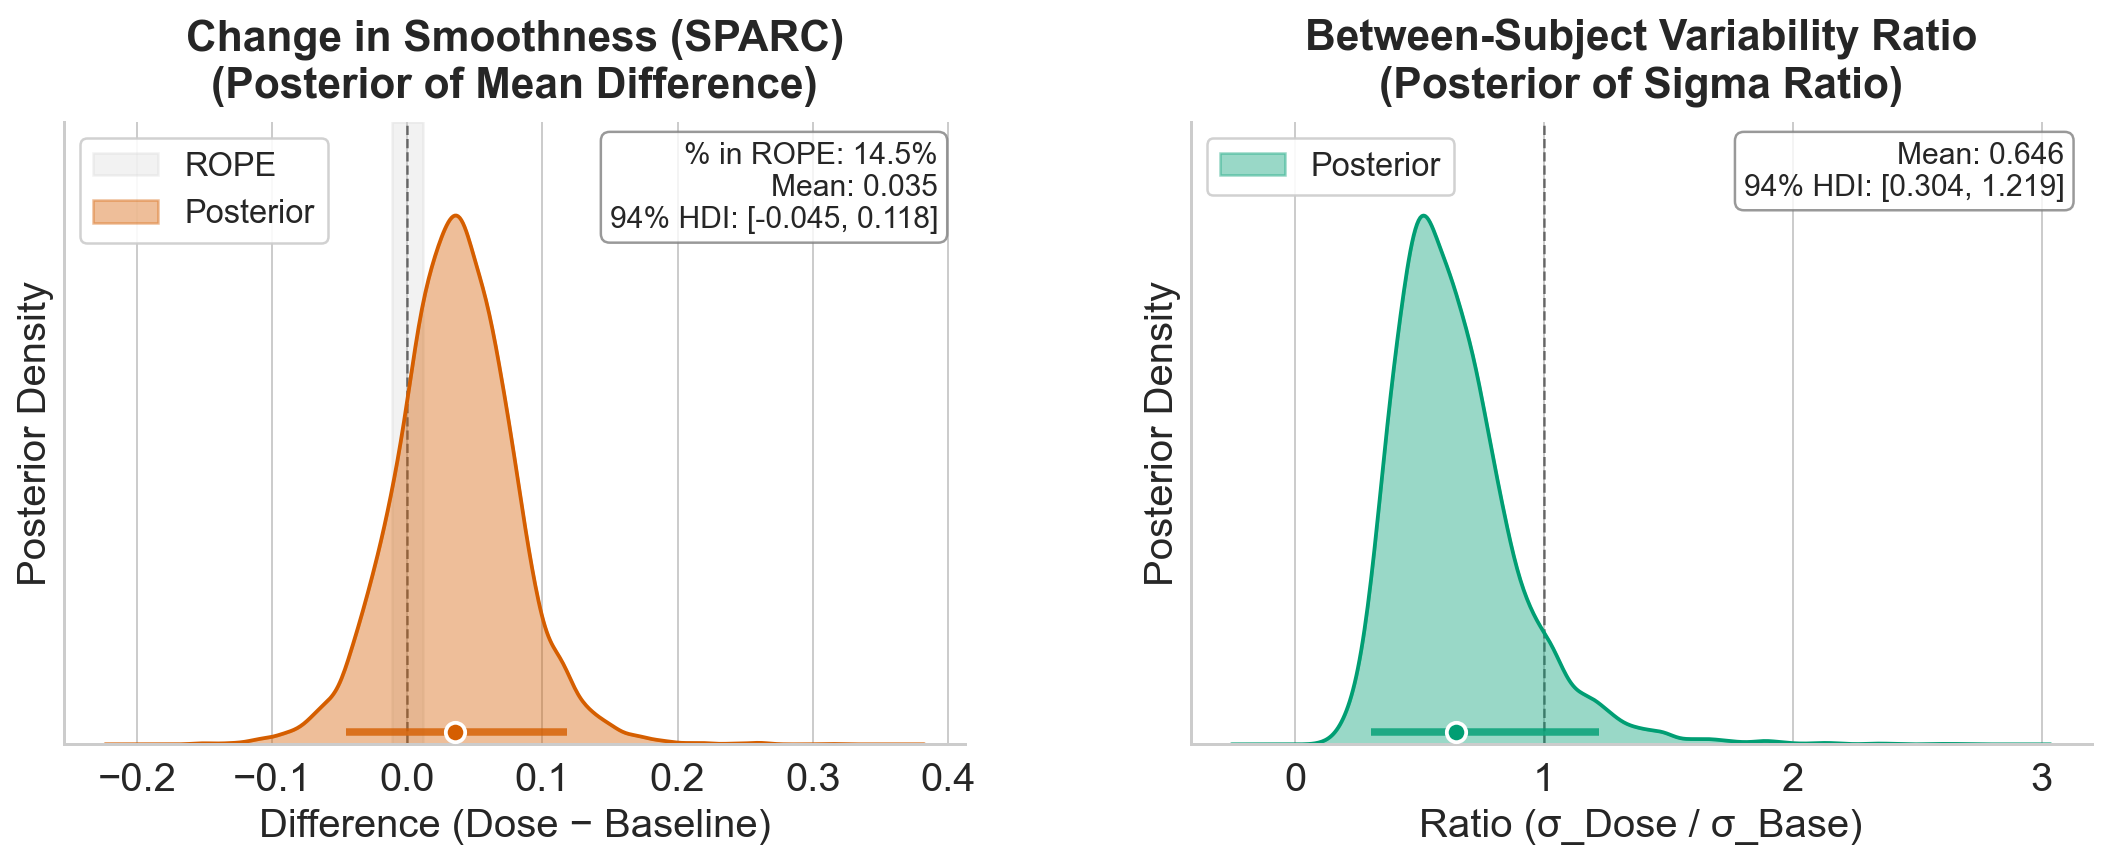

In [103]:
# Plot Publication Ready Figure
fig_smooth = plot_bayesian_results_publishable(
    idata_smooth,
    exploratory_results_df,
    "delta_smoothness",
    "Smoothness (SPARC)",
    color="#D55E00" # Colorblind safe vermillion
)


/var/folders/8l/lvwkyjcx0_z8571ry2j7g3nr0000gq/T/ipykernel_26445/688536523.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Condition')
/var/folders/8l/lvwkyjcx0_z8571ry2j7g3nr0000gq/T/ipykernel_26445/688536523.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=wall_touches_count, x='condition', y='wall_touches', ci='sd')


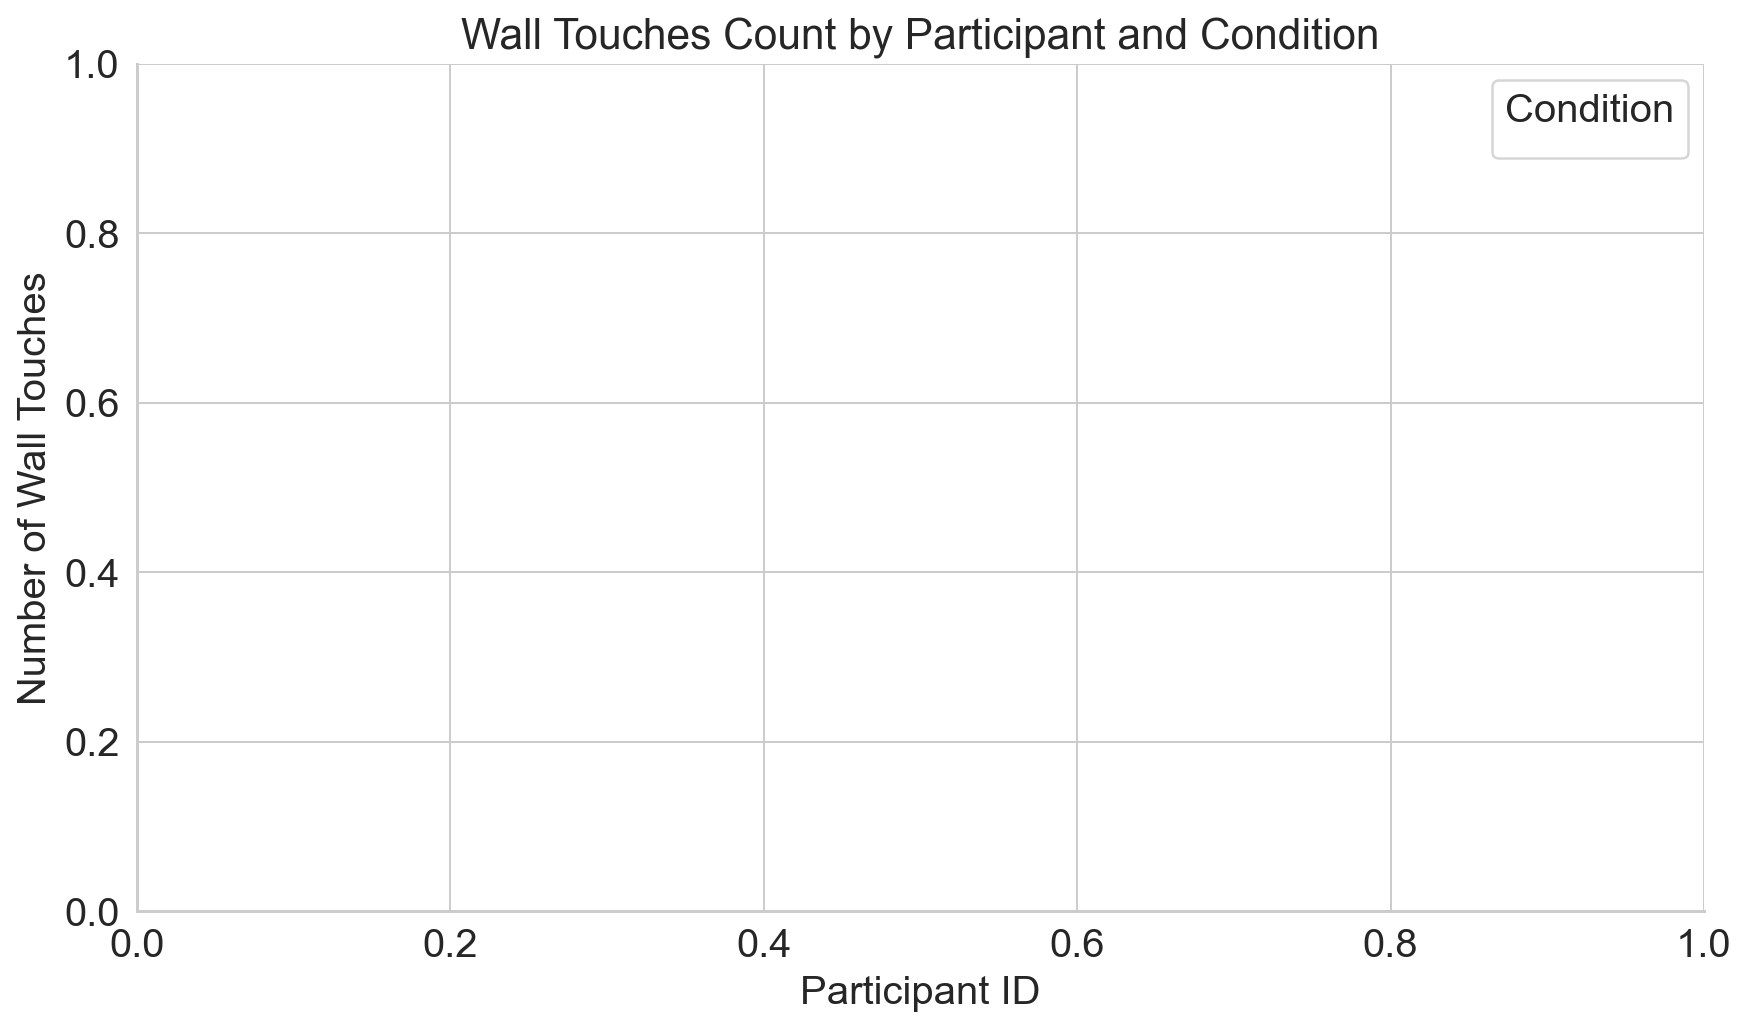

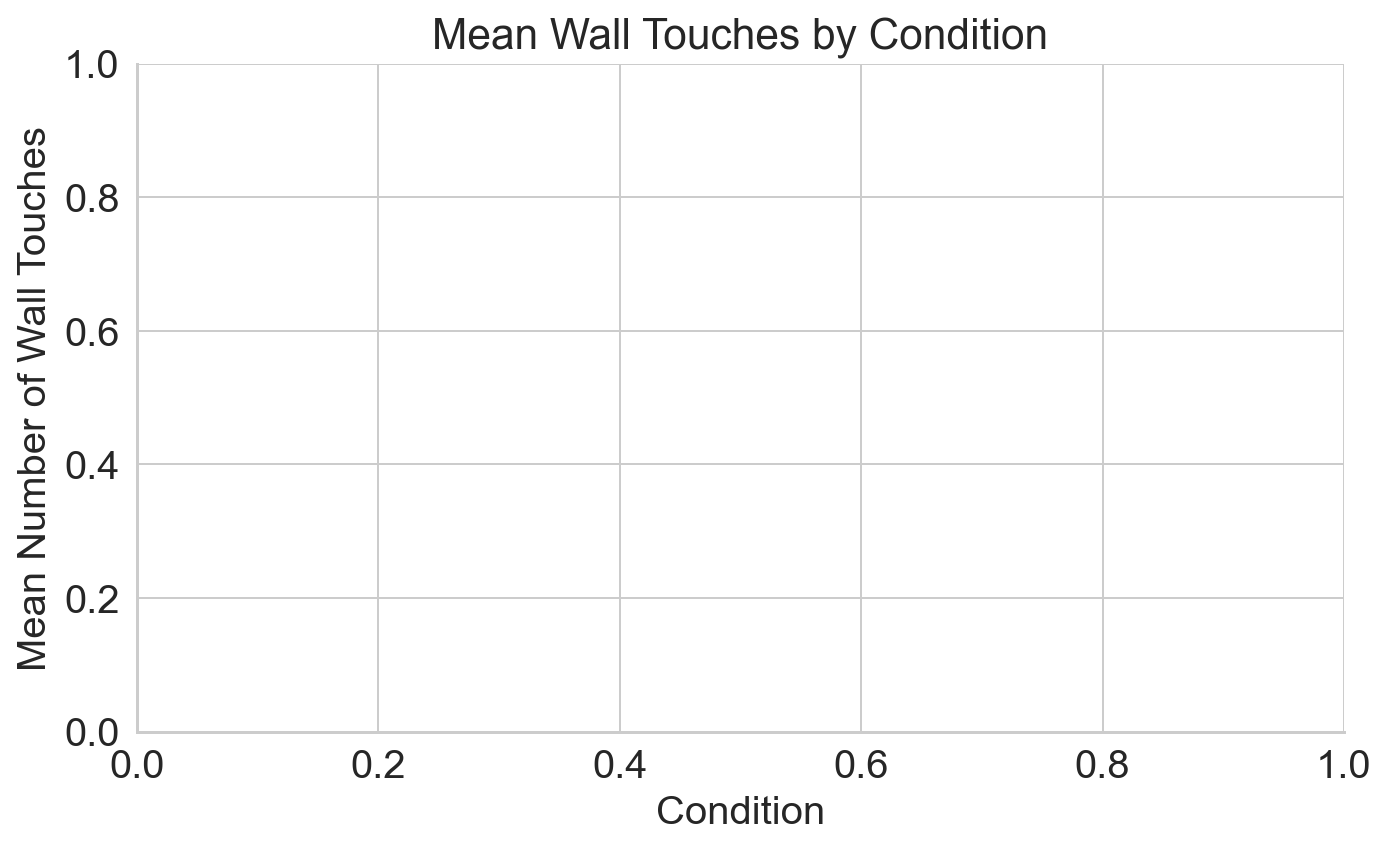

In [104]:
wall_touches_count.sort_values(by=['participant_id', 'condition'], inplace=True)

#plot the wall touches count for each condition per participant as a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=wall_touches_count, x='participant_id', y='wall_touches', hue='condition')
plt.title('Wall Touches Count by Participant and Condition')
plt.xlabel('Participant ID')
plt.ylabel('Number of Wall Touches')
plt.legend(title='Condition')
plt.tight_layout()
plt.savefig("plots/wall_touches_count.png", dpi=600, bbox_inches='tight')  

#plot the mean and std of wall touches per condition
plt.figure(figsize=(8, 5))
sns.barplot(data=wall_touches_count, x='condition', y='wall_touches', ci='sd')
plt.title('Mean Wall Touches by Condition')
plt.xlabel('Condition')
plt.ylabel('Mean Number of Wall Touches')
plt.tight_layout()
plt.savefig("plots/mean_wall_touches.png", dpi=600, bbox_inches='tight')   
plt.show()


Calculated ROPE for Smoothness (SPARC): (np.float64(-0.011325696218971823), np.float64(0.011325696218971823))


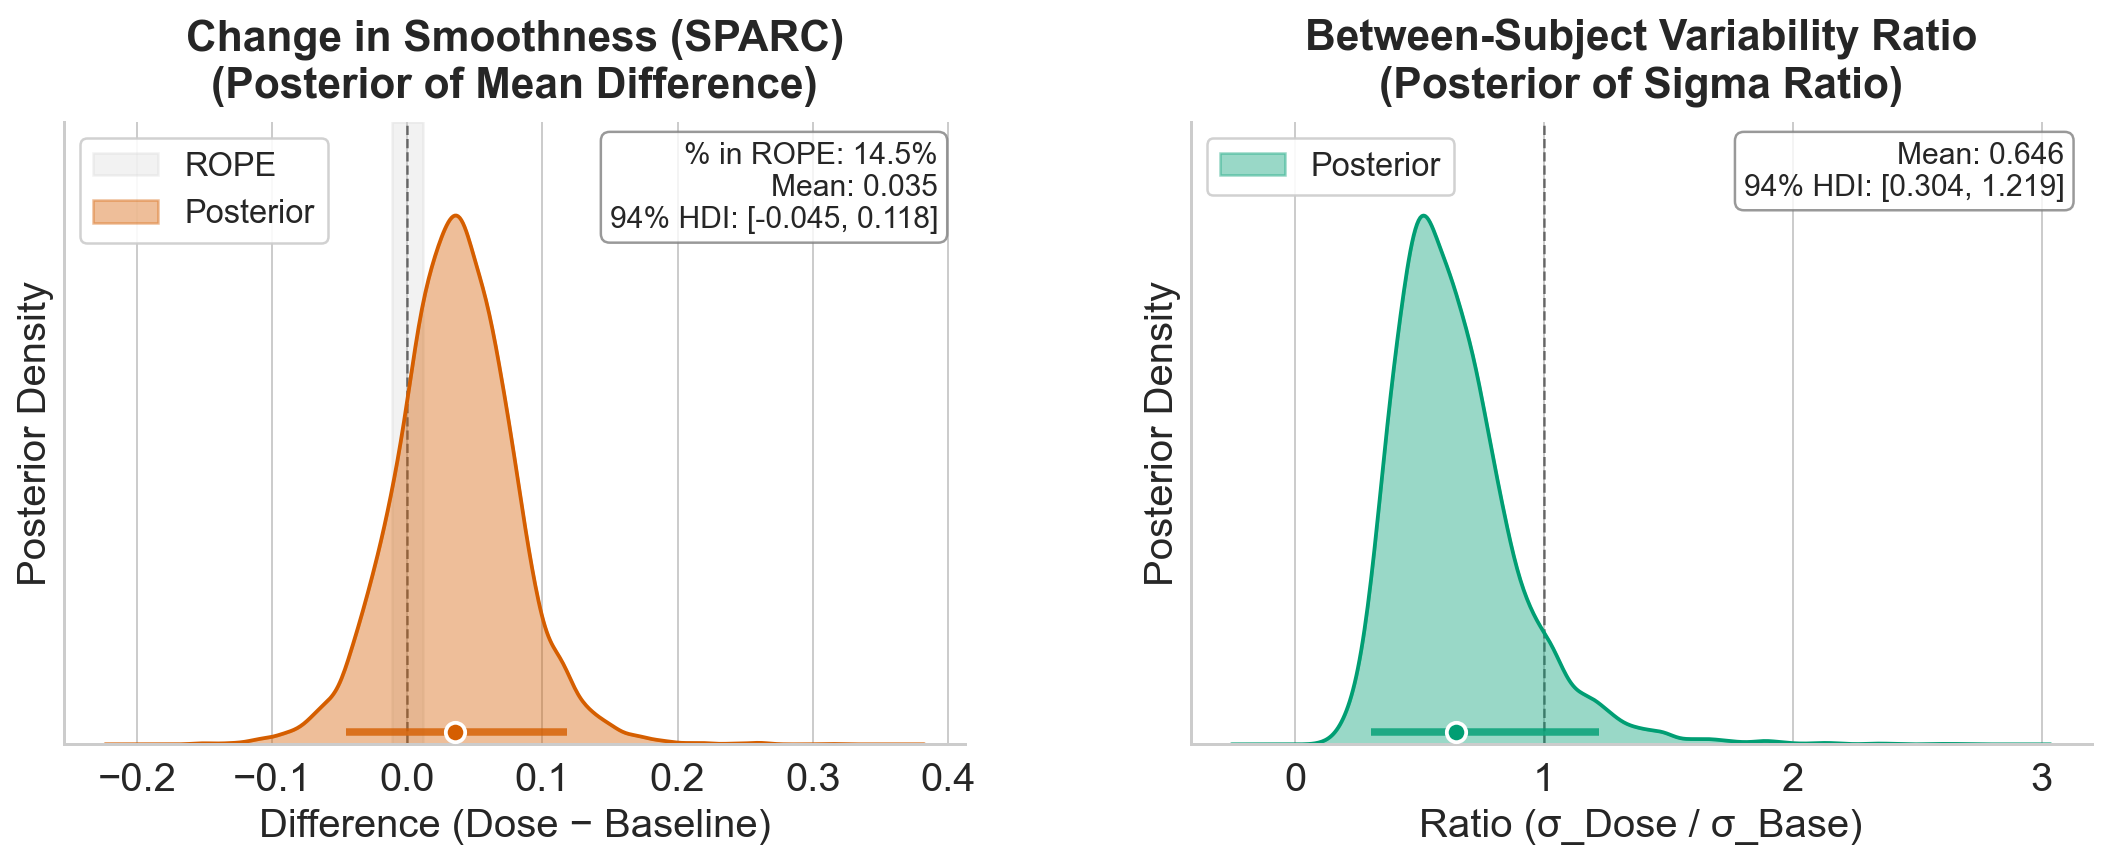

In [105]:
# Plot Publication Ready Figure
fig_smooth = plot_bayesian_results_publishable(
    idata_smooth,
    exploratory_results_df,
    "delta_smoothness",
    "Smoothness (SPARC)",
    color="#D55E00" # Colorblind safe vermillion
)


KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['base_centroid_picking_side_speed_mm_s', 'dose_centroid_picking_side_speed_mm_s']"

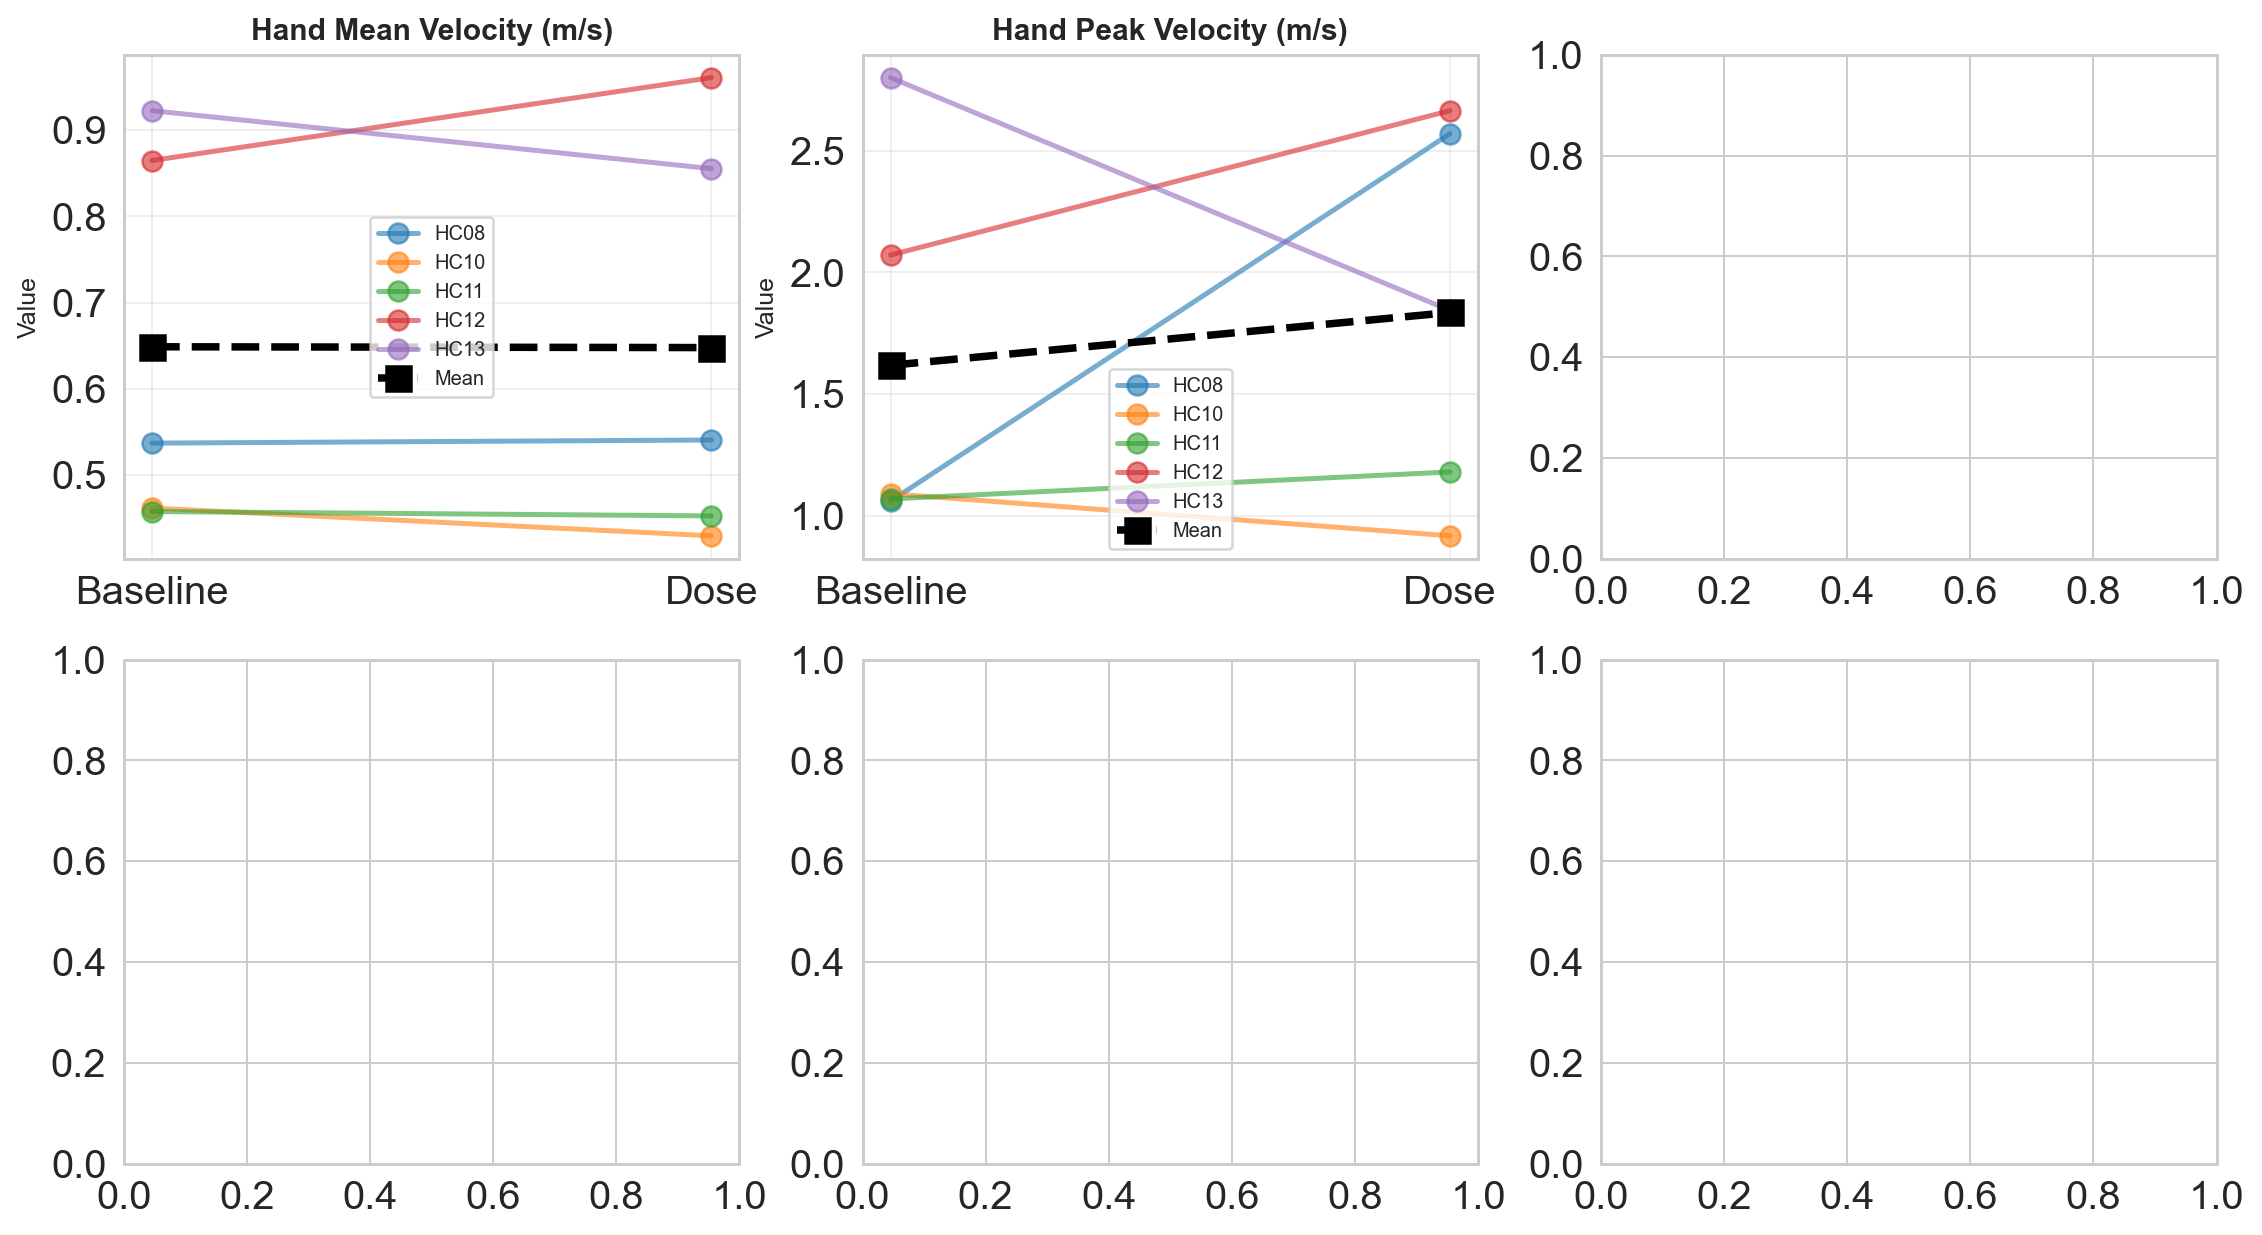

In [106]:
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt


#subset to only participants with 20mg dose
exploratory_results_df = exploratory_results_df[exploratory_results_df['subject_id'].isin(participant_with_20mg)]

# Set style
sns.set_style("whitegrid")

# Define all metrics to plot
metrics = [
    ('centroid_mean_velocity_m_s', 'Hand Mean Velocity (m/s)', 'Speed'),
    ('centroid_peak_velocity_m_s', 'Hand Peak Velocity (m/s)', 'Speed'),
    ('centroid_picking_side_speed_mm_s', 'Hand Picking Speed (mm/s)', 'Speed'),
    ('centroid_placing_side_speed_mm_s', 'Hand Placing Speed (mm/s)', 'Speed'),
    ('centroid_smoothness_sparc', 'Hand Smoothness Score', 'Quality'),
    ('centroid_picking_placing_ratio', 'Picking/Placing Ratio (%)', 'Spatial'),
]

# Create a large figure with subplots
n_metrics = len(metrics)
n_cols = 3
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Plot each metric
for idx, (metric, title, category) in enumerate(metrics):
    ax = axes[idx]
    
    # Prepare data
    plot_data = exploratory_results_df.melt(
        id_vars=['subject_id'], 
        value_vars=[f'base_{metric}', f'dose_{metric}'],
        var_name='Condition', 
        value_name='Value'
    )
    
    # Clean labels
    plot_data['Condition'] = plot_data['Condition'].map(
        {f'base_{metric}': 'Baseline', f'dose_{metric}': 'Dose'}
    )
    
    # Plot individual trajectories
    for subject in exploratory_results_df['subject_id'].unique():
        subject_data = plot_data[plot_data['subject_id'] == subject]
        ax.plot(subject_data['Condition'], subject_data['Value'], 
                'o-', alpha=0.6, linewidth=2, markersize=8, label=subject)
    
    # Add group mean
    means = plot_data.groupby('Condition')['Value'].mean()
    ax.plot(['Baseline', 'Dose'], means.values, 
            'k--', linewidth=3, marker='s', markersize=10, label='Mean')
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Value', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Remove empty subplots
for idx in range(n_metrics, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Individual Participant Changes: Baseline vs Dose', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Hand Centroid Trajectory Analysis
Plotting 3D trajectories of hand centroids for all participants, along with the average trajectories for Baseline and Dose conditions.
Also analyzing Velocity and Acceleration as a function of X-position.

In [ ]:
hand_timeseries['HC01']['Baseline']['hand']


[[[67.89819954093505, 321.3777551834687, 146.816923459709],
  [93.86284379622515, 317.59222706975055, 133.53311263389224],
  [110.54932996702699, 311.1947780247076, 107.34982543839917],
  [115.39345786831873, 304.91156095784356, 80.04886388312747],
  [120.87497161829442, 300.1425158487602, 59.574888779607114],
  [80.48140089324765, 316.24425044807606, 125.69592164428552],
  [80.27026880767711, 307.9021511710842, 88.53687697774089],
  [80.98089256997713, 302.0197019679523, 62.45211816290024],
  [80.47119876330679, 297.6382994978741, 42.88083919165966],
  [48.60384712214287, 317.3129921813723, 126.07560100454623],
  [38.361692145915484, 308.26481470342713, 84.39646364491728],
  [41.06846215796658, 300.8891726751615, 51.93971366586467],
  [49.89731006653686, 296.0612781996014, 31.663437687414216],
  [26.63703495770048, 317.1750319367819, 122.44521682752074],
  [15.726334738393984, 308.82422579563905, 83.77822649004803],
  [18.066064164258542, 302.76149679099694, 57.11475363577669],
  [26.

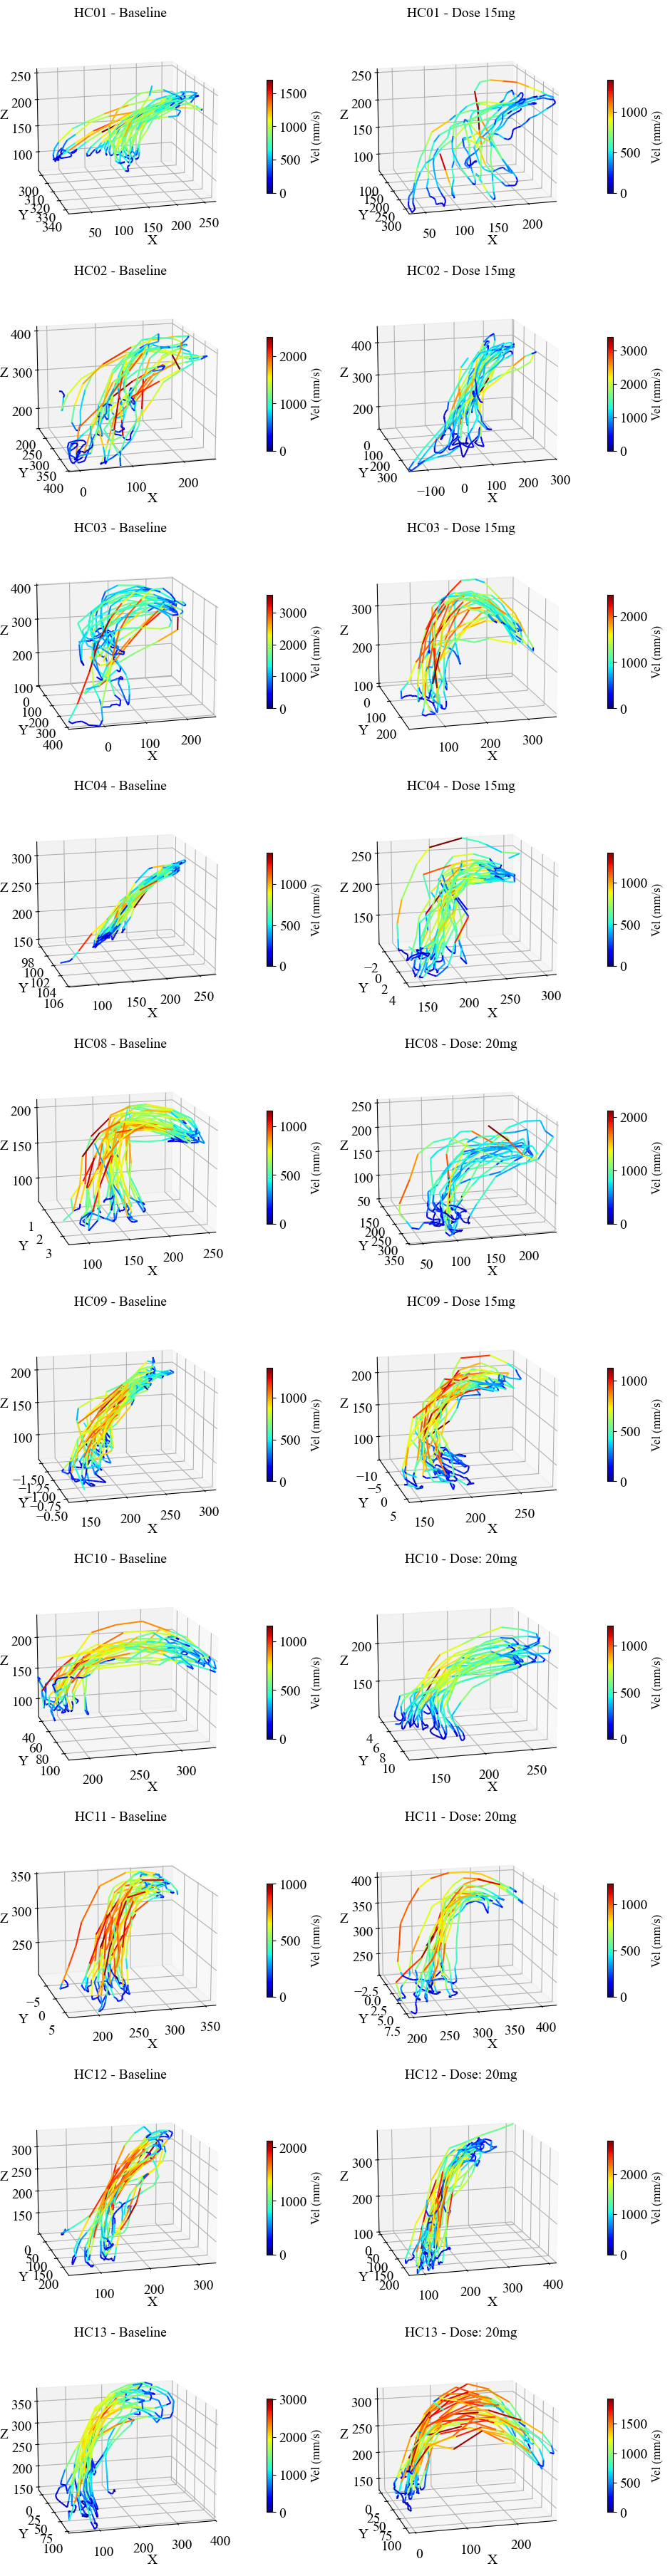

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# --- HELPER: Color mapping for 3D lines ---
def plot_colored_trajectory_3d(ax, points, values, cmap_name='viridis', linewidth=2, alpha=1.0):
    if points is None or len(points) < 2:
        return None

    # Handle NaNs in points (break lines where data is missing)
    # Mask valid points
    mask = ~np.isnan(points).any(axis=1)
    if not np.any(mask): return None
    
    # Create segments: (N-1, 2, 3)
    # We join point i to i+1
    points_reshaped = points.reshape(-1, 1, 3)
    segments = np.concatenate([points_reshaped[:-1], points_reshaped[1:]], axis=1)
    
    # Normalize color values
    if np.isnan(values).all():
        return None
    
    vmin = np.nanmin(values)
    vmax = np.nanmax(values)
    norm = plt.Normalize(vmin, vmax)
    
    lc = Line3DCollection(segments, cmap=cmap_name, norm=norm)
    lc.set_array(values)
    lc.set_linewidth(linewidth)
    lc.set_alpha(alpha)
    ax.add_collection3d(lc)
    
    # Auto-scale axes (matplotlib 3D doesn't do this auto for collections)
    x, y, z = points[:,0], points[:,1], points[:,2]
    ax.set_xlim(np.nanmin(x), np.nanmax(x))
    ax.set_ylim(np.nanmin(y), np.nanmax(y))
    ax.set_zlim(np.nanmin(z), np.nanmax(z))
    
    return lc

# --- 2. DATA PROCESSING ---
trajectories = {} 
all_baseline = []
all_dose = []

baseline_15mg = []
dose_15mg = []
baseline_20mg = []
dose_20mg = []

 

hand_timeseries = pd.read_json('box_and_block_timeseries_data.json')

for participant_id in participants_with_hand_annotations:
    trajectories[participant_id] = {}
    for condition in ['Baseline', 'Dose']:
        if participant_id in hand_timeseries and condition in hand_timeseries[participant_id]:
            hand_data = np.array(hand_timeseries[participant_id][condition]['hand'])
            
            if hand_data is not None and hand_data.size > 0:
                # Calculate Palm Centroid
                knuckle_idx = [5, 9, 13, 17]
                knuckles = hand_data[:, knuckle_idx, :]      
                wrist = hand_data[:, 0, :]                   
                midpoints = (knuckles + wrist[:, None, :]) / 2.0
                centroids = np.nanmean(midpoints, axis=1)    
                
                trajectories[participant_id][condition] = centroids
                
                if condition == 'Baseline':
                    all_baseline.append(centroids)
                    if participant_id in participant_with_20mg:
                        baseline_20mg.append(centroids)
                    else:
                        baseline_15mg.append(centroids)
                        
                else:
                    all_dose.append(centroids)
                    if participant_id in participant_with_20mg:
                        dose_20mg.append(centroids)
                    else:
                        dose_15mg.append(centroids)
     




# --- 3. INTERACTIVE PLOTTING ---
n_rows = len(participants_with_hand_annotations)
n_cols = 2

# Dynamic Figure Size
fig = plt.figure(figsize=(10, 4 * (n_rows )))
current_fps = fps if 'fps' in locals() else 30

# A. Plot Participants
for i, participant_id in enumerate(participants_with_hand_annotations):
    for j, condition in enumerate(['Baseline', 'Dose']):
        # Create subplot
        idx = i * n_cols + j + 1
        ax = fig.add_subplot(n_rows + 1, n_cols, idx, projection='3d')
        
        # Initial View Angle
        ax.view_init(elev=15, azim=75)
        
        if participant_id in trajectories and condition in trajectories[participant_id]:
            data = trajectories[participant_id][condition]
            
            if data is not None and len(data) > 1:
                # Velocity for Color
                vel = np.diff(data, axis=0) * current_fps
                vel_mag = np.linalg.norm(vel, axis=1)
                
                # Append 0 to match length of points
                vel_mag = np.append(vel_mag, 0)
                
                lc = plot_colored_trajectory_3d(ax, data, vel_mag, cmap_name='jet', linewidth=1.5)
                
                if lc:
                    cbar = fig.colorbar(lc, ax=ax, shrink=0.5, pad=0.1)
                    cbar.set_label('Vel (mm/s)', fontsize=12)

                dose_strength = "Dose: 20mg" if participant_id in participant_with_20mg else "Dose 15mg"
                if condition == 'Dose':
                    ax.set_title(f'{participant_id} - {dose_strength}', fontsize=14)
                else:
                    ax.set_title(f'{participant_id} - {condition}', fontsize=14)
            else:
                ax.text2D(0.5, 0.5, "Insufficient Data", transform=ax.transAxes, ha="center")
        else:
            ax.text2D(0.5, 0.5, "No Data", transform=ax.transAxes, ha="center")

        # Labels
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        
        #rverse x-axis
        ax.invert_xaxis()


plt.tight_layout()
plt.savefig('plots/hand_trajectories.jpg', dpi=600, bbox_inches='tight')
plt.show()

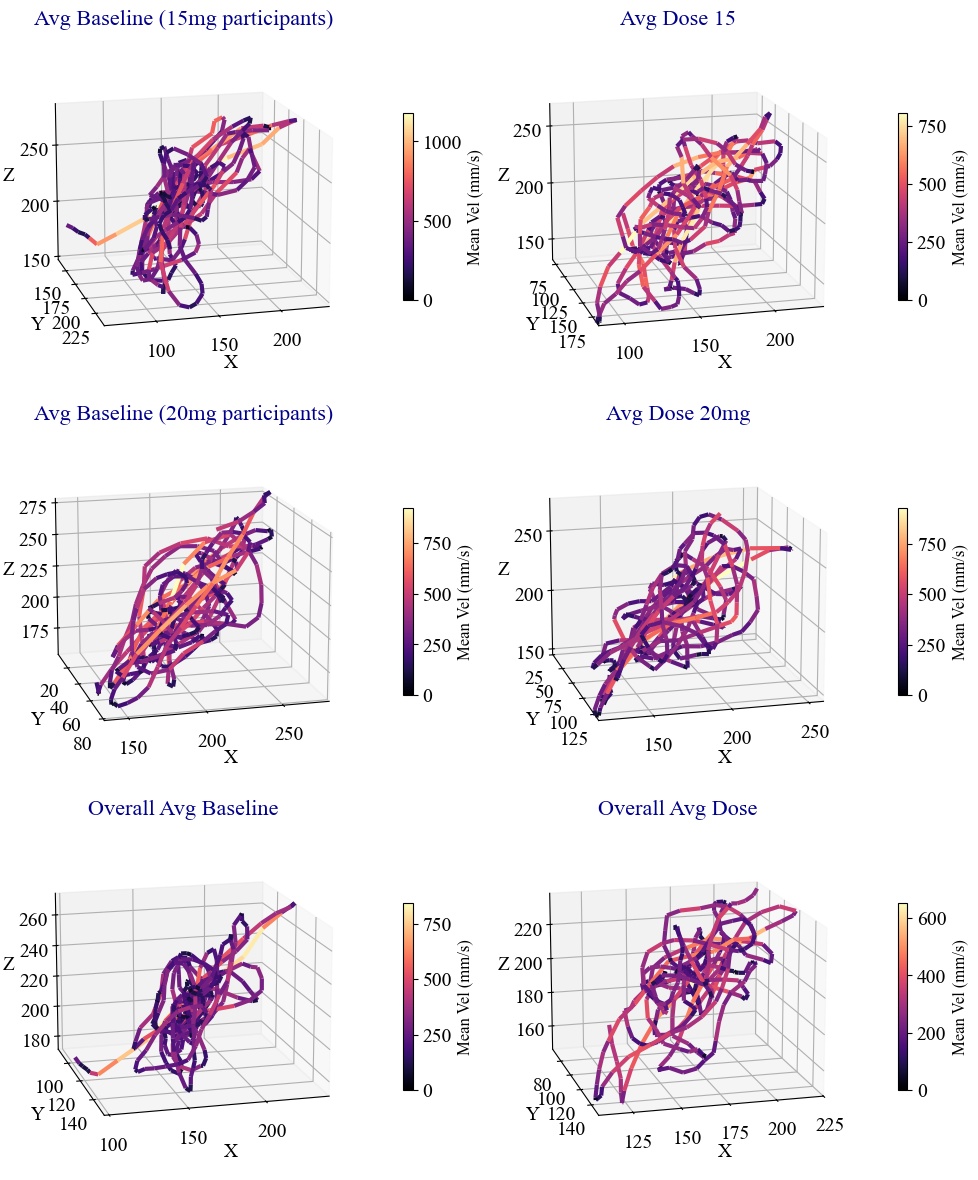

In [ ]:
# --- HELPER: Resample for Averaging ---
def resample_trajectory(traj, target_len):
    """Interpolates a trajectory to a fixed number of points."""
    if len(traj) < 2: return traj
    current_x = np.linspace(0, 1, len(traj))
    target_x = np.linspace(0, 1, target_len)
    
    new_traj = np.zeros((target_len, 3))
    for dim in range(3): # x, y, z
        # Remove NaNs for interpolation
        valid_mask = ~np.isnan(traj[:, dim])
        if not valid_mask.any(): continue
        
        # Interpolate this dimension
        new_traj[:, dim] = np.interp(target_x, current_x[valid_mask], traj[valid_mask, dim])
    return new_traj



# --- 3. CALCULATE AVERAGES (Resampling Method) ---
def get_average_trajectory(traj_list):
    valid_traj = [x for x in traj_list if x is not None and len(x) > 1]
    if not valid_traj:
        return None
    
    # Find median length to avoid compressing/stretching too much
    lengths = [len(x) for x in valid_traj]
    median_len = int(np.median(lengths))
    
    # Resample all to median length
    resampled_stack = []
    for t in valid_traj:
        resampled_stack.append(resample_trajectory(t, median_len))
        
    return np.mean(np.array(resampled_stack), axis=0)

avg_baseline = get_average_trajectory(all_baseline)
avg_dose = get_average_trajectory(all_dose)

avg_baseline_15mg = get_average_trajectory(baseline_15mg)
avg_dose_15mg = get_average_trajectory(dose_15mg)

avg_baseline_20mg = get_average_trajectory(baseline_20mg)
avg_dose_20mg = get_average_trajectory(dose_20mg)

# B. Plot Averages (Bottom Row)
avg_configs = [ (avg_baseline_15mg, 'Avg Baseline (15mg participants)'), (avg_dose_15mg, 'Avg Dose 15'), 
               (avg_baseline_20mg, 'Avg Baseline (20mg participants)'), (avg_dose_20mg, 'Avg Dose 20mg'),
                (avg_baseline, 'Overall Avg Baseline'), (avg_dose, 'Overall Avg Dose') ]

fig = plt.figure(figsize=(10, 8*3 ))


for k, (data, title) in enumerate(avg_configs):
    ax = fig.add_subplot(len(avg_configs), 2, k + 1, projection='3d')
    ax.view_init(elev=15, azim=75)
    
    if data is not None and len(data) > 1:
        vel = np.diff(data, axis=0) * current_fps
        vel_mag = np.linalg.norm(vel, axis=1)
        vel_mag = np.append(vel_mag, 0)
        
        # Thicker line for averages
        lc = plot_colored_trajectory_3d(ax, data, vel_mag, cmap_name='magma', linewidth=3)
        
        if lc:
            cbar = fig.colorbar(lc, ax=ax, shrink=0.5, pad=0.1)
            cbar.set_label('Mean Vel (mm/s)', fontsize=12)
        
        ax.set_title(f"{title}", fontsize=16, color='darkblue')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.invert_xaxis()
    plt.tight_layout()
plt.savefig('plots/average_hand_trajectories.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
nrows = len(participants_with_hand_annotations)
fig = plt.figure(figsize=(10, 4 * (n_rows )))
# Plot velocity profiles for baseline and dose for every participant
for i, participant_id in enumerate(participants_with_hand_annotations):
    for j, condition in enumerate(['Baseline', 'Dose']):
        idx = idx = i * n_cols + j + 1
        ax = fig.add_subplot(nrows, 2, idx)
        data = trajectories[participant_id].get(condition)
        if data is not None and len(data) > 1:
            vel = np.diff(data, axis=0) * current_fps
            vel_mag = np.linalg.norm(vel, axis=1)
            #conver to m/s
            vel_mag = vel_mag * 0.001
            # Append 0 to match length
            vel_mag = np.append(vel_mag, 0)
            ax.plot(vel_mag, color='tab:blue' if condition == 'Baseline' else 'tab:orange')
            ax.set_title(f"{participant_id} - {condition}")
            ax.set_xlabel('Frame')
            ax.set_ylabel('Velocity (m/s)')
            ax.grid(alpha=0.3)
        else:
            ax.text(0.5, 0.5, "No Data", ha='center', va='center')
plt.tight_layout()
plt.savefig('plots/hand_velocity_profiles.jpg', dpi=600, bbox_inches='tight')
plt.show()
   

## Finger tip trajectory, hand-centered

In [ ]:
def anatomical_hand_alignment(trajectory_data):
    """
    Aligns hand data to a rigid anatomical reference frame (The Palm).
    
    Revised Definition for Stability:
    1. Origin: Wrist (Index 0)
    2. Primary Axis (Y): Wrist -> Middle MCP (Index 9)
    3. Plane Definition: Wrist, Index MCP (5), Pinky MCP (17)
    4. Normal (Z): Cross product of (Wrist->Index) and (Wrist->Pinky) is stable.
       Alternatively: Cross(X_temp, Y) where X_temp is Wrist->Pinky direction.
    """
    n_frames, n_landmarks, n_dims = trajectory_data.shape
    aligned_data = np.zeros_like(trajectory_data)
    
    for i in range(n_frames):
        frame = trajectory_data[i].copy()
        
        # 1. TRANSLATION
        wrist_pos = frame[0]
        frame_centered = frame - wrist_pos
        
        # 2. DEFINE AXES
        # Y-axis: Longitudinal axis of the hand (Wrist -> Middle MCP)
        v_y = frame_centered[9] 
        v_y = v_y / np.linalg.norm(v_y)
        
        # Helper: Wrist -> Pinky MCP (Index 17) - Use this for a stable plane
        v_pinky = frame_centered[17]
        v_pinky = v_pinky / np.linalg.norm(v_pinky)

        # X-axis (approximate): Cross product of Y and Pinky vector
        # This points roughly "Right" (for a right hand) or "Left" (for left hand)
        v_x_temp = np.cross(v_y, v_pinky)
        v_x_temp = v_x_temp / np.linalg.norm(v_x_temp)
        
        # Z-axis: Normal to the palm (Orthogonal to X_temp and Y)
        # Re-crossing ensures orthogonality
        v_z = np.cross(v_x_temp, v_y)
        v_z = v_z / np.linalg.norm(v_z)
        
        # Final X-axis: Orthogonal to Y and Z
        v_x = np.cross(v_y, v_z)
        v_x = v_x / np.linalg.norm(v_x)
        
        # 3. ROTATION
        # Project points onto new basis
        R = np.vstack([v_x, v_y, v_z]) # Shape (3,3)
        frame_aligned = np.dot(frame_centered, R.T)
        
        aligned_data[i] = frame_aligned
        
    return aligned_data

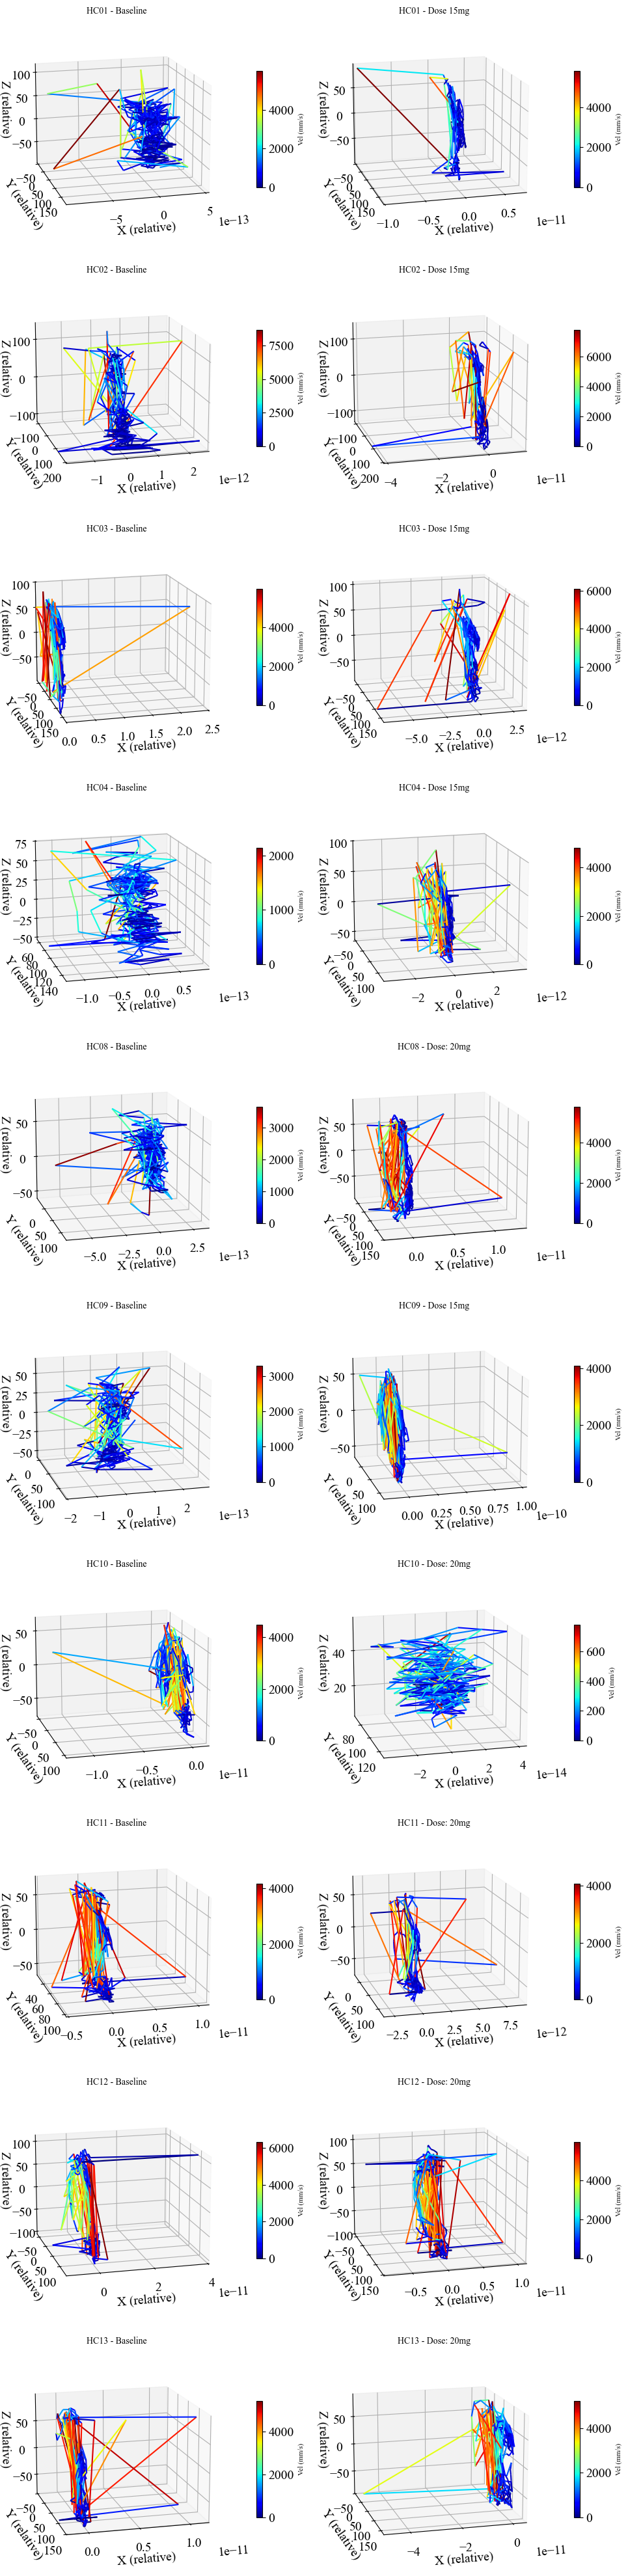

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# --- HELPER: Color mapping for 3D lines (copied from notebook) ---
def plot_colored_trajectory_3d(ax, points, values, cmap_name='viridis', linewidth=2, alpha=1.0):
    if points is None or len(points) < 2:
        return None

    # Mask valid points
    mask = ~np.isnan(points).any(axis=1)
    if not np.any(mask):
        return None

    # Build segments for Line3DCollection
    points_reshaped = points.reshape(-1, 1, 3)
    segments = np.concatenate([points_reshaped[:-1], points_reshaped[1:]], axis=1)

    if np.isnan(values).all():
        return None

    vmin = np.nanmin(values)
    vmax = np.nanmax(values)
    norm = plt.Normalize(vmin, vmax)

    lc = Line3DCollection(segments, cmap=cmap_name, norm=norm)
    lc.set_array(values)
    lc.set_linewidth(linewidth)
    lc.set_alpha(alpha)
    ax.add_collection3d(lc)

    # Auto-scale axes
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    ax.set_xlim(np.nanmin(x), np.nanmax(x))
    ax.set_ylim(np.nanmin(y), np.nanmax(y))
    ax.set_zlim(np.nanmin(z), np.nanmax(z))

    return lc


def build_index_finger_hand_centered_trajectories(hand_timeseries, participants_with_hand_annotations,
                                                  landmark_idx=8):
    """Return a dict[pid][condition] -> (N_frames, 3) of the index fingertip in a hand-centered frame.
    The function will try to call `anatomical_hand_alignment(trajectory_data)` if available; otherwise it
    falls back to subtracting the per-frame hand centroid (mean of landmarks).
    """
    index_trajectories = {}

    for pid in participants_with_hand_annotations:
        index_trajectories[pid] = {}
        for condition in ['Baseline', 'Dose']:
            if pid in hand_timeseries and condition in hand_timeseries[pid]:
                hand_data = hand_timeseries[pid][condition].get('hand')
                if hand_data is None:
                    continue

                hand_data = np.array(hand_data)  # (N_frames, 21, 3)
                if hand_data.size == 0:
                    continue

                # Apply anatomical alignment if available
                try:
                    aligned = anatomical_hand_alignment(hand_data)
                except Exception:
                    # Fallback: subtract per-frame centroid (mean across landmarks)
                    frame_centroids = np.nanmean(hand_data, axis=1)  # (N_frames, 3)
                    aligned = hand_data - frame_centroids[:, None, :]

                # Extract index fingertip trajectory
                if aligned.shape[1] <= landmark_idx:
                    # not enough landmarks
                    continue

                index_traj = aligned[:, landmark_idx, :]
                index_trajectories[pid][condition] = index_traj

    return index_trajectories


def plot_index_finger_trajectories(index_trajectories, participants_with_hand_annotations,
                                   participant_with_20m_input=None, fps=30, out_path='plots/index_finger_hand_centered_trajectories.jpg'):
    """Plot per-participant Baseline vs Dose index finger trajectories in a hand-centered frame.
    Uses `plot_colored_trajectory_3d` for consistent styling with the notebook.
    """

    n_rows = len(participants_with_hand_annotations)
    n_cols = 2

    fig = plt.figure(figsize=(10, 4 * (n_rows)))
    current_fps = fps

    for i, pid in enumerate(participants_with_hand_annotations):
        for j, condition in enumerate(['Baseline', 'Dose']):
            idx = i * n_cols + j + 1
            ax = fig.add_subplot(n_rows, n_cols, idx, projection='3d')
            ax.view_init(elev=15, azim=75)

            if pid in index_trajectories and condition in index_trajectories[pid]:
                data = index_trajectories[pid][condition]
                if data is not None and len(data) > 1:
                    vel = np.diff(data, axis=0) * current_fps
                    vel_mag = np.linalg.norm(vel, axis=1)
                    vel_mag = np.append(vel_mag, 0)

                    lc = plot_colored_trajectory_3d(ax, data, vel_mag, cmap_name='jet', linewidth=1.5)
                    if lc:
                        cbar = fig.colorbar(lc, ax=ax, shrink=0.5, pad=0.1)
                        cbar.set_label('Vel (mm/s)', fontsize=12)

                    dose_strength = "Dose: 20mg" if pid in participant_with_20mg else "Dose 15mg"
                    if condition == 'Dose':
                        ax.set_title(f'{pid} - {dose_strength}', fontsize=14)
                    else:
                        ax.set_title(f'{pid} - {condition}', fontsize=14)
                else:
                    ax.text2D(0.5, 0.5, "Insufficient Data", transform=ax.transAxes, ha="center")
            else:
                ax.text2D(0.5, 0.5, "No Data", transform=ax.transAxes, ha="center")

            ax.set_xlabel('X (relative)')
            ax.set_ylabel('Y (relative)')
            ax.set_zlabel('Z (relative)')
            ax.invert_xaxis()

    plt.tight_layout()
    # Ensure output directory exists when the user runs this later
    try:
        import os
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
    except Exception:
        pass

    plt.savefig(out_path, dpi=600, bbox_inches='tight')
    plt.show()


# Build trajectories
index_trajectories = build_index_finger_hand_centered_trajectories(hand_timeseries, participants_with_hand_annotations, landmark_idx=8)
# Plot trajectories
plot_index_finger_trajectories(index_trajectories, participants_with_hand_annotations, participant_with_20mg, fps=30, out_path='plots/index_finger_hand_centered_trajectories.jpg')


## Summary

In [ ]:
# Final summary (DELTAS ONLY): print kinematic delta columns and wall-touch deltas
import pandas as pd
import numpy as np

print("=== KINEMATICS DELTA SUMMARY ===\n")

# 1) Exploratory kinematics deltas
if 'exploratory_results_df' in globals() and isinstance(exploratory_results_df, pd.DataFrame) and not exploratory_results_df.empty:
    df = exploratory_results_df
    delta_cols = [c for c in df.columns if c.startswith('delta_')]
    if delta_cols:
        print(f"Found {len(delta_cols)} delta columns: {', '.join(delta_cols)}\n")
        # Aggregate summary
        agg = df[delta_cols].agg(['count','mean','std','median']).T.round(4)
        print("-- Aggregate delta summary (count, mean, std, median) --")
        print(agg.to_string())
        print('\n')
        # Per-subject table (limit to first 100 rows)
        print("-- Per-subject deltas (first 100 rows) --")
        try:
            subj_table = df[['subject_id'] + delta_cols].set_index('subject_id')
            with pd.option_context('display.max_rows', 200, 'display.max_columns', None):
                print(subj_table.head(100).to_string())
        except Exception as e:
            print("Could not display per-subject table:", e)
    else:
        print("No delta_* columns found in exploratory_results_df.")
else:
    print('No exploratory_results_df found or it is empty.')

print('\n=== WALL TOUCHES DELTA ===\n')
# 2) Wall touches delta per participant (Dose - Baseline)
if 'wall_touches_count' in globals() and isinstance(wall_touches_count, pd.DataFrame) and not wall_touches_count.empty:
    w = wall_touches_count.copy()
    # Pivot to get conditions as columns
    pivot = w.pivot_table(index='participant_id', columns='condition', values='wall_touches', aggfunc='mean')
    cols_lower = {c.lower(): c for c in pivot.columns}
    baseline_col = next((c for k,c in cols_lower.items() if 'base' in k or 'baseline' in k), None)
    dose_col = next((c for k,c in cols_lower.items() if 'dose' in k), None)

    if baseline_col and dose_col:
        pivot = pivot.copy()
        pivot['delta_wall_touches'] = pivot[dose_col] - pivot[baseline_col]
        print(f"Computed delta_wall_touches = {dose_col} - {baseline_col}\n")
        print("-- Per-participant wall-touch deltas --")
        print(pivot[['delta_wall_touches']].head(100).to_string())
        print('\n-- Aggregate delta stats --')
        print(pivot['delta_wall_touches'].agg(['count','mean','std']).round(3).to_string())
    elif pivot.shape[1] == 2:
        # Fallback: take the two columns and compute second - first (but show names)
        c0, c1 = pivot.columns[:2]
        pivot = pivot.copy()
        pivot['delta_wall_touches'] = pivot[c1] - pivot[c0]
        print(f"Could not identify baseline/dose by name; using columns '{c1}' - '{c0}' for delta computation.\n")
        print(pivot[['delta_wall_touches']].head(100).to_string())
        print('\n-- Aggregate delta stats --')
        print(pivot['delta_wall_touches'].agg(['count','mean','std']).round(3).to_string())
    else:
        print("Could not compute wall-touch deltas: insufficient or unexpected condition columns:\n ", list(pivot.columns))
else:
    print('No wall_touches_count found or it is empty.')

# 3) Optional: merge deltas for quick overview if both available
if ('exploratory_results_df' in globals() and isinstance(exploratory_results_df, pd.DataFrame) and not exploratory_results_df.empty
    and 'wall_touches_count' in globals() and isinstance(wall_touches_count, pd.DataFrame) and not wall_touches_count.empty):
    if delta_cols:
        try:
            merged = exploratory_results_df[['subject_id'] + delta_cols].merge(
                pivot[['delta_wall_touches']].reset_index(), left_on='subject_id', right_on='participant_id', how='left'
            ).set_index('subject_id')
            print('\n=== Merged kinematics deltas with wall-touch deltas (first 50 rows) ===')
            with pd.option_context('display.max_rows', 200, 'display.max_columns', None):
                print(merged.head(50).to_string())
        except Exception as e:
            print('Could not merge kinematic deltas and wall-touch deltas:', e)

print('\nDone.')

In [ ]:
# DEBUG: Compare Overall Velocity vs Moving Velocity
if 'exploratory_results_df' in locals():
    cols = [
        'subject_id', 
        'delta_velocity', # (Dose Moving - Base Moving)
        'base_centroid_mean_velocity_m_s', 'dose_centroid_mean_velocity_m_s', # Overall
        'base_centroid_mean_moving_velocity_m_s', 'dose_centroid_mean_moving_velocity_m_s', # Moving
        'base_centroid_percent_moving', 'dose_centroid_percent_moving'
    ]
    # Check if cols exist
    avail_cols = [c for c in cols if c in exploratory_results_df.columns]
    
    print("=== COMPARISON: Overall vs Moving Velocity ===")
    print(exploratory_results_df[avail_cols].round(3).to_string())
    
    # Calculate difference in OVERALL velocity
    if 'dose_centroid_mean_velocity_m_s' in exploratory_results_df.columns:
        diff_overall = exploratory_results_df['dose_centroid_mean_velocity_m_s'] - exploratory_results_df['base_centroid_mean_velocity_m_s']
        print("\nDelta Overall Velocity (Dose - Base):")
        print(diff_overall.round(3).to_string())
else:
    print("exploratory_results_df not found.")

In [ ]:
# Validation: Plot Raw vs Smoothed Velocity for HC11 to understand discrepancy
participant_val = 'HC11'
if participant_val in trajectories and participant_val in hand_timeseries:
    print(f"Validating Kinematics logic for {participant_val}...")
    
    # 1. Get Trajectory Data (Raw-ish centroids from trajectories dict used in User's Plot)
    traj_base_raw = trajectories[participant_val]['Baseline']
    traj_dose_raw = trajectories[participant_val]['Dose']
    
    # 2. Compute Raw Velocity (User's way - np.diff)
    def calc_raw_vel(pos, fps=30):
        if pos is None or len(pos)<2: return None
        v = np.diff(pos, axis=0) * fps
        speed = np.linalg.norm(v, axis=1) * 0.001 # m/s
        return speed

    raw_vel_base = calc_raw_vel(traj_base_raw)
    raw_vel_dose = calc_raw_vel(traj_dose_raw)
    
    # 3. Compute Smoothed Velocity (FeatureExtractor way)
    # Re-run extraction
    base_frames = hand_timeseries[participant_val]['Baseline']['hand']
    dose_frames = hand_timeseries[participant_val]['Dose']['hand']
    
    # Assuming 'extractor' exists from previous cells
    base_feat, base_kin, _ = extractor.extract_features(base_frames)
    dose_feat, dose_kin, _ = extractor.extract_features(dose_frames)
    
    smooth_vel_base = base_kin['centroid_speed'] / 1000.0 # m/s
    smooth_vel_dose = dose_kin['centroid_speed'] / 1000.0
    
    moving_base = base_kin['is_moving']
    moving_dose = dose_kin['is_moving']
    
    # PLOT
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharey=True)
    
    # Baseline
    ax = axes[0]
    # Align lengths roughly (Raw is N, Smooth is N, but Raw diff is N-1)
    t_base_raw = np.arange(len(raw_vel_base)) / 30.0
    t_base_smooth = base_kin['timestamps']
    
    ax.plot(t_base_raw, raw_vel_base, 'gray', label='Raw (np.diff)', alpha=0.5, linewidth=1)
    ax.plot(t_base_smooth, smooth_vel_base, 'b-', label='Smoothed (Savgol)', linewidth=2)
    ax.fill_between(t_base_smooth, 0, smooth_vel_base, where=moving_base, color='blue', alpha=0.1, label='Classified Moving')
    ax.set_title(f"{participant_val} - Baseline", fontsize=14)
    ax.legend(loc='upper right')
    ax.set_ylabel("Speed (m/s)")
    ax.grid(alpha=0.3)
    
    # Dose
    ax = axes[1]
    t_dose_raw = np.arange(len(raw_vel_dose)) / 30.0
    t_dose_smooth = dose_kin['timestamps']
    
    ax.plot(t_dose_raw, raw_vel_dose, 'gray', label='Raw (np.diff)', alpha=0.5, linewidth=1)
    ax.plot(t_dose_smooth, smooth_vel_dose, 'r-', label='Smoothed (Savgol)', linewidth=2)
    ax.fill_between(t_dose_smooth, 0, smooth_vel_dose, where=moving_dose, color='red', alpha=0.1, label='Classified Moving')
    ax.set_title(f"{participant_val} - Dose", fontsize=14)
    ax.legend(loc='upper right')
    ax.set_ylabel("Speed (m/s)")
    ax.set_xlabel("Time (s)")
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("=== Comparison Statistics ===")
    print(f"Baseline:")
    print(f"  Raw Mean: {np.nanmean(raw_vel_base):.3f} m/s")
    print(f"  Smooth Mean (All): {base_feat['centroid_mean_velocity_m_s']:.3f} m/s")
    print(f"  Smooth Mean (Moving): {base_feat['centroid_mean_moving_velocity_m_s']:.3f} m/s")
    print(f"Dose:")
    print(f"  Raw Mean: {np.nanmean(raw_vel_dose):.3f} m/s")
    print(f"  Smooth Mean (All): {dose_feat['centroid_mean_velocity_m_s']:.3f} m/s")
    print(f"  Smooth Mean (Moving): {dose_feat['centroid_mean_moving_velocity_m_s']:.3f} m/s")
    
else:
    print(f"Data for {participant_val} not available.")